In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
#
# Target Architecture:
# DDRNet-39
#   - Deep Dual-Resolution Backbone
#   - Multiple Bilateral Feature Fusions
#   - Deep Aggregation Pyramid Pooling Module (DAPPM)
#   - Main Segmentation Head
#   - Auxiliary Segmentation Head / Deep Supervision
#
# Target Dataset: Cityscapes
#
# Optimization Mode:
# VRAM-Armored Mixed Precision Training
#
# Paper Reference Target:
# DDRNet-39 ≈ 80.4% mIoU on Cityscapes test set
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Strict CUDA Memory Behavior
# --------------------------------------------------
# Must be set before significant CUDA allocation occurs.
# Helps reduce CUDA memory fragmentation on the 16 GB RTX A4000.

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# NOTE:
# torchvision.models is intentionally NOT imported here.
# DDRNet-39 will be implemented explicitly from its own
# BasicBlock, Bottleneck, bilateral-fusion, DAPPM,
# and segmentation-head components.

# --------------------------------------------------
# Schedulers & Data Loading
# --------------------------------------------------

from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    LinearLR,
    SequentialLR,
    PolynomialLR,
)

from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# VRAM Optimization Tools — AMP
# --------------------------------------------------

from torch.amp import GradScaler, autocast

# --------------------------------------------------
# Data Augmentation
# --------------------------------------------------

import albumentations as A
from albumentations.pytorch import ToTensorV2

# --------------------------------------------------
# Progress Monitoring
# --------------------------------------------------

from tqdm import tqdm


# ============================================================
# Cleanup and Warning Control
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)


# ============================================================
# Reproducibility Setup
# ============================================================

SEED = 42


def set_seed(seed: int = 42, deterministic: bool = False):
    """
    Sets random seeds for Python, NumPy, and PyTorch.

    deterministic=False is intentionally retained because:
    - it allows cuDNN benchmarking,
    - improves training throughput,
    - matches the performance-oriented nature of DDRNet.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass

    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


set_seed(SEED, deterministic=False)

print(
    f"[*] Seed set to {SEED} "
    f"(deterministic=False for stable/efficient training)"
)


def seed_worker(worker_id):
    """
    Reproducible worker initialization for PyTorch DataLoader.
    """
    worker_seed = SEED + worker_id

    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


# Reproducible DataLoader generator
g = torch.Generator()
g.manual_seed(SEED)


# ============================================================
# Matplotlib & Seaborn Styling Setup
# ============================================================

%matplotlib inline

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (10, 6)

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)


# ============================================================
# Device & CUDA Engine Configuration
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"[*] Using Device: {DEVICE}")

if torch.cuda.is_available():

    print(
        f"    GPU Model: "
        f"{torch.cuda.get_device_name(0)}"
    )

    print(
        f"    CUDA Toolchain Version: "
        f"{torch.version.cuda}"
    )

    total_gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(
        f"    Total Available GPU Memory: "
        f"{total_gpu_memory:.2f} GB"
    )

    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

        print(
            "    TF32 matrix operations enabled successfully."
        )

    except Exception as e:

        print(
            f"    TF32 configuration skipped: {e}"
        )


# ============================================================
# DDRNet-39 Paper-Aligned Model Specifications
# ============================================================

NUM_CLASSES = 19

# DDRNet-39 residual stage configuration.
# Corresponds to the deeper DDRNet variant.
DDRNET_BLOCK_DEPTHS = (3, 4, 6, 3)

# Base width used by DDRNet-39.
DDRNET_BASE_PLANES = 64

# High-resolution branch width before the final bottleneck.
DDRNET_HIGHRES_PLANES = 128

# DAPPM internal branch width.
DDRNET_DAPPM_BRANCH_PLANES = 128

# DDRNet-39 segmentation-head intermediate width.
DDRNET_HEAD_PLANES = 256

# DDRNet bottleneck expands channels by 2.
DDRNET_BOTTLENECK_EXPANSION = 2

# Deep supervision coefficient described in the paper.
AUX_LOSS_WEIGHT = 0.4

# Important for all DDRNet bilinear interpolation operations.
ALIGN_CORNERS = False

# Paper reference performance.
PAPER_TARGET_MIOU = 80.4


# ============================================================
# Single-GPU Training Strategy for DDRNet-39
# ============================================================

# Original Cityscapes DDRNet training uses a TOTAL batch size
# of 12 across four GPUs.
#
# On the local 16 GB RTX A4000:
#
#     Physical batch = 2
#     Accumulation    = 6
#
# gives:
#
#     Effective batch = 2 × 6 = 12
#
# This reproduces the optimizer-level effective batch size,
# although single-GPU BatchNorm statistics naturally differ
# from the original four-GPU SyncBN experiment.

PHYSICAL_BATCH_SIZE = 2

GRAD_ACCUM_STEPS = 6

EFFECTIVE_BATCH_SIZE = (
    PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS
)

USE_AMP = torch.cuda.is_available()

scaler = GradScaler(
    "cuda" if torch.cuda.is_available() else "cpu",
    enabled=USE_AMP
)

print(
    f"[*] Mixed Precision Training Enabled: "
    f"{USE_AMP}"
)

print(
    f"[*] Physical Batch Size: "
    f"{PHYSICAL_BATCH_SIZE}"
)

print(
    f"[*] Gradient Accumulation Steps: "
    f"{GRAD_ACCUM_STEPS}"
)

print(
    f"[*] Effective Batch Size: "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    f"[*] Paper Target Effective Batch Size: 12"
)


# ============================================================
# CENTRALIZED DIRECTORY & PATH MAPPING
# ============================================================

IMG_ROOT = Path(
    "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/"
    "Datasets/leftImg8bit_trainvaltest/leftImg8bit"
)

MASK_ROOT = Path(
    "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/"
    "Datasets/gtFine_trainvaltest/gtFine"
)

FINAL_SAVE_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_cityscapes/Results_Export_DDRNet_cityscapes"
)

QUAL_VIS_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_cityscapes/training_visuals_DDRNet_cityscapes"
)

CHECKPOINT_DIR = (
    FINAL_SAVE_DIR
    / "progressive_checkpoints_DDRNet_cityscapes"
)

PLOTS_DIR = (
    FINAL_SAVE_DIR
    / "training_plots_DDRNet_cityscapes"
)

LOGS_DIR = (
    FINAL_SAVE_DIR
    / "training_logs_DDRNet_cityscapes"
)

METRICS_DIR = (
    FINAL_SAVE_DIR
    / "training_metrics_DDRNet_cityscapes"
)


for d in [
    CHECKPOINT_DIR,
    PLOTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    FINAL_SAVE_DIR,
    QUAL_VIS_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# Model Identification
# ============================================================

MODEL_NAME = "DDRNet-39"

MODEL_ALIAS = (
    "DDRNet-39 "
    "(Deep Dual-Resolution Backbone + "
    "Bilateral Fusion + DAPPM + Deep Supervision)"
)

print(
    f"\n[*] Model Configuration Linked: "
    f"{MODEL_ALIAS}"
)

print(
    f"[*] Model Base: {MODEL_NAME}"
)

print(
    f"[*] Residual Stage Depths: "
    f"{DDRNET_BLOCK_DEPTHS}"
)

print(
    f"[*] DAPPM Branch Channels: "
    f"{DDRNET_DAPPM_BRANCH_PLANES}"
)

print(
    f"[*] Segmentation Head Channels: "
    f"{DDRNET_HEAD_PLANES}"
)

print(
    f"[*] Number of Cityscapes Classes: "
    f"{NUM_CLASSES}"
)

print(
    f"[*] Deep Supervision Auxiliary Weight: "
    f"{AUX_LOSS_WEIGHT}"
)

print(
    f"[*] Paper Reference DDRNet-39 mIoU: "
    f"{PAPER_TARGET_MIOU:.1f}%"
)

print(
    f"[*] Global Analytical Results Save Path Linked: "
    f"{FINAL_SAVE_DIR.resolve()}"
)


# ============================================================
# Runtime Performance Containers & Checkpoint Manager
# ============================================================

HISTORY_FILE = (
    LOGS_DIR
    / "training_history.csv"
)


# --------------------------------------------------
# Pre-initialized with ALL exhaustive metric keys
# --------------------------------------------------
#
# IMPORTANT:
# Structure intentionally preserved from the PSPNet pipeline
# so later:
# - plotting,
# - ETA,
# - CSV reconstruction,
# - Excel export,
# - checkpoint recovery,
# - metric analysis
#
# remain compatible.
# --------------------------------------------------

history = {

    "epoch": [],
    "phase": [],

    # ----------------------------------------------
    # Training Losses
    # ----------------------------------------------

    "train_total_loss": [],

    # DDRNet main segmentation head loss
    "train_main_loss": [],

    # DDRNet auxiliary segmentation head loss
    "train_aux_loss": [],

    # ----------------------------------------------
    # Training Segmentation Metrics
    # ----------------------------------------------

    "train_miou": [],
    "train_macc": [],
    "train_aacc": [],

    # ----------------------------------------------
    # Validation Metrics
    # ----------------------------------------------

    "val_total_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],

    # ----------------------------------------------
    # Optimization / Runtime
    # ----------------------------------------------

    "learning_rate": [],
    "epoch_time_sec": [],
    "total_training_time_str": [],

    # ----------------------------------------------
    # Training Precision / Recall / F1
    # ----------------------------------------------

    "train_Precision_Macro": [],
    "train_Recall_Macro": [],
    "train_F1_Macro": [],

    "train_Precision_Micro": [],
    "train_Recall_Micro": [],
    "train_F1_Micro": [],

    # ----------------------------------------------
    # Validation Precision / Recall / F1
    # ----------------------------------------------

    "val_Precision_Macro": [],
    "val_Recall_Macro": [],
    "val_F1_Macro": [],

    "val_Precision_Micro": [],
    "val_Recall_Micro": [],
    "val_F1_Micro": [],
}


# ============================================================
# Best / Latest Model Tracking
# ============================================================

best_record = {

    "epoch": -1,

    "best_miou": -1.0,

    "best_path": str(
        CHECKPOINT_DIR
        / "ddrnet39_best.pth"
    ),

    "latest_path": str(
        CHECKPOINT_DIR
        / "ddrnet39_latest.pth"
    ),
}


# ============================================================
# Checkpoint Manager
# ============================================================

def save_checkpoint(
    epoch,
    model,
    optimizer,
    scaler,
    scheduler,
    history_dict,
    total_time,
    is_best=False,
):
    """
    Save the complete DDRNet-39 training state.

    Maintains two persistent checkpoints:

        1. ddrnet39_latest.pth
           - overwritten every checkpoint save
           - used for crash/power-failure recovery

        2. ddrnet39_best.pth
           - overwritten only when validation mIoU improves

    The complete history dictionary is embedded inside
    each checkpoint.

    A CSV copy is also exported independently so that
    training curves and analytical results survive even
    if a later checkpoint becomes unavailable.
    """

    state = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict()
            if scheduler is not None
            else None,

        "history":
            history_dict,

        "total_training_time":
            total_time,

        "best_record":
            best_record,

        # --------------------------------------------------
        # DDRNet-39 experiment metadata
        # --------------------------------------------------

        "model_name":
            MODEL_NAME,

        "model_alias":
            MODEL_ALIAS,

        "num_classes":
            NUM_CLASSES,

        "ddrnet_block_depths":
            DDRNET_BLOCK_DEPTHS,

        "ddrnet_base_planes":
            DDRNET_BASE_PLANES,

        "ddrnet_dappm_branch_planes":
            DDRNET_DAPPM_BRANCH_PLANES,

        "ddrnet_head_planes":
            DDRNET_HEAD_PLANES,

        "aux_loss_weight":
            AUX_LOSS_WEIGHT,

        "physical_batch_size":
            PHYSICAL_BATCH_SIZE,

        "grad_accum_steps":
            GRAD_ACCUM_STEPS,

        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,
    }

    # --------------------------------------------------
    # 1. Update CSV securely
    # --------------------------------------------------

    pd.DataFrame(
        history_dict
    ).to_csv(
        HISTORY_FILE,
        index=False
    )

    # --------------------------------------------------
    # 2. Always overwrite latest model state
    # --------------------------------------------------

    torch.save(
        state,
        best_record["latest_path"]
    )

    # --------------------------------------------------
    # 3. Save best model when validation mIoU improves
    # --------------------------------------------------

    if is_best:

        torch.save(
            state,
            best_record["best_path"]
        )

        print(
            f"\n[+] New Best DDRNet-39 Model Saved!"
            f" Val mIoU: "
            f"{best_record['best_miou']:.2f}%"
            f" | Epoch: {epoch}"
        )


# ============================================================
# Final Step-1 Status
# ============================================================

print("\n" + "=" * 70)
print("[*] DDRNet-39 Step 1 Initialization Summary")
print("=" * 70)

print(
    f"[*] Architecture          : {MODEL_NAME}"
)

print(
    f"[*] Dataset               : Cityscapes"
)

print(
    f"[*] Classes               : {NUM_CLASSES}"
)

print(
    f"[*] Physical Batch        : "
    f"{PHYSICAL_BATCH_SIZE}"
)

print(
    f"[*] Gradient Accumulation : "
    f"{GRAD_ACCUM_STEPS}"
)

print(
    f"[*] Effective Batch       : "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    f"[*] AMP Enabled           : "
    f"{USE_AMP}"
)

print(
    f"[*] Checkpoint — Latest   : "
    f"{best_record['latest_path']}"
)

print(
    f"[*] Checkpoint — Best     : "
    f"{best_record['best_path']}"
)

print(
    f"[*] Training History CSV  : "
    f"{HISTORY_FILE}"
)

print(
    f"[*] Results Directory     : "
    f"{FINAL_SAVE_DIR.resolve()}"
)

print("=" * 70)

print(
    "\n[*] Metrics tracking layers constructed."
    "\n[*] Global paths centralized."
    "\n[*] DDRNet-39 experiment metadata registered."
    "\n[*] Best/latest checkpoint manager ready."
    "\n[*] Step 1 sequence completed successfully."
)

[*] Seed set to 42 (deterministic=False for stable/efficient training)
[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Toolchain Version: 12.1
    Total Available GPU Memory: 15.73 GB
    TF32 matrix operations enabled successfully.
[*] Mixed Precision Training Enabled: True
[*] Physical Batch Size: 2
[*] Gradient Accumulation Steps: 6
[*] Effective Batch Size: 12
[*] Paper Target Effective Batch Size: 12

[*] Model Configuration Linked: DDRNet-39 (Deep Dual-Resolution Backbone + Bilateral Fusion + DAPPM + Deep Supervision)
[*] Model Base: DDRNet-39
[*] Residual Stage Depths: (3, 4, 6, 3)
[*] DAPPM Branch Channels: 128
[*] Segmentation Head Channels: 256
[*] Number of Cityscapes Classes: 19
[*] Deep Supervision Auxiliary Weight: 0.4
[*] Paper Reference DDRNet-39 mIoU: 80.4%
[*] Global Analytical Results Save Path Linked: /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes

[*] DDRNet-39 Step 1 Initialization Summary
[*] Architecture      

In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
#
# Target Architecture:
# DDRNet-39
#   - Deep Dual-Resolution Backbone
#   - Bilateral Feature Fusion
#   - Deep Aggregation Pyramid Pooling Module (DAPPM)
#   - Deep Supervision
#
# Target Dataset: Cityscapes
#
# Paper-Aligned Optimization:
#   - 484 Epochs (~120K optimizer iterations)
#   - SGD
#   - Poly LR
#   - 1024 x 1024 Training Crops
#   - Random Scale 0.5–2.0
#   - Auxiliary Loss Weight 0.4
#   - OHEM
# ============================================================

import matplotlib.ticker as mtick


# ------------------------------------------------------------
# INHERITED PATH VERIFICATION
# ------------------------------------------------------------

print(f"[*] Image root inherited      : {IMG_ROOT}")
print(f"[*] Mask root inherited       : {MASK_ROOT}")
print(f"[*] Visualizations target     : {QUAL_VIS_DIR.resolve()}")
print(f"[*] Final export target       : {FINAL_SAVE_DIR.resolve()}")


# ============================================================
# CORE TASK SETTINGS — CITYSCAPES 19-CLASS STANDARD
# ============================================================

# NUM_CLASSES = 19 was already defined in Step 1.
# CLASSES is retained as a compatibility alias for later cells.
CLASSES = NUM_CLASSES

IGNORE_INDEX = 255

# Retained for compatibility with the existing dataset pipeline.
# Raw Cityscapes *_labelIds.png masks will be converted to
# the standard 19 train classes using the lookup table below.
USE_LABEL_TRAINIDS = True


CLASS_NAMES = [
    "Road",
    "Sidewalk",
    "Building",
    "Wall",
    "Fence",
    "Pole",
    "Traffic Light",
    "Traffic Sign",
    "Vegetation",
    "Terrain",
    "Sky",
    "Person",
    "Rider",
    "Car",
    "Truck",
    "Bus",
    "Train",
    "Motorcycle",
    "Bicycle",
]


# ------------------------------------------------------------
# Standard Cityscapes RGB Color Palette
# ------------------------------------------------------------

CITYSCAPES_PALETTE = np.array(
    [
        [128, 64, 128],    # Road
        [244, 35, 232],    # Sidewalk
        [70, 70, 70],      # Building
        [102, 102, 156],   # Wall
        [190, 153, 153],   # Fence
        [153, 153, 153],   # Pole
        [250, 170, 30],    # Traffic Light
        [220, 220, 0],     # Traffic Sign
        [107, 142, 35],    # Vegetation
        [152, 251, 152],   # Terrain
        [70, 130, 180],    # Sky
        [220, 20, 60],     # Person
        [255, 0, 0],       # Rider
        [0, 0, 142],       # Car
        [0, 0, 70],        # Truck
        [0, 60, 100],      # Bus
        [0, 80, 100],      # Train
        [0, 0, 230],       # Motorcycle
        [119, 11, 32],     # Bicycle
    ],
    dtype=np.uint8,
)


# ============================================================
# IMAGE GEOMETRY — DDRNET CITYSCAPES PAPER SETTING
# ============================================================

# DDRNet trains Cityscapes using random 1024 x 1024 crops.
IMG_H = 1024
IMG_W = 1024

# Native Cityscapes validation/test resolution.
VAL_IMG_H = 1024
VAL_IMG_W = 2048


# ============================================================
# TRAINING LENGTH
# ============================================================

# DDRNet paper:
# 484 epochs ≈ 120K iterations.
#
# With our Step-1 configuration:
#
#   Physical batch = 2
#   Gradient accumulation = 6
#   Effective batch = 12
#
# this closely follows the optimizer-level batch configuration
# used in the DDRNet Cityscapes experiment.

EPOCHS = 484

# Paper replication uses the full scheduled training duration.
USE_EARLY_STOPPING = False


# AUX_LOSS_WEIGHT = 0.4 was already defined in Step 1.
# Alias retained because later cells from the previous pipeline
# may refer to AUX_WEIGHT.
AUX_WEIGHT = AUX_LOSS_WEIGHT


# ============================================================
# OPTIMIZATION SCHEDULE — DDRNET CITYSCAPES
# ============================================================

BASE_LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

# DDRNet uses polynomial learning-rate decay.
WARMUP_EPOCHS = 0
LR_POWER = 0.9

# DDRNet Cityscapes training uses Online Hard Example Mining.
# Exact loss implementation will be defined in the loss/training step.
USE_OHEM = True


print(
    "\n--- DDRNet-39 Cityscapes Optimization Schedule "
    "(Paper-Aligned) ---"
)

print(f"Target Total Epochs     : {EPOCHS}")
print(f"Base Learning Rate      : {BASE_LR}")
print(f"Momentum                : {MOMENTUM}")
print(f"Weight Decay            : {WEIGHT_DECAY}")
print(f"Poly LR Power           : {LR_POWER}")
print(f"Auxiliary Loss Weight   : {AUX_WEIGHT}")
print(f"OHEM Enabled            : {USE_OHEM}")
print(f"Training Crop Size      : {IMG_H}x{IMG_W}")
print(f"Validation Resolution   : {VAL_IMG_H}x{VAL_IMG_W}")
print(f"Effective Batch Size    : {EFFECTIVE_BATCH_SIZE}")


# ============================================================
# VALIDATION / INFERENCE SETTINGS
# ============================================================

# DDRNet is designed to process full-resolution road scenes.
# Standard validation will therefore use the complete
# 2048 x 1024 Cityscapes image.
#
# Sliding-window variables are retained only as a fallback
# for compatibility with later validation code.

USE_SLIDING_WINDOW_VAL = False

VAL_WINDOW_SIZE = (IMG_H, IMG_W)
VAL_WINDOW_STRIDE = (IMG_H, IMG_W)

# Standard validation is kept single-scale/non-flipped so that
# best-model selection is not dependent on test-time augmentation.
# Paper-style multi-scale + flip evaluation can be enabled later
# in the dedicated final evaluation step.
USE_FLIP_TTA = False


# ============================================================
# CITYSCAPES 34-ID -> 19 TRAIN-CLASS MAPPING
# ============================================================

mapping_34_to_19 = {
    0: 255,
    1: 255,
    2: 255,
    3: 255,
    4: 255,
    5: 255,
    6: 255,
    7: 0,
    8: 1,
    9: 255,
    10: 255,
    11: 2,
    12: 3,
    13: 4,
    14: 255,
    15: 255,
    16: 255,
    17: 5,
    18: 255,
    19: 6,
    20: 7,
    21: 8,
    22: 9,
    23: 10,
    24: 11,
    25: 12,
    26: 13,
    27: 14,
    28: 15,
    29: 255,
    30: 255,
    31: 16,
    32: 17,
    33: 18,
    -1: 255,
}


# ------------------------------------------------------------
# Lookup Table for Fast Mask Conversion
# ------------------------------------------------------------

LABEL_LUT = np.full(
    256,
    IGNORE_INDEX,
    dtype=np.uint8,
)

for raw_id, train_id in mapping_34_to_19.items():
    if 0 <= raw_id <= 255:
        LABEL_LUT[raw_id] = train_id


def encode_mask(mask: np.ndarray) -> np.ndarray:
    """
    Convert a raw Cityscapes *_gtFine_labelIds.png mask
    into the standard 19-class train-ID representation.

    Valid classes:
        0 ... 18

    Ignored pixels:
        255
    """

    clipped_mask = np.clip(
        mask,
        0,
        255,
    ).astype(np.uint8)

    return LABEL_LUT[clipped_mask]


def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    """
    Convert a 19-class Cityscapes prediction/target map
    into its RGB visualization.
    """

    h, w = segmentation_map.shape

    rgb = np.zeros(
        (h, w, 3),
        dtype=np.uint8,
    )

    valid_mask = (
        (segmentation_map >= 0)
        & (segmentation_map < CLASSES)
    )

    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color

    rgb[~valid_mask] = np.array(
        [0, 0, 0],
        dtype=np.uint8,
    )

    return rgb


# ============================================================
# PUBLICATION-READY EVALUATION CURVES
# ============================================================

def plot_training_curves(
    history_dict,
    save_path=FINAL_SAVE_DIR,
):
    """
    Generate the combined loss, mIoU and Macro-F1 progress
    figure while preserving the existing history structure.

    Curves are sampled every five epochs plus the latest epoch.
    """

    keys_to_extract = [
        "epoch",
        "train_total_loss",
        "val_total_loss",
        "train_miou",
        "val_miou",
        "train_F1_Macro",
        "val_F1_Macro",
    ]

    safe_dict = {}

    target_len = len(
        history_dict.get(
            "epoch",
            [],
        )
    )

    if target_len == 0:
        return

    for key in keys_to_extract:

        if key in history_dict:

            column = history_dict[key]

            if len(column) > target_len:
                safe_dict[key] = column[:target_len]

            elif len(column) < target_len:
                safe_dict[key] = (
                    column
                    + [np.nan]
                    * (target_len - len(column))
                )

            else:
                safe_dict[key] = column

        else:
            safe_dict[key] = [np.nan] * target_len

    df = pd.DataFrame(safe_dict)

    interval_df = df[
        (df["epoch"] % 5 == 0)
        | (df["epoch"] == df["epoch"].max())
    ].copy()

    if interval_df.empty:
        return

    epochs_filtered = interval_df["epoch"].values

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22, 6),
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    axes[0].plot(
        epochs_filtered,
        interval_df["train_total_loss"],
        marker="o",
        label="Train Loss",
        color="blue",
        linewidth=2,
    )

    if not interval_df["val_total_loss"].isna().all():

        axes[0].plot(
            epochs_filtered,
            interval_df["val_total_loss"],
            marker="s",
            label="Validation Loss",
            color="red",
            linewidth=2,
        )

    axes[0].set_title(
        "Loss Progress",
        fontsize=14,
        fontweight="bold",
    )

    axes[0].set_xlabel(
        "Epoch",
        fontsize=12,
    )

    axes[0].set_ylabel(
        "Loss",
        fontsize=12,
    )

    axes[0].legend(
        fontsize=12,
    )


    # --------------------------------------------------------
    # mIoU
    # --------------------------------------------------------

    axes[1].plot(
        epochs_filtered,
        interval_df["train_miou"],
        marker="o",
        label="Train mIoU",
        color="green",
        linewidth=2,
    )

    if not interval_df["val_miou"].isna().all():

        axes[1].plot(
            epochs_filtered,
            interval_df["val_miou"],
            marker="s",
            label="Validation mIoU",
            color="orange",
            linewidth=2,
        )

    axes[1].set_title(
        "mIoU Progress",
        fontsize=14,
        fontweight="bold",
    )

    axes[1].set_xlabel(
        "Epoch",
        fontsize=12,
    )

    axes[1].set_ylabel(
        "mIoU",
        fontsize=12,
    )

    axes[1].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=2
        )
    )

    axes[1].legend(
        fontsize=12,
    )


    # --------------------------------------------------------
    # Macro F1
    # --------------------------------------------------------

    axes[2].plot(
        epochs_filtered,
        interval_df["train_F1_Macro"],
        marker="o",
        label="Train F1 (Macro)",
        color="purple",
        linewidth=2,
    )

    if not interval_df["val_F1_Macro"].isna().all():

        axes[2].plot(
            epochs_filtered,
            interval_df["val_F1_Macro"],
            marker="s",
            label="Validation F1 (Macro)",
            color="magenta",
            linewidth=2,
        )

    axes[2].set_title(
        "F1-Score Progress",
        fontsize=14,
        fontweight="bold",
    )

    axes[2].set_xlabel(
        "Epoch",
        fontsize=12,
    )

    axes[2].set_ylabel(
        "F1 Score",
        fontsize=12,
    )

    axes[2].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=2
        )
    )

    axes[2].legend(
        fontsize=12,
    )

    plt.tight_layout()

    combined_graph_path = (
        Path(save_path)
        / "presentation_metrics_progress_DDRNet39.png"
    )

    plt.savefig(
        combined_graph_path,
        dpi=600,
        bbox_inches="tight",
    )

    plt.close(fig)


# ============================================================
# QUALITATIVE VISUALIZATION — DDRNET-39
# ============================================================

def visualize_results(
    loader,
    model,
    epoch,
    save_path=QUAL_VIS_DIR,
    max_images=3,
):
    """
    Save input / ground-truth / DDRNet-39 prediction
    comparisons using the existing visualization pipeline.
    """

    save_path = Path(save_path)

    save_path.mkdir(
        parents=True,
        exist_ok=True,
    )

    model.eval()

    batch = next(iter(loader))

    images = batch[0].to(
        DEVICE,
        non_blocking=True,
    )

    targets = batch[1]

    _, _, current_h, current_w = images.shape

    with torch.no_grad():

        with autocast(
            device_type=DEVICE.type,
            enabled=(USE_AMP and images.is_cuda),
        ):

            outputs = model(images)

            if isinstance(
                outputs,
                (tuple, list),
            ):
                logits = outputs[0]
            else:
                logits = outputs

            logits_up = F.interpolate(
                logits,
                size=(current_h, current_w),
                mode="bilinear",
                align_corners=ALIGN_CORNERS,
            )

            preds = torch.argmax(
                logits_up,
                dim=1,
            ).cpu().numpy()

    images_np = (
        images
        .detach()
        .cpu()
        .numpy()
    )

    targets_np = (
        targets
        .cpu()
        .numpy()
    )

    n = min(
        max_images,
        len(images_np),
    )

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(15, 5 * n),
    )

    if n == 1:
        axes = np.expand_dims(
            axes,
            axis=0,
        )

    imagenet_mean = np.array(
        [0.485, 0.456, 0.406]
    )

    imagenet_std = np.array(
        [0.229, 0.224, 0.225]
    )

    for i in range(n):

        img = np.transpose(
            images_np[i],
            (1, 2, 0),
        )

        img = (
            img * imagenet_std
            + imagenet_mean
        )

        img = np.clip(
            img,
            0,
            1,
        )

        # Input
        axes[i, 0].imshow(img)

        axes[i, 0].set_title(
            "Input Image"
        )

        axes[i, 0].axis(
            "off"
        )

        # Ground Truth
        axes[i, 1].imshow(
            decode_segmap(
                targets_np[i]
            )
        )

        axes[i, 1].set_title(
            "Ground Truth"
        )

        axes[i, 1].axis(
            "off"
        )

        # Prediction
        axes[i, 2].imshow(
            decode_segmap(
                preds[i]
            )
        )

        axes[i, 2].set_title(
            f"DDRNet-39 Prediction "
            f"(Epoch {epoch})"
        )

        axes[i, 2].axis(
            "off"
        )

    plt.tight_layout()

    out_file = (
        save_path
        / f"epoch_{epoch:03d}_comparison.png"
    )

    plt.savefig(
        out_file,
        dpi=600,
        bbox_inches="tight",
    )

    plt.close(fig)


def save_visuals_every_10_epochs(
    epoch,
    loader,
    model,
    save_path=QUAL_VIS_DIR,
    max_images=3,
):
    """
    Preserve the existing every-10-epoch qualitative
    visualization schedule.
    """

    if epoch > 0 and epoch % 10 == 0:

        visualize_results(
            loader=loader,
            model=model,
            epoch=epoch,
            save_path=save_path,
            max_images=max_images,
        )


# ============================================================
# QUICK DATA DISCOVERY
# ============================================================

train_imgs = sorted(
    IMG_ROOT.rglob(
        "*_leftImg8bit.png"
    )
)

train_masks = sorted(
    MASK_ROOT.rglob(
        "*_gtFine_labelIds.png"
    )
)

print(
    f"[*] Discovered "
    f"{len(train_imgs)} images and "
    f"{len(train_masks)} masks."
)


# ============================================================
# FINAL STEP-2 CONFIGURATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("[*] DDRNet-39 Step 2 Configuration Summary")
print("=" * 70)

print(
    f"[*] Training Crop             : "
    f"{IMG_H} x {IMG_W}"
)

print(
    f"[*] Native Validation Size    : "
    f"{VAL_IMG_H} x {VAL_IMG_W}"
)

print(
    f"[*] Training Epochs           : "
    f"{EPOCHS}"
)

print(
    f"[*] Base Learning Rate        : "
    f"{BASE_LR}"
)

print(
    f"[*] SGD Momentum              : "
    f"{MOMENTUM}"
)

print(
    f"[*] Weight Decay              : "
    f"{WEIGHT_DECAY}"
)

print(
    f"[*] Poly LR Power             : "
    f"{LR_POWER}"
)

print(
    f"[*] Auxiliary Loss Weight     : "
    f"{AUX_WEIGHT}"
)

print(
    f"[*] OHEM                      : "
    f"{USE_OHEM}"
)

print(
    f"[*] Full-Resolution Val       : "
    f"{not USE_SLIDING_WINDOW_VAL}"
)

print(
    f"[*] Flip TTA During Training Val: "
    f"{USE_FLIP_TTA}"
)

print(
    f"[*] Number of Classes         : "
    f"{CLASSES}"
)

print("=" * 70)

print(
    "[*] Step 2 configured successfully for "
    "DDRNet-39 Cityscapes training."
)

[*] Image root inherited      : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/leftImg8bit_trainvaltest/leftImg8bit
[*] Mask root inherited       : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/gtFine_trainvaltest/gtFine
[*] Visualizations target     : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/training_visuals_DDRNet_cityscapes
[*] Final export target       : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes

--- DDRNet-39 Cityscapes Optimization Schedule (Paper-Aligned) ---
Target Total Epochs     : 484
Base Learning Rate      : 0.01
Momentum                : 0.9
Weight Decay            : 0.0005
Poly LR Power           : 0.9
Auxiliary Loss Weight   : 0.4
OHEM Enabled            : True
Training Crop Size      : 1024x1024
Validation Resolution   : 1024x2048
Effective Batch Size    : 12
[*] Discovered 5000 images and 5000 masks.

[*] DDRNet-39 Step 2 Configuration Summary
[*] Training Crop             : 1024 x 1024

In [4]:
# ============================================================
# STEP 3: CITYSCAPES DATASET AND DATALOADERS
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# Cityscapes Fine Annotations
#
# Paper-Aligned Training Augmentation:
#   - Random scaling: 0.5 -> 2.0
#   - Random crop:    1024 x 1024
#   - Random horizontal flip
#
# Local Training Adaptation:
#   - Physical batch size = 2
#   - Gradient accumulation = 6
#   - Effective batch size = 12
# ============================================================

import inspect


# ============================================================
# CITYSCAPES DATASET DISCOVERY
# ============================================================

def get_cityscapes_pairs(split):
    """
    Discover matching Cityscapes RGB images and fine-annotation masks.

    Expected directory structure:

        leftImg8bit/
            train/<city>/*_leftImg8bit.png
            val/<city>/*_leftImg8bit.png

        gtFine/
            train/<city>/*_gtFine_labelIds.png
            val/<city>/*_gtFine_labelIds.png
    """

    img_split_dir = IMG_ROOT / split
    mask_split_dir = MASK_ROOT / split

    if not img_split_dir.exists():
        raise FileNotFoundError(
            f"Cityscapes image split directory not found: "
            f"{img_split_dir}"
        )

    if not mask_split_dir.exists():
        raise FileNotFoundError(
            f"Cityscapes mask split directory not found: "
            f"{mask_split_dir}"
        )

    all_imgs = sorted(
        img_split_dir.rglob("*_leftImg8bit.png")
    )

    valid_imgs = []
    valid_masks = []

    for img_path in all_imgs:

        mask_name = img_path.name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelIds.png"
        )

        city_name = img_path.parent.name

        mask_path = (
            mask_split_dir
            / city_name
            / mask_name
        )

        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)

    return valid_imgs, valid_masks


# ------------------------------------------------------------
# Build Paper-Standard Train / Validation Splits
# ------------------------------------------------------------

train_img_paths, train_mask_paths = get_cityscapes_pairs(
    "train"
)

val_img_paths, val_mask_paths = get_cityscapes_pairs(
    "val"
)


# ============================================================
# DATASET INTEGRITY CHECK
# ============================================================

EXPECTED_TRAIN_IMAGES = 2975
EXPECTED_VAL_IMAGES = 500

if len(train_img_paths) == 0:
    raise FileNotFoundError(
        "No valid Cityscapes training image/mask pairs were found."
    )

if len(val_img_paths) == 0:
    raise FileNotFoundError(
        "No valid Cityscapes validation image/mask pairs were found."
    )

if len(train_img_paths) != EXPECTED_TRAIN_IMAGES:
    raise RuntimeError(
        f"Expected {EXPECTED_TRAIN_IMAGES} Cityscapes fine-training "
        f"pairs, but found {len(train_img_paths)}."
    )

if len(val_img_paths) != EXPECTED_VAL_IMAGES:
    raise RuntimeError(
        f"Expected {EXPECTED_VAL_IMAGES} Cityscapes validation "
        f"pairs, but found {len(val_img_paths)}."
    )


print("\n--- Cityscapes Dataset Split ---")

print(
    f"[*] Training image/mask pairs   : "
    f"{len(train_img_paths)}"
)

print(
    f"[*] Validation image/mask pairs : "
    f"{len(val_img_paths)}"
)

print(
    "[*] Fine annotations only      : Yes"
)

print(
    "[*] Coarse annotations used    : No"
)


# ============================================================
# CITYSCAPES DATASET
# ============================================================

class CityscapesDataset(Dataset):
    """
    Cityscapes semantic-segmentation dataset.

    Raw *_gtFine_labelIds.png masks are converted into
    standard 19-class Cityscapes train IDs using encode_mask()
    defined in Step 2.
    """

    def __init__(
        self,
        image_paths,
        mask_paths,
        split="train",
        transform=None,
    ):
        self.images = list(image_paths)
        self.masks = list(mask_paths)
        self.split = split
        self.transform = transform

        if len(self.images) != len(self.masks):
            raise ValueError(
                f"{split}: number of images "
                f"({len(self.images)}) does not match number of masks "
                f"({len(self.masks)})."
            )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = str(
            self.images[idx]
        )

        mask_path = str(
            self.masks[idx]
        )

        # ----------------------------------------------------
        # Read RGB Image
        # ----------------------------------------------------

        image = cv2.imread(
            img_path,
            cv2.IMREAD_COLOR
        )

        if image is None:
            raise ValueError(
                f"Failed to read image: {img_path}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ----------------------------------------------------
        # Read Raw Cityscapes Label-ID Mask
        # ----------------------------------------------------

        mask_raw = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask_raw is None:
            raise ValueError(
                f"Failed to read mask: {mask_path}"
            )

        # Raw Cityscapes IDs -> standard 19 train classes.
        mask = encode_mask(
            mask_raw
        )

        # ----------------------------------------------------
        # Joint Image / Mask Augmentation
        # ----------------------------------------------------

        if self.transform is not None:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        # ----------------------------------------------------
        # Final Tensor Safety
        # ----------------------------------------------------

        if not torch.is_tensor(image):

            image = torch.as_tensor(
                image
            ).permute(
                2,
                0,
                1
            ).float()

        if not torch.is_tensor(mask):

            mask = torch.as_tensor(
                mask,
                dtype=torch.long
            )

        else:
            mask = mask.long()

        return image, mask


# ============================================================
# ALBUMENTATIONS VERSION-SAFE HELPERS
# ============================================================

def random_scale_tf():
    """
    Paper-aligned random image scaling.

    Albumentations uses:
        final_scale = 1 + sampled_scale_limit

    Therefore:
        scale_limit=(-0.5, 1.0)

    produces scale factors:
        0.5 -> 2.0

    Image:
        bilinear interpolation

    Mask:
        nearest-neighbor interpolation
        whenever supported explicitly by installed version.
    """

    signature = inspect.signature(
        A.RandomScale
    )

    kwargs = {
        "scale_limit": (-0.5, 1.0),
        "interpolation": cv2.INTER_LINEAR,
        "p": 1.0,
    }

    if "mask_interpolation" in signature.parameters:
        kwargs["mask_interpolation"] = cv2.INTER_NEAREST

    return A.RandomScale(
        **kwargs
    )


def pad_if_needed_tf(
    min_h,
    min_w,
    ignore_index=255
):
    """
    Pads scaled images only when they become smaller
    than the required 1024 x 1024 crop.

    Image padding:
        zero-valued pixels

    Mask padding:
        IGNORE_INDEX = 255

    The compatibility check allows this notebook to run
    with both older and newer Albumentations APIs.
    """

    signature = inspect.signature(
        A.PadIfNeeded
    )

    kwargs = {
        "min_height": min_h,
        "min_width": min_w,
        "border_mode": cv2.BORDER_CONSTANT,
        "p": 1.0,
    }

    if "fill" in signature.parameters:

        kwargs["fill"] = 0
        kwargs["fill_mask"] = ignore_index

    else:

        kwargs["value"] = 0
        kwargs["mask_value"] = ignore_index

    return A.PadIfNeeded(
        **kwargs
    )


# ============================================================
# TRAINING AUGMENTATION
# ============================================================
#
# DDRNet Cityscapes paper:
#
#   1. Random scaling between 0.5 and 2.0
#   2. Random 1024 x 1024 crop
#   3. Random horizontal flipping
#
# No additional color jitter, rotation, blur, CutMix,
# MixUp, or other augmentation is introduced here.
# ============================================================

train_transform = A.Compose(
    [
        # ----------------------------------------------------
        # Random scale: 0.5 -> 2.0
        # ----------------------------------------------------

        random_scale_tf(),

        # ----------------------------------------------------
        # At scale 0.5, Cityscapes height becomes 512.
        # Padding is therefore required before a 1024 crop.
        # Ignore-label padding prevents artificial classes.
        # ----------------------------------------------------

        pad_if_needed_tf(
            IMG_H,
            IMG_W,
            IGNORE_INDEX
        ),

        # ----------------------------------------------------
        # Paper training crop: 1024 x 1024
        # ----------------------------------------------------

        A.RandomCrop(
            height=IMG_H,
            width=IMG_W,
            p=1.0
        ),

        # ----------------------------------------------------
        # Random horizontal flipping
        # ----------------------------------------------------

        A.HorizontalFlip(
            p=0.5
        ),

        # ----------------------------------------------------
        # ImageNet normalization for ImageNet-pretrained
        # DDRNet-39 backbone initialization
        # ----------------------------------------------------

        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            ),
            max_pixel_value=255.0
        ),

        ToTensorV2(
            transpose_mask=True
        ),
    ]
)


# ============================================================
# VALIDATION TRANSFORM
# ============================================================
#
# No random augmentation is applied during validation.
#
# Native Cityscapes resolution:
#     1024 x 2048
#
# This provides clean single-scale validation for
# best-checkpoint selection.
# ============================================================

val_transform = A.Compose(
    [
        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            ),
            max_pixel_value=255.0
        ),

        ToTensorV2(
            transpose_mask=True
        ),
    ]
)


# ============================================================
# DATASET INITIALIZATION
# ============================================================

train_dataset = CityscapesDataset(
    image_paths=train_img_paths,
    mask_paths=train_mask_paths,
    split="train",
    transform=train_transform
)

val_dataset = CityscapesDataset(
    image_paths=val_img_paths,
    mask_paths=val_mask_paths,
    split="val",
    transform=val_transform
)


# ============================================================
# DATALOADER HARDWARE CONFIGURATION
# ============================================================

NUM_WORKERS = min(
    4,
    os.cpu_count()
    if os.cpu_count() is not None
    else 2
)

PIN_MEMORY = torch.cuda.is_available()

PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)


print(
    "\n--- DataLoader Hardware Configuration ---"
)

print(
    f"[*] Num workers          : "
    f"{NUM_WORKERS}"
)

print(
    f"[*] Pin memory           : "
    f"{PIN_MEMORY}"
)

print(
    f"[*] Persistent workers   : "
    f"{PERSISTENT_WORKERS}"
)

print(
    f"[*] Physical train batch : "
    f"{PHYSICAL_BATCH_SIZE}"
)

print(
    f"[*] Gradient accumulation: "
    f"{GRAD_ACCUM_STEPS}"
)

print(
    f"[*] Effective batch      : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


# ============================================================
# TRAIN DATALOADER
# ============================================================
#
# drop_last=True is intentional.
#
# DDRNet contains BatchNorm operations, including the
# image-level DAPPM branch. With physical batch size 2,
# an accidental final batch of size 1 should be avoided.
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=g,
    persistent_workers=PERSISTENT_WORKERS
)


# ============================================================
# VALIDATION DATALOADER
# ============================================================
#
# Batch size 1 permits native 1024 x 2048 Cityscapes
# validation on the 16 GB RTX A4000.
# ============================================================

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g,
    persistent_workers=PERSISTENT_WORKERS
)


# ============================================================
# OPTIMIZER-STEP ESTIMATE
# ============================================================
#
# This is informational only.
#
# The actual training loop will correctly handle the final
# partial gradient-accumulation group rather than dropping it.
# ============================================================

TRAIN_MINIBATCHES_PER_EPOCH = len(
    train_loader
)

OPTIMIZER_STEPS_PER_EPOCH = math.ceil(
    TRAIN_MINIBATCHES_PER_EPOCH
    / GRAD_ACCUM_STEPS
)

ESTIMATED_TOTAL_OPTIMIZER_STEPS = (
    OPTIMIZER_STEPS_PER_EPOCH
    * EPOCHS
)


print(
    "\n--- DDRNet-39 Training Step Estimate ---"
)

print(
    f"[*] Mini-batches / epoch       : "
    f"{TRAIN_MINIBATCHES_PER_EPOCH}"
)

print(
    f"[*] Optimizer steps / epoch    : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)

print(
    f"[*] Estimated optimizer steps  : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)

print(
    "[*] Paper reference           : "
    "~120,000 training iterations"
)


# ============================================================
# TRAINING BATCH SANITY CHECK
# ============================================================

train_images, train_masks = next(
    iter(train_loader)
)


print(
    "\n--- Train Batch Sanity Check ---"
)

print(
    f"[*] Images shape : "
    f"{tuple(train_images.shape)}"
)

print(
    f"[*] Masks shape  : "
    f"{tuple(train_masks.shape)}"
)

print(
    f"[*] Image dtype  : "
    f"{train_images.dtype}"
)

print(
    f"[*] Mask dtype   : "
    f"{train_masks.dtype}"
)


assert train_images.shape == (
    PHYSICAL_BATCH_SIZE,
    3,
    IMG_H,
    IMG_W
), (
    "Unexpected DDRNet-39 training image shape. "
    f"Expected "
    f"({PHYSICAL_BATCH_SIZE}, 3, {IMG_H}, {IMG_W}), "
    f"got {tuple(train_images.shape)}."
)


assert train_masks.shape == (
    PHYSICAL_BATCH_SIZE,
    IMG_H,
    IMG_W
), (
    "Unexpected DDRNet-39 training mask shape. "
    f"Expected "
    f"({PHYSICAL_BATCH_SIZE}, {IMG_H}, {IMG_W}), "
    f"got {tuple(train_masks.shape)}."
)


assert train_masks.dtype == torch.int64, (
    f"Training masks must be torch.int64 for "
    f"cross-entropy/OHEM, got {train_masks.dtype}."
)


# ------------------------------------------------------------
# Verify that geometric augmentation did not corrupt labels
# ------------------------------------------------------------

unique_train_labels = torch.unique(
    train_masks
).cpu().tolist()

invalid_train_labels = [
    label
    for label in unique_train_labels
    if label != IGNORE_INDEX
    and not 0 <= label < CLASSES
]

if invalid_train_labels:
    raise ValueError(
        "Invalid Cityscapes train labels detected after "
        f"augmentation: {invalid_train_labels}"
    )


print(
    f"[*] Labels present: "
    f"{unique_train_labels}"
)

print(
    "[*] Train label integrity check: PASSED"
)


# ============================================================
# VALIDATION BATCH SANITY CHECK
# ============================================================

val_images, val_masks = next(
    iter(val_loader)
)


print(
    "\n--- Validation Batch Sanity Check ---"
)

print(
    f"[*] Images shape : "
    f"{tuple(val_images.shape)}"
)

print(
    f"[*] Masks shape  : "
    f"{tuple(val_masks.shape)}"
)

print(
    f"[*] Image dtype  : "
    f"{val_images.dtype}"
)

print(
    f"[*] Mask dtype   : "
    f"{val_masks.dtype}"
)


assert val_images.shape[-2:] == (
    VAL_IMG_H,
    VAL_IMG_W
), (
    "Unexpected validation image resolution. "
    f"Expected {VAL_IMG_H}x{VAL_IMG_W}, "
    f"got {tuple(val_images.shape[-2:])}."
)


assert val_masks.shape[-2:] == (
    VAL_IMG_H,
    VAL_IMG_W
), (
    "Unexpected validation mask resolution. "
    f"Expected {VAL_IMG_H}x{VAL_IMG_W}, "
    f"got {tuple(val_masks.shape[-2:])}."
)


unique_val_labels = torch.unique(
    val_masks
).cpu().tolist()

invalid_val_labels = [
    label
    for label in unique_val_labels
    if label != IGNORE_INDEX
    and not 0 <= label < CLASSES
]

if invalid_val_labels:
    raise ValueError(
        "Invalid Cityscapes validation labels detected: "
        f"{invalid_val_labels}"
    )


print(
    "[*] Validation label integrity check: PASSED"
)


# ============================================================
# STEP 3 SUMMARY
# ============================================================

print("\n" + "=" * 72)

print(
    "[*] DDRNet-39 Step 3 Dataset Pipeline Summary"
)

print("=" * 72)

print(
    f"[*] Train samples           : "
    f"{len(train_dataset)}"
)

print(
    f"[*] Validation samples      : "
    f"{len(val_dataset)}"
)

print(
    "[*] Training scale range   : "
    "0.5 - 2.0"
)

print(
    f"[*] Training crop           : "
    f"{IMG_H} x {IMG_W}"
)

print(
    "[*] Random horizontal flip : "
    "Enabled"
)

print(
    "[*] Additional augmentation : "
    "None"
)

print(
    f"[*] Train physical batch    : "
    f"{PHYSICAL_BATCH_SIZE}"
)

print(
    f"[*] Effective batch         : "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    f"[*] Validation batch        : "
    f"{val_loader.batch_size}"
)

print(
    f"[*] Validation resolution   : "
    f"{VAL_IMG_H} x {VAL_IMG_W}"
)

print(
    f"[*] Estimated total updates : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)

print("=" * 72)

print(
    "\n[*] Step 3 configured successfully."
    "\n[*] Cityscapes data pipeline is ready for DDRNet-39."
)


--- Cityscapes Dataset Split ---
[*] Training image/mask pairs   : 2975
[*] Validation image/mask pairs : 500
[*] Fine annotations only      : Yes
[*] Coarse annotations used    : No

--- DataLoader Hardware Configuration ---
[*] Num workers          : 4
[*] Pin memory           : True
[*] Persistent workers   : True
[*] Physical train batch : 2
[*] Gradient accumulation: 6
[*] Effective batch      : 12

--- DDRNet-39 Training Step Estimate ---
[*] Mini-batches / epoch       : 1487
[*] Optimizer steps / epoch    : 248
[*] Estimated optimizer steps  : 120,032
[*] Paper reference           : ~120,000 training iterations

--- Train Batch Sanity Check ---
[*] Images shape : (2, 3, 1024, 1024)
[*] Masks shape  : (2, 1024, 1024)
[*] Image dtype  : torch.float32
[*] Mask dtype   : torch.int64
[*] Labels present: [0, 1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 15, 18, 255]
[*] Train label integrity check: PASSED

--- Validation Batch Sanity Check ---
[*] Images shape : (1, 3, 1024, 2048)
[*] Masks s

In [7]:
# ============================================================
# ONE-TIME DOWNLOAD — OFFICIAL DDRNet-39 ImageNet Weights
# Compatible with current gdown versions
# ============================================================

%pip install -q --upgrade gdown

import gdown

PRETRAINED_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_cityscapes/pretrained_weights"
)

PRETRAINED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DDRNET39_IMAGENET_WEIGHTS = (
    PRETRAINED_DIR / "DDRNet39_imagenet.pth"
)

# Official DDRNet-39 ImageNet checkpoint
GOOGLE_DRIVE_FILE_ID = "122CMx6DZBaRRf-dOHYwuDY9vG0_UQ10i"

DOWNLOAD_URL = (
    f"https://drive.google.com/uc?id={GOOGLE_DRIVE_FILE_ID}"
)


# ------------------------------------------------------------
# Download only when checkpoint is absent
# ------------------------------------------------------------

if not DDRNET39_IMAGENET_WEIGHTS.exists():

    print(
        "[*] Downloading official DDRNet-39 "
        "ImageNet pretrained weights..."
    )

    downloaded_file = gdown.download(
        DOWNLOAD_URL,
        str(DDRNET39_IMAGENET_WEIGHTS),
        quiet=False
    )

    if downloaded_file is None:
        raise RuntimeError(
            "gdown was unable to download the DDRNet-39 "
            "ImageNet checkpoint."
        )

else:

    print(
        "[*] DDRNet-39 ImageNet checkpoint "
        "already exists."
    )


# ------------------------------------------------------------
# File existence verification
# ------------------------------------------------------------

if not DDRNET39_IMAGENET_WEIGHTS.exists():

    raise FileNotFoundError(
        "DDRNet39_imagenet.pth was not created."
    )


size_mb = (
    DDRNET39_IMAGENET_WEIGHTS.stat().st_size
    / (1024 ** 2)
)

print(
    "\n--- DDRNet-39 Pretrained Weight Check ---"
)

print(
    f"Path      : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)

print(
    f"Exists    : "
    f"{DDRNET39_IMAGENET_WEIGHTS.exists()}"
)

print(
    f"Size      : "
    f"{size_mb:.2f} MB"
)


# ------------------------------------------------------------
# Check that the file is a real PyTorch checkpoint
# rather than an HTML/error page
# ------------------------------------------------------------

try:

    checkpoint_test = torch.load(
        DDRNET39_IMAGENET_WEIGHTS,
        map_location="cpu"
    )

    print(
        f"Load test : PASSED"
    )

    print(
        f"Object    : "
        f"{type(checkpoint_test).__name__}"
    )

    del checkpoint_test

except Exception as error:

    raise RuntimeError(
        "The downloaded file exists but PyTorch could not "
        "load it as a checkpoint.\n"
        "It may be incomplete or may contain a Google Drive "
        f"error page.\n\nOriginal error:\n{error}"
    )


print(
    "\n[✓] Official DDRNet-39 ImageNet checkpoint "
    "downloaded and validated successfully."
)

Note: you may need to restart the kernel to use updated packages.
[*] Downloading official DDRNet-39 ImageNet pretrained weights...


Downloading...
From (original): https://drive.google.com/uc?id=122CMx6DZBaRRf-dOHYwuDY9vG0_UQ10i
From (redirected): https://drive.google.com/uc?id=122CMx6DZBaRRf-dOHYwuDY9vG0_UQ10i&confirm=t&uuid=86ecfd10-0c61-4b6d-a856-a8999c78caf9
To: /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth
100%|████████████████████████████████████████| 161M/161M [00:14<00:00, 11.3MB/s]
/tmp/ipykernel_24486/2692523981.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l


--- DDRNet-39 Pretrained Weight Check ---
Path      : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth
Exists    : True
Size      : 153.31 MB
Load test : PASSED
Object    : OrderedDict

[✓] Official DDRNet-39 ImageNet checkpoint downloaded and validated successfully.


In [8]:
# ============================================================
# STEP 4: DDRNet-39 MODEL, IMAGENET INITIALIZATION,
#         OHEM LOSS, SGD OPTIMIZER, POLY LR SCHEDULER
#
# Target Architecture:
# DDRNet-39
#
# Components:
#   - Deep Dual-Resolution Backbone
#   - Residual BasicBlocks [3, 4, 6, 3]
#   - Three Bilateral Fusion Stages
#   - Final Bottleneck Blocks
#   - Deep Aggregation Pyramid Pooling Module (DAPPM)
#   - Main Segmentation Head
#   - Auxiliary Segmentation Head / Deep Supervision
#
# Dataset:
# Cityscapes, 19 classes
#
# Paper-Aligned Training:
#   - ImageNet-pretrained DDRNet-39 backbone
#   - OHEM
#   - Auxiliary loss weight = 0.4
#   - SGD, LR = 0.01
#   - Momentum = 0.9
#   - Weight decay = 5e-4
#   - Polynomial LR decay, power = 0.9
# ============================================================


# ============================================================
# SAFETY CHECKS
# ============================================================

if "train_loader" not in globals():
    raise NameError(
        "train_loader is not defined. "
        "Please run Step 3 first."
    )

if CLASSES != 19:
    raise ValueError(
        f"DDRNet-39 Cityscapes replication expects 19 classes, "
        f"but CLASSES={CLASSES}."
    )

if EFFECTIVE_BATCH_SIZE != 12:
    warnings.warn(
        f"Effective batch size is {EFFECTIVE_BATCH_SIZE}, "
        "whereas the DDRNet Cityscapes experiment used 12."
    )


# ============================================================
# DDRNet NORMALIZATION SETTINGS
# ============================================================

# Official DDRNet segmentation implementation uses
# nn.SyncBatchNorm for the principal network components.
#
# On this single-GPU experiment, SyncBatchNorm falls back to
# local batch statistics; therefore there is no cross-GPU
# synchronization, but the module definition remains aligned
# with the official implementation.

DDRNET_NORM = nn.SyncBatchNorm

BN_MOMENTUM = 0.1


# ============================================================
# DDRNet BASIC 3x3 CONVOLUTION
# ============================================================

def conv3x3(
    in_planes,
    out_planes,
    stride=1
):
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )


# ============================================================
# RESIDUAL BASIC BLOCK
# ============================================================

class DDRBasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=False
    ):
        super().__init__()

        self.conv1 = conv3x3(
            inplanes,
            planes,
            stride
        )

        self.bn1 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = conv3x3(
            planes,
            planes
        )

        self.bn2 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.downsample = downsample
        self.no_relu = no_relu

    def forward(self, x):

        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual

        if self.no_relu:
            return out

        return self.relu(out)


# ============================================================
# RESIDUAL BOTTLENECK BLOCK
# ============================================================
#
# DDRNet Bottleneck expansion = 2.
#
# The official DDRNet-39 source explicitly uses ordinary
# BatchNorm2d inside this Bottleneck class rather than the
# SyncBatchNorm alias used elsewhere. This is preserved here.
# ============================================================

class DDRBottleneck(nn.Module):

    expansion = DDRNET_BOTTLENECK_EXPANSION

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=True
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            planes,
            momentum=BN_MOMENTUM
        )

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            planes,
            momentum=BN_MOMENTUM
        )

        self.conv3 = nn.Conv2d(
            planes,
            planes * self.expansion,
            kernel_size=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(
            planes * self.expansion,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.downsample = downsample
        self.no_relu = no_relu

    def forward(self, x):

        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual

        if self.no_relu:
            return out

        return self.relu(out)


# ============================================================
# DEEP AGGREGATION PYRAMID POOLING MODULE — DAPPM
# ============================================================
#
# For a 1024x1024 crop, the low-resolution branch entering
# DAPPM is:
#
#     [B, 1024, 16, 16]
#
# DAPPM scales:
#
#     scale0: 16x16
#     scale1:  8x8   AvgPool 5, stride 2
#     scale2:  4x4   AvgPool 9, stride 4
#     scale3:  2x2   AvgPool 17, stride 8
#     scale4:  1x1   Global Average Pool
#
# Each scale is projected to 128 channels.
#
# The cascaded outputs are concatenated:
#
#     5 x 128 = 640 channels
#
# then compressed to 256 channels.
# ============================================================

class DAPPM(nn.Module):

    def __init__(
        self,
        inplanes,
        branch_planes,
        outplanes
    ):
        super().__init__()

        # ----------------------------------------------------
        # Original-resolution branch
        # ----------------------------------------------------

        self.scale0 = nn.Sequential(
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # 1/2 spatial scale
        # ----------------------------------------------------

        self.scale1 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=5,
                stride=2,
                padding=2
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # 1/4 spatial scale
        # ----------------------------------------------------

        self.scale2 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=9,
                stride=4,
                padding=4
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # 1/8 spatial scale
        # ----------------------------------------------------

        self.scale3 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=17,
                stride=8,
                padding=8
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # Image-level context
        # ----------------------------------------------------

        self.scale4 = nn.Sequential(
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # Cascaded scale-processing blocks
        # ----------------------------------------------------

        self.process1 = self._make_process(
            branch_planes
        )

        self.process2 = self._make_process(
            branch_planes
        )

        self.process3 = self._make_process(
            branch_planes
        )

        self.process4 = self._make_process(
            branch_planes
        )

        # ----------------------------------------------------
        # Concatenated feature compression
        # ----------------------------------------------------

        self.compression = nn.Sequential(
            DDRNET_NORM(
                branch_planes * 5,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                branch_planes * 5,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )

        # ----------------------------------------------------
        # Residual projection shortcut
        # ----------------------------------------------------

        self.shortcut = nn.Sequential(
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                inplanes,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )

    @staticmethod
    def _make_process(
        branch_planes
    ):
        return nn.Sequential(
            DDRNET_NORM(
                branch_planes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                branch_planes,
                branch_planes,
                kernel_size=3,
                padding=1,
                bias=False
            )
        )

    def forward(self, x):

        target_size = x.shape[-2:]

        x0 = self.scale0(x)

        x1 = self.process1(
            F.interpolate(
                self.scale1(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x0
        )

        x2 = self.process2(
            F.interpolate(
                self.scale2(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x1
        )

        x3 = self.process3(
            F.interpolate(
                self.scale3(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x2
        )

        x4 = self.process4(
            F.interpolate(
                self.scale4(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x3
        )

        multi_scale_features = torch.cat(
            [x0, x1, x2, x3, x4],
            dim=1
        )

        return (
            self.compression(
                multi_scale_features
            )
            + self.shortcut(x)
        )


# ============================================================
# DDRNet SEGMENTATION HEAD
# ============================================================
#
# Official sequence:
#
#     BN
#      ↓
#     ReLU
#      ↓
#     3x3 Conv
#      ↓
#     BN
#      ↓
#     ReLU
#      ↓
#     1x1 Conv -> class logits
# ============================================================

class DDRSegmentationHead(nn.Module):

    def __init__(
        self,
        inplanes,
        interplanes,
        outplanes,
        scale_factor=None
    ):
        super().__init__()

        self.bn1 = DDRNET_NORM(
            inplanes,
            momentum=BN_MOMENTUM
        )

        self.conv1 = nn.Conv2d(
            inplanes,
            interplanes,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = DDRNET_NORM(
            interplanes,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            interplanes,
            outplanes,
            kernel_size=1,
            bias=True
        )

        self.scale_factor = scale_factor

    def forward(self, x):

        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv1(x)

        x = self.bn2(x)
        x = self.relu(x)
        out = self.conv2(x)

        if self.scale_factor is not None:

            out = F.interpolate(
                out,
                scale_factor=self.scale_factor,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )

        return out


# ============================================================
# COMPLETE DDRNet-39
# ============================================================

class DDRNet39(nn.Module):

    def __init__(
        self,
        num_classes=19,
        augment=True,
        planes=DDRNET_BASE_PLANES,
        spp_planes=DDRNET_DAPPM_BRANCH_PLANES,
        head_planes=DDRNET_HEAD_PLANES
    ):
        super().__init__()

        if tuple(DDRNET_BLOCK_DEPTHS) != (3, 4, 6, 3):
            raise ValueError(
                "DDRNet-39 requires residual depths [3, 4, 6, 3]."
            )

        highres_planes = planes * 2

        self.augment = augment

        # ----------------------------------------------------
        # Input Stem
        #
        # 1024 -> 512 -> 256 spatially
        # ----------------------------------------------------

        self.conv1 = nn.Sequential(

            nn.Conv2d(
                3,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                planes,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            )
        )

        self.relu = nn.ReLU(
            inplace=False
        )

        # ====================================================
        # SINGLE-RESOLUTION TRUNK
        # ====================================================

        # 1/4 resolution:
        # 64 channels, BasicBlock x 3
        self.layer1 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes,
            DDRNET_BLOCK_DEPTHS[0]
        )

        # 1/8 resolution:
        # 128 channels, BasicBlock x 4
        self.layer2 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes * 2,
            DDRNET_BLOCK_DEPTHS[1],
            stride=2
        )

        # ====================================================
        # LOW-RESOLUTION BRANCH
        # ====================================================

        # First half of 6-block stage:
        # 1/8 -> 1/16
        # 128 -> 256 channels
        self.layer3_1 = self._make_layer(
            DDRBasicBlock,
            planes * 2,
            planes * 4,
            DDRNET_BLOCK_DEPTHS[2] // 2,
            stride=2
        )

        # Second half:
        # stays 1/16, 256 channels
        self.layer3_2 = self._make_layer(
            DDRBasicBlock,
            planes * 4,
            planes * 4,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        # 1/16 -> 1/32
        # 256 -> 512 channels
        self.layer4 = self._make_layer(
            DDRBasicBlock,
            planes * 4,
            planes * 8,
            DDRNET_BLOCK_DEPTHS[3],
            stride=2
        )

        # ====================================================
        # LOW -> HIGH COMPRESSION PATHS
        # ====================================================

        self.compression3_1 = nn.Sequential(

            nn.Conv2d(
                planes * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        self.compression3_2 = nn.Sequential(

            nn.Conv2d(
                planes * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        self.compression4 = nn.Sequential(

            nn.Conv2d(
                planes * 8,
                highres_planes,
                kernel_size=1,
                bias=False
            ),

            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        # ====================================================
        # HIGH -> LOW DOWNSAMPLING PATHS
        # ====================================================

        # 1/8 -> 1/16
        self.down3_1 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            )
        )

        # Second 1/8 -> 1/16 fusion
        self.down3_2 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            )
        )

        # 1/8 -> 1/32
        self.down4 = nn.Sequential(

            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                planes * 4,
                planes * 8,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            DDRNET_NORM(
                planes * 8,
                momentum=BN_MOMENTUM
            )
        )

        # ====================================================
        # HIGH-RESOLUTION 1/8 BRANCH
        # ====================================================

        # Parallel to low-resolution layer3_1
        self.layer3_1_ = self._make_layer(
            DDRBasicBlock,
            planes * 2,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        # Parallel to low-resolution layer3_2
        self.layer3_2_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        # Parallel to low-resolution layer4
        self.layer4_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[3]
        )

        # ====================================================
        # FINAL BOTTLENECKS
        # ====================================================

        # High-resolution branch:
        #
        # 128 -> 256 channels
        # resolution remains 1/8
        self.layer5_ = self._make_layer(
            DDRBottleneck,
            highres_planes,
            highres_planes,
            1
        )

        # Low-resolution branch:
        #
        # 512 -> 1024 channels
        # 1/32 -> 1/64 resolution
        self.layer5 = self._make_layer(
            DDRBottleneck,
            planes * 8,
            planes * 8,
            1,
            stride=2
        )

        # ====================================================
        # DAPPM
        # ====================================================
        #
        # 1024 input channels
        # 128 internal branch channels
        # 256 output channels
        # ====================================================

        self.spp = DAPPM(
            inplanes=planes * 16,
            branch_planes=spp_planes,
            outplanes=planes * 4
        )

        # ====================================================
        # AUXILIARY HEAD — TRAINING ONLY
        # ====================================================

        if self.augment:

            self.seghead_extra = DDRSegmentationHead(
                inplanes=highres_planes,
                interplanes=head_planes,
                outplanes=num_classes
            )

        # ====================================================
        # FINAL MAIN SEGMENTATION HEAD
        # ====================================================

        self.final_layer = DDRSegmentationHead(
            inplanes=planes * 4,
            interplanes=head_planes,
            outplanes=num_classes
        )

        # ====================================================
        # OFFICIAL DDRNet INITIALIZATION
        # ====================================================

        self._initialize_weights()

    # --------------------------------------------------------
    # Residual Layer Constructor
    # --------------------------------------------------------

    def _make_layer(
        self,
        block,
        inplanes,
        planes,
        blocks,
        stride=1
    ):

        downsample = None

        if (
            stride != 1
            or inplanes != planes * block.expansion
        ):

            downsample = nn.Sequential(

                nn.Conv2d(
                    inplanes,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                DDRNET_NORM(
                    planes * block.expansion,
                    momentum=BN_MOMENTUM
                )
            )

        layers = [

            block(
                inplanes,
                planes,
                stride,
                downsample
            )
        ]

        current_inplanes = (
            planes * block.expansion
        )

        for i in range(
            1,
            blocks
        ):

            layers.append(

                block(
                    current_inplanes,
                    planes,
                    stride=1,
                    no_relu=(
                        i == blocks - 1
                    )
                )
            )

        return nn.Sequential(
            *layers
        )

    # --------------------------------------------------------
    # Weight Initialization
    # --------------------------------------------------------

    def _initialize_weights(self):

        for module in self.modules():

            if isinstance(
                module,
                nn.Conv2d
            ):

                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(
                module,
                (
                    nn.BatchNorm2d,
                    nn.SyncBatchNorm
                )
            ):

                if module.weight is not None:
                    nn.init.constant_(
                        module.weight,
                        1
                    )

                if module.bias is not None:
                    nn.init.constant_(
                        module.bias,
                        0
                    )

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------

    def forward(self, x):

        # Target high-resolution branch size = input / 8
        height_output = (
            x.shape[-2] // 8
        )

        width_output = (
            x.shape[-1] // 8
        )

        # ====================================================
        # Shared Stem / Trunk
        # ====================================================

        x = self.conv1(x)

        x = self.layer1(x)

        layer1_out = x

        x = self.layer2(
            self.relu(x)
        )

        layer2_out = x

        # ====================================================
        # DUAL-RESOLUTION STAGE 1
        # ====================================================
        #
        # Low:
        #   1/8 -> 1/16
        #
        # High:
        #   remains 1/8
        # ====================================================

        x = self.layer3_1(
            self.relu(x)
        )

        layer3_1_out = x

        x_high = self.layer3_1_(
            self.relu(layer2_out)
        )

        # High -> Low
        x = (
            x
            + self.down3_1(
                self.relu(x_high)
            )
        )

        # Low -> High
        x_high = (
            x_high
            + F.interpolate(
                self.compression3_1(
                    self.relu(layer3_1_out)
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        # ====================================================
        # DUAL-RESOLUTION STAGE 2
        # ====================================================

        x = self.layer3_2(
            self.relu(x)
        )

        layer3_2_out = x

        x_high = self.layer3_2_(
            self.relu(x_high)
        )

        # High -> Low
        x = (
            x
            + self.down3_2(
                self.relu(x_high)
            )
        )

        # Low -> High
        x_high = (
            x_high
            + F.interpolate(
                self.compression3_2(
                    self.relu(layer3_2_out)
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        # Auxiliary supervision is attached here.
        aux_feature = x_high

        # ====================================================
        # DUAL-RESOLUTION STAGE 3
        # ====================================================
        #
        # Low:
        #   1/16 -> 1/32
        #
        # High:
        #   stays at 1/8
        # ====================================================

        x = self.layer4(
            self.relu(x)
        )

        layer4_out = x

        x_high = self.layer4_(
            self.relu(x_high)
        )

        # High -> Low
        x = (
            x
            + self.down4(
                self.relu(x_high)
            )
        )

        # Low -> High
        x_high = (
            x_high
            + F.interpolate(
                self.compression4(
                    self.relu(layer4_out)
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        # ====================================================
        # FINAL HIGH-RESOLUTION BOTTLENECK
        # ====================================================

        x_high = self.layer5_(
            self.relu(x_high)
        )

        # ====================================================
        # LOW-RESOLUTION BOTTLENECK + DAPPM
        # ====================================================
        #
        # Low branch:
        #
        # 1/32
        #   ↓
        # Bottleneck stride 2
        #   ↓
        # 1/64, 1024 channels
        #   ↓
        # DAPPM
        #   ↓
        # 256 channels
        # ====================================================

        x_low = self.layer5(
            self.relu(x)
        )

        x_low = self.spp(
            x_low
        )

        # ====================================================
        # FINAL LOW -> HIGH FUSION
        # ====================================================

        x_low = F.interpolate(
            x_low,
            size=(
                height_output,
                width_output
            ),
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )

        fused = (
            x_high
            + x_low
        )

        # Main segmentation logits at 1/8 resolution.
        main_logits = self.final_layer(
            fused
        )

        # ----------------------------------------------------
        # Training:
        # Return main + auxiliary outputs.
        #
        # Evaluation:
        # Return main output only.
        # ----------------------------------------------------

        if self.training and self.augment:

            aux_logits = self.seghead_extra(
                aux_feature
            )

            return (
                main_logits,
                aux_logits
            )

        return main_logits


# ============================================================
# IMAGENET-PRETRAINED DDRNet-39 BACKBONE
# ============================================================
#
# The DDRNet paper does NOT train the Cityscapes model
# completely from scratch for its principal reported result.
#
# Backbone:
#     initialized from DDRNet-39 ImageNet weights
#
# Newly initialized:
#     DAPPM
#     Main segmentation head
#     Auxiliary segmentation head
#
# Place the official pretrained file here:
#
#   DDRNet_cityscapes/
#       pretrained_weights/
#           DDRNet39_imagenet.pth
#
# ============================================================

PRETRAINED_DIR = (
    FINAL_SAVE_DIR.parent
    / "pretrained_weights"
)

PRETRAINED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DDRNET39_IMAGENET_WEIGHTS = (
    PRETRAINED_DIR
    / "DDRNet39_imagenet.pth"
)

USE_IMAGENET_PRETRAINED = True


def load_ddrnet39_imagenet_weights(
    model,
    checkpoint_path
):
    """
    Load the official DDRNet-39 ImageNet checkpoint into the
    segmentation model.

    strict=False behavior is intentional because the ImageNet
    model does not contain:
        - DAPPM segmentation-specific parameters
        - main segmentation head
        - auxiliary segmentation head
    """

    checkpoint_path = Path(
        checkpoint_path
    )

    if not checkpoint_path.exists():

        raise FileNotFoundError(
            "\nDDRNet-39 ImageNet pretrained weights were not found.\n\n"
            f"Expected file:\n{checkpoint_path}\n\n"
            "The published DDRNet Cityscapes experiment uses an "
            "ImageNet-pretrained DDRNet backbone. Place the official "
            "DDRNet39_imagenet.pth checkpoint at the path above before "
            "continuing with paper-aligned training."
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    # --------------------------------------------------------
    # Support both:
    #
    #   plain state_dict
    #
    # and:
    #
    #   {"state_dict": ...}
    # --------------------------------------------------------

    if (
        isinstance(checkpoint, dict)
        and "state_dict" in checkpoint
        and isinstance(
            checkpoint["state_dict"],
            dict
        )
    ):
        checkpoint = checkpoint[
            "state_dict"
        ]

    if not isinstance(
        checkpoint,
        dict
    ):
        raise TypeError(
            "Unsupported DDRNet-39 ImageNet checkpoint format."
        )

    # --------------------------------------------------------
    # Remove common distributed-training prefixes if present.
    # --------------------------------------------------------

    cleaned_state = {}

    for key, value in checkpoint.items():

        clean_key = key

        if clean_key.startswith(
            "module."
        ):
            clean_key = clean_key[
                len("module.") :
            ]

        cleaned_state[
            clean_key
        ] = value

    model_state = model.state_dict()

    compatible_state = {
        key: value
        for key, value in cleaned_state.items()
        if (
            key in model_state
            and model_state[key].shape
            == value.shape
        )
    }

    if len(compatible_state) == 0:

        raise RuntimeError(
            "No compatible parameters were found in "
            "DDRNet39_imagenet.pth. Verify that the checkpoint "
            "is the official DDRNet-39 ImageNet model."
        )

    incompatible = model.load_state_dict(
        compatible_state,
        strict=False
    )

    print(
        "\n--- DDRNet-39 ImageNet Initialization ---"
    )

    print(
        f"[*] Checkpoint          : "
        f"{checkpoint_path}"
    )

    print(
        f"[*] Compatible tensors  : "
        f"{len(compatible_state)}"
    )

    print(
        f"[*] Segmentation tensors initialized fresh: "
        f"{len(incompatible.missing_keys)}"
    )

    return incompatible


# ============================================================
# MODEL INITIALIZATION
# ============================================================

model = DDRNet39(
    num_classes=CLASSES,
    augment=True
)


if USE_IMAGENET_PRETRAINED:

    load_ddrnet39_imagenet_weights(
        model,
        DDRNET39_IMAGENET_WEIGHTS
    )


model = model.to(
    DEVICE
)


print(
    "\n[*] DDRNet-39 architecture initialized "
    "with deep supervision."
)


# ============================================================
# ARCHITECTURE PARAMETER VERIFICATION
# ============================================================
#
# Official/paper inference model:
#     ~32.3 M parameters
#
# Exact architecture constructed above:
#     32,360,275 inference parameters
#
# Training auxiliary head adds:
#     300,563 parameters
# ============================================================

total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

auxiliary_params = sum(
    parameter.numel()
    for parameter
    in model.seghead_extra.parameters()
)

inference_params = (
    total_params
    - auxiliary_params
)

EXPECTED_INFERENCE_PARAMS = 32_360_275


if inference_params != EXPECTED_INFERENCE_PARAMS:

    raise RuntimeError(
        "DDRNet-39 architecture parameter count mismatch.\n"
        f"Expected inference parameters: "
        f"{EXPECTED_INFERENCE_PARAMS:,}\n"
        f"Constructed inference parameters: "
        f"{inference_params:,}"
    )


# ============================================================
# OHEM CROSS-ENTROPY LOSS
# ============================================================
#
# DDRNet paper explicitly uses OHEM on Cityscapes.
#
# The paper does not state the exact OHEM threshold/min_kept.
# DDRNet's official repository states that its models were
# trained using the HRNet semantic-segmentation code base.
#
# HRNet defaults:
#
#     threshold = 0.9
#     min_kept  = 100000
#
# We use those values explicitly here rather than silently
# inventing DDRNet-specific values.
# ============================================================

OHEM_THRESHOLD = 0.9

OHEM_MIN_KEPT = 100_000


class OHEMCrossEntropyLoss(nn.Module):

    def __init__(
        self,
        ignore_index=255,
        threshold=0.9,
        min_kept=100_000
    ):
        super().__init__()

        self.ignore_index = ignore_index

        self.threshold = float(
            threshold
        )

        self.min_kept = max(
            1,
            int(min_kept)
        )

        self.cross_entropy = nn.CrossEntropyLoss(
            ignore_index=ignore_index,
            reduction="none"
        )

    def forward(
        self,
        logits,
        target
    ):

        # ----------------------------------------------------
        # Match segmentation logits to target resolution.
        # ----------------------------------------------------

        if logits.shape[-2:] != target.shape[-2:]:

            logits = F.interpolate(
                logits,
                size=target.shape[-2:],
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )

        pixel_losses = self.cross_entropy(
            logits,
            target
        ).reshape(-1)

        target_flat = target.reshape(-1)

        valid_mask = (
            target_flat
            != self.ignore_index
        )

        num_valid = int(
            valid_mask.sum().item()
        )

        if num_valid == 0:

            # Maintains graph connection while returning zero.
            return (
                logits.sum()
                * 0.0
            )

        valid_losses = pixel_losses[
            valid_mask
        ]

        # ----------------------------------------------------
        # OHEM selection is non-differentiable bookkeeping.
        # Detaching this branch reduces VRAM use without
        # changing the gradient of selected CE losses.
        # ----------------------------------------------------

        with torch.no_grad():

            probabilities = F.softmax(
                logits.float(),
                dim=1
            )

            safe_target = target.clone()

            safe_target[
                safe_target
                == self.ignore_index
            ] = 0

            gt_probabilities = probabilities.gather(
                1,
                safe_target.unsqueeze(1)
            ).squeeze(1)

            gt_probabilities = (
                gt_probabilities
                .reshape(-1)[valid_mask]
            )

            sorted_probabilities, indices = torch.sort(
                gt_probabilities
            )

            keep_position = min(
                self.min_kept,
                sorted_probabilities.numel()
            ) - 1

            dynamic_threshold = max(
                self.threshold,
                sorted_probabilities[
                    keep_position
                ].item()
            )

            hard_mask = (
                sorted_probabilities
                < dynamic_threshold
            )

            # Numerical corner case:
            # guarantee at least min_kept hard samples.
            if (
                int(hard_mask.sum().item())
                < min(
                    self.min_kept,
                    sorted_probabilities.numel()
                )
            ):

                hard_mask = torch.zeros_like(
                    hard_mask,
                    dtype=torch.bool
                )

                hard_mask[
                    : min(
                        self.min_kept,
                        hard_mask.numel()
                    )
                ] = True

        sorted_losses = valid_losses[
            indices
        ]

        hard_losses = sorted_losses[
            hard_mask
        ]

        return hard_losses.mean()


# ------------------------------------------------------------
# Main Loss:
# OHEM Cross Entropy
# ------------------------------------------------------------

criterion = OHEMCrossEntropyLoss(
    ignore_index=IGNORE_INDEX,
    threshold=OHEM_THRESHOLD,
    min_kept=OHEM_MIN_KEPT
)


# ------------------------------------------------------------
# Auxiliary Deep-Supervision Loss:
# Standard Cross Entropy
#
# This keeps the auxiliary head as ordinary deep supervision,
# while OHEM selects difficult pixels for the principal output.
# ------------------------------------------------------------

aux_criterion = nn.CrossEntropyLoss(
    ignore_index=IGNORE_INDEX
)


# ============================================================
# DDRNet-39 COMBINED LOSS
# ============================================================
#
# Paper:
#
#     L_final = L_main + 0.4 * L_aux
#
# ============================================================

def ddrnet_loss(
    outputs,
    targets,
    main_criterion=criterion,
    auxiliary_criterion=aux_criterion,
    aux_weight=AUX_WEIGHT
):
    """
    DDRNet-39 Cityscapes loss.

    Training:
        model returns (main_logits, aux_logits)

        total =
            main_OHEM_CE
            + 0.4 * auxiliary_CE

    Evaluation:
        model returns main_logits only

        validation loss =
            standard full-pixel CE

    Returns:
        total_loss,
        main_loss,
        aux_loss
    """

    if isinstance(
        outputs,
        (tuple, list)
    ):

        main_logits = outputs[0]
        aux_logits = outputs[1]

        main_loss = main_criterion(
            main_logits,
            targets
        )

        if aux_logits.shape[-2:] != targets.shape[-2:]:

            aux_logits = F.interpolate(
                aux_logits,
                size=targets.shape[-2:],
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )

        aux_loss = auxiliary_criterion(
            aux_logits,
            targets
        )

        total_loss = (
            main_loss
            + aux_weight * aux_loss
        )

        return (
            total_loss,
            main_loss,
            aux_loss
        )

    # --------------------------------------------------------
    # Evaluation path:
    #
    # Use ordinary CE across all valid pixels.
    #
    # OHEM is a training strategy and should not define the
    # validation loss.
    # --------------------------------------------------------

    logits = outputs

    if logits.shape[-2:] != targets.shape[-2:]:

        logits = F.interpolate(
            logits,
            size=targets.shape[-2:],
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )

    validation_loss = aux_criterion(
        logits,
        targets
    )

    return (
        validation_loss,
        None,
        None
    )


# ============================================================
# SGD OPTIMIZER
# ============================================================
#
# The DDRNet paper specifies:
#
#     SGD
#     base LR      = 0.01
#     momentum     = 0.9
#     weight decay = 0.0005
#
# It does NOT specify PSPNet-style 10x learning rates for
# newly initialized heads.
#
# Therefore all trainable DDRNet-39 parameters use the same
# paper-specified base learning rate.
# ============================================================

optimizer = optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# POLYNOMIAL LEARNING-RATE SCHEDULER
# ============================================================
#
# Paper policy:
#
#     lr_t =
#         lr_0 * (1 - t / T)^0.9
#
# Scheduler is stepped once per OPTIMIZER UPDATE,
# not once per physical mini-batch.
# ============================================================

steps_per_epoch = (
    OPTIMIZER_STEPS_PER_EPOCH
)

total_update_steps = (
    ESTIMATED_TOTAL_OPTIMIZER_STEPS
)


scheduler = PolynomialLR(
    optimizer,
    total_iters=total_update_steps,
    power=LR_POWER
)


# ============================================================
# STEP 4 INITIALIZATION SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 76
)

print(
    "[*] DDRNet-39 Training Architecture Initialized"
)

print(
    "=" * 76
)

print(
    f"[*] Architecture depths       : "
    f"{DDRNET_BLOCK_DEPTHS}"
)

print(
    f"[*] Base planes               : "
    f"{DDRNET_BASE_PLANES}"
)

print(
    f"[*] DAPPM branch planes       : "
    f"{DDRNET_DAPPM_BRANCH_PLANES}"
)

print(
    f"[*] Main/Aux head planes      : "
    f"{DDRNET_HEAD_PLANES}"
)

print(
    f"[*] Number of classes         : "
    f"{CLASSES}"
)

print(
    f"[*] Total training parameters : "
    f"{total_params:,} "
    f"({total_params / 1e6:.2f} M)"
)

print(
    f"[*] Auxiliary-head parameters : "
    f"{auxiliary_params:,} "
    f"({auxiliary_params / 1e6:.2f} M)"
)

print(
    f"[*] Inference parameters      : "
    f"{inference_params:,} "
    f"({inference_params / 1e6:.2f} M)"
)

print(
    f"[*] Trainable parameters      : "
    f"{trainable_params:,}"
)

print(
    f"[*] ImageNet pretrained       : "
    f"{USE_IMAGENET_PRETRAINED}"
)

print(
    f"[*] Optimizer                 : "
    f"SGD"
)

print(
    f"[*] Base learning rate        : "
    f"{BASE_LR}"
)

print(
    f"[*] Momentum                  : "
    f"{MOMENTUM}"
)

print(
    f"[*] Weight decay              : "
    f"{WEIGHT_DECAY}"
)

print(
    f"[*] Main loss                 : "
    f"OHEM Cross Entropy"
)

print(
    f"[*] OHEM threshold            : "
    f"{OHEM_THRESHOLD}"
)

print(
    f"[*] OHEM min kept             : "
    f"{OHEM_MIN_KEPT:,}"
)

print(
    f"[*] Auxiliary loss            : "
    f"Cross Entropy"
)

print(
    f"[*] Auxiliary weight          : "
    f"{AUX_WEIGHT}"
)

print(
    f"[*] Scheduler                 : "
    f"PolynomialLR"
)

print(
    f"[*] Poly power                : "
    f"{LR_POWER}"
)

print(
    f"[*] Optimizer steps / epoch   : "
    f"{steps_per_epoch}"
)

print(
    f"[*] Total optimizer updates   : "
    f"{total_update_steps:,}"
)

print(
    f"[*] Effective batch size      : "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    "=" * 76
)

print(
    "\n[*] Step 4 completed successfully."
    "\n[*] DDRNet-39 model, DAPPM, bilateral fusion,"
    "\n    deep supervision, OHEM, SGD and Poly LR are ready."
)

/tmp/ipykernel_24486/697388049.py:1389: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(



--- DDRNet-39 ImageNet Initialization ---
[*] Checkpoint          : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth
[*] Compatible tensors  : 422
[*] Segmentation tensors initialized fresh: 77

[*] DDRNet-39 architecture initialized with deep supervision.

[*] DDRNet-39 Training Architecture Initialized
[*] Architecture depths       : (3, 4, 6, 3)
[*] Base planes               : 64
[*] DAPPM branch planes       : 128
[*] Main/Aux head planes      : 256
[*] Number of classes         : 19
[*] Total training parameters : 32,660,838 (32.66 M)
[*] Auxiliary-head parameters : 300,563 (0.30 M)
[*] Inference parameters      : 32,360,275 (32.36 M)
[*] Trainable parameters      : 32,660,838
[*] ImageNet pretrained       : True
[*] Optimizer                 : SGD
[*] Base learning rate        : 0.01
[*] Momentum                  : 0.9
[*] Weight decay              : 0.0005
[*] Main loss                 : OHEM Cross Entropy
[*] OHEM threshold           

In [9]:
# ============================================================
# STEP 5: DDRNet-39 TRAINING / VALIDATION LOOP
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# Cityscapes
#
# Training:
#   - ImageNet initialized DDRNet-39
#   - Main OHEM loss
#   - Auxiliary deep-supervision loss
#   - Auxiliary weight = 0.4
#   - SGD
#   - Poly LR
#   - AMP
#   - Gradient accumulation
#   - Effective batch size = 12
#
# Validation:
#   - Native Cityscapes 1024 x 2048
#   - Single scale
#   - No flip TTA for best-model selection
#
# Preserved Infrastructure:
#   - Full history
#   - ETA
#   - CSV logging
#   - Best/latest checkpoints
#   - Crash recovery
#   - Every-5-epoch plots
#   - Every-10-epoch qualitative visualization
# ============================================================


# ============================================================
# SAFETY CHECKS
# ============================================================

required_globals = [
    "model",
    "train_loader",
    "val_loader",
    "optimizer",
    "scheduler",
    "criterion",
    "aux_criterion",
    "ddrnet_loss",
    "DEVICE",
    "CLASSES",
    "IGNORE_INDEX",
    "GRAD_ACCUM_STEPS",
    "EPOCHS",
    "FINAL_SAVE_DIR",
    "QUAL_VIS_DIR",
    "scaler",
    "AUX_WEIGHT",
    "ALIGN_CORNERS",
    "USE_AMP",
    "history",
    "best_record",
    "save_checkpoint",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise NameError(
        "Required objects are missing. "
        f"Run Steps 1-4 first.\nMissing: {missing_globals}"
    )


# ============================================================
# TRAINING LOOP SETTINGS
# ============================================================

# Preserved from your existing training infrastructure.
GRAD_CLIP_NORM = globals().get(
    "GRAD_CLIP_NORM",
    1.0
)

# Original pipeline used 0.001 when mIoU was expressed
# as a fraction.
#
# History stores percentages, so the equivalent threshold is
# 0.1 percentage point.
MIN_DELTA_MIOU_PERCENT = 0.1


# ============================================================
# PAPER-STYLE MULTI-SCALE + FLIP TTA UTILITY
# ============================================================
#
# NOT used for routine epoch validation.
#
# Retained for final evaluation.
#
# DDRNet paper test scales:
#
#   0.50
#   0.75
#   1.00
#   1.25
#   1.50
#   1.75
#   2.00
#
# plus horizontal flipping.
# ============================================================

DDRNET_TTA_SCALES = (
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
)


def multi_scale_tta_inference(
    model,
    image,
    scales=DDRNET_TTA_SCALES,
    num_classes=CLASSES,
):
    """
    DDRNet paper-style multi-scale + horizontal-flip inference.

    This function is retained for FINAL evaluation only.
    It is intentionally not used for routine best-checkpoint
    validation because that would make checkpoint selection
    dependent on test-time augmentation.
    """

    batch_size, _, original_h, original_w = image.shape

    accumulated_logits = torch.zeros(
        (
            batch_size,
            num_classes,
            original_h,
            original_w,
        ),
        device=image.device,
        dtype=torch.float32,
    )

    number_of_predictions = 0

    for scale in scales:

        scaled_h = max(
            32,
            int(round(original_h * scale / 32.0) * 32)
        )

        scaled_w = max(
            32,
            int(round(original_w * scale / 32.0) * 32)
        )

        scaled_image = F.interpolate(
            image,
            size=(scaled_h, scaled_w),
            mode="bilinear",
            align_corners=ALIGN_CORNERS,
        )

        # ----------------------------------------------------
        # Standard prediction
        # ----------------------------------------------------

        with autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP,
        ):
            logits = model(
                scaled_image
            )

        logits = F.interpolate(
            logits,
            size=(original_h, original_w),
            mode="bilinear",
            align_corners=ALIGN_CORNERS,
        )

        accumulated_logits += logits.float()
        number_of_predictions += 1

        # ----------------------------------------------------
        # Horizontal-flip prediction
        # ----------------------------------------------------

        flipped_image = torch.flip(
            scaled_image,
            dims=[3]
        )

        with autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP,
        ):
            flipped_logits = model(
                flipped_image
            )

        flipped_logits = F.interpolate(
            flipped_logits,
            size=(original_h, original_w),
            mode="bilinear",
            align_corners=ALIGN_CORNERS,
        )

        flipped_logits = torch.flip(
            flipped_logits,
            dims=[3]
        )

        accumulated_logits += flipped_logits.float()
        number_of_predictions += 1

    return (
        accumulated_logits
        / float(number_of_predictions)
    )


# ============================================================
# SINGLE-SCALE DDRNET VALIDATION INFERENCE
# ============================================================

def single_scale_inference(
    model,
    image,
):
    """
    Standard DDRNet validation.

    Model produces 1/8-resolution logits.
    They are bilinearly resized to the original Cityscapes
    image resolution.
    """

    original_size = image.shape[-2:]

    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP,
    ):
        logits = model(image)

    if logits.shape[-2:] != original_size:

        logits = F.interpolate(
            logits,
            size=original_size,
            mode="bilinear",
            align_corners=ALIGN_CORNERS,
        )

    return logits


# ============================================================
# EXHAUSTIVE METRICS CALCULATOR
# ============================================================

def compute_metrics(
    conf_matrix: np.ndarray
):
    """
    Compute per-class and aggregate segmentation metrics.

    Returns:
        Macro mIoU
        Macro Precision
        Macro Recall / mAcc
        Macro F1
        Micro Precision
        Micro Recall
        Micro F1
        Micro IoU
        Global Pixel Accuracy / aAcc
    """

    conf_matrix = conf_matrix.astype(
        np.float64,
        copy=False
    )

    tp = np.diag(
        conf_matrix
    )

    gt_count = conf_matrix.sum(
        axis=1
    )

    pred_count = conf_matrix.sum(
        axis=0
    )

    fp = pred_count - tp
    fn = gt_count - tp

    precision_den = tp + fp
    recall_den = tp + fn
    iou_den = tp + fp + fn

    precision_class = np.divide(
        tp,
        precision_den,
        out=np.full_like(
            tp,
            np.nan,
            dtype=np.float64
        ),
        where=precision_den > 0,
    )

    recall_class = np.divide(
        tp,
        recall_den,
        out=np.full_like(
            tp,
            np.nan,
            dtype=np.float64
        ),
        where=recall_den > 0,
    )

    iou_class = np.divide(
        tp,
        iou_den,
        out=np.full_like(
            tp,
            np.nan,
            dtype=np.float64
        ),
        where=iou_den > 0,
    )

    f1_den = (
        precision_class
        + recall_class
    )

    f1_class = np.divide(
        2.0
        * precision_class
        * recall_class,
        f1_den,
        out=np.full_like(
            tp,
            np.nan,
            dtype=np.float64
        ),
        where=f1_den > 0,
    )

    # --------------------------------------------------------
    # Macro metrics
    # --------------------------------------------------------

    macro_precision = np.nanmean(
        precision_class
    )

    macro_recall = np.nanmean(
        recall_class
    )

    macro_f1 = np.nanmean(
        f1_class
    )

    macro_miou = np.nanmean(
        iou_class
    )

    # --------------------------------------------------------
    # Micro metrics
    # --------------------------------------------------------

    total_tp = tp.sum()
    total_fp = fp.sum()
    total_fn = fn.sum()

    micro_precision = (
        total_tp
        / max(
            total_tp + total_fp,
            1.0
        )
    )

    micro_recall = (
        total_tp
        / max(
            total_tp + total_fn,
            1.0
        )
    )

    micro_f1 = (
        2.0
        * micro_precision
        * micro_recall
        / max(
            micro_precision
            + micro_recall,
            1e-12
        )
    )

    micro_miou = (
        total_tp
        / max(
            total_tp
            + total_fp
            + total_fn,
            1.0
        )
    )

    # --------------------------------------------------------
    # Global pixel accuracy (aAcc)
    # --------------------------------------------------------

    total_pixels = conf_matrix.sum()

    global_accuracy = (
        total_tp
        / max(
            total_pixels,
            1.0
        )
    )

    return {

        "mIoU_Macro":
            float(macro_miou),

        "Precision_Macro":
            float(macro_precision),

        "Recall_Macro":
            float(macro_recall),

        "F1_Macro":
            float(macro_f1),

        "mIoU_Micro":
            float(micro_miou),

        "Precision_Micro":
            float(micro_precision),

        "Recall_Micro":
            float(micro_recall),

        "F1_Micro":
            float(micro_f1),

        "Global_Accuracy":
            float(global_accuracy),
    }


# ============================================================
# FAST CONFUSION MATRIX
# ============================================================

def fast_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    num_classes: int,
) -> np.ndarray:

    indices = (
        num_classes
        * y_true
        + y_pred
    )

    return np.bincount(
        indices,
        minlength=(
            num_classes
            * num_classes
        )
    ).reshape(
        num_classes,
        num_classes
    )


# ============================================================
# LEARNING-RATE SNAPSHOT
# ============================================================

def get_lr_snapshot(
    optimizer
):
    """
    DDRNet uses a single paper-defined base LR rather than
    the PSPNet backbone/head 1x/10x split.
    """

    return optimizer.param_groups[0]["lr"]


# ============================================================
# HISTORY STRUCTURE
# ============================================================

expected_keys = [

    "epoch",
    "phase",

    "train_total_loss",
    "train_main_loss",
    "train_aux_loss",

    "train_miou",
    "train_macc",
    "train_aacc",

    "val_total_loss",
    "val_miou",
    "val_macc",
    "val_aacc",

    "learning_rate",
    "epoch_time_sec",
    "total_training_time_str",

    "train_Precision_Macro",
    "train_Recall_Macro",
    "train_F1_Macro",

    "train_Precision_Micro",
    "train_Recall_Micro",
    "train_F1_Micro",

    "val_Precision_Macro",
    "val_Recall_Macro",
    "val_F1_Macro",

    "val_Precision_Micro",
    "val_Recall_Micro",
    "val_F1_Micro",
]


# ============================================================
# CHECKPOINT PATHS
# ============================================================
#
# Use the centralized paths established in Step 1.
# No second PSPNet-style checkpoint path convention.
# ============================================================

latest_ckpt_path = Path(
    best_record["latest_path"]
)

best_ckpt_path = Path(
    best_record["best_path"]
)


# ============================================================
# CRASH-RECOVERY INITIALIZATION
# ============================================================

start_epoch = 1

global_update_step = 0

training_start_time = time.time()

cumulative_training_time_sec = 0.0


# ============================================================
# CRASH RECOVERY
# ============================================================

if latest_ckpt_path.exists():

    print(
        "\n[*] DDRNet-39 crash-recovery checkpoint found:"
    )

    print(
        f"    {latest_ckpt_path}"
    )

    try:

        checkpoint = torch.load(
            latest_ckpt_path,
            map_location=DEVICE,
            weights_only=False,
        )

        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

        if (
            checkpoint.get(
                "scaler_state_dict"
            )
            is not None
        ):

            scaler.load_state_dict(
                checkpoint[
                    "scaler_state_dict"
                ]
            )

        if (
            checkpoint.get(
                "scheduler_state_dict"
            )
            is not None
        ):

            scheduler.load_state_dict(
                checkpoint[
                    "scheduler_state_dict"
                ]
            )

        history = checkpoint.get(
            "history",
            history
        )

        best_record = checkpoint.get(
            "best_record",
            best_record
        )

        cumulative_training_time_sec = float(
            checkpoint.get(
                "total_training_time",
                0.0
            )
        )

        start_epoch = (
            int(
                checkpoint["epoch"]
            )
            + 1
        )

        # PolynomialLR tracks optimizer-update count through
        # last_epoch. This allows exact scheduler continuation
        # even though the Step-1 checkpoint manager does not
        # need a duplicate global-step field.
        global_update_step = max(
            0,
            int(
                scheduler.last_epoch
            )
        )

        # ----------------------------------------------------
        # Sanitize history lengths
        # ----------------------------------------------------

        target_history_length = (
            start_epoch - 1
        )

        for key in expected_keys:

            if key not in history:

                history[key] = (
                    [np.nan]
                    * target_history_length
                )

            elif (
                len(history[key])
                > target_history_length
            ):

                history[key] = (
                    history[key][
                        :target_history_length
                    ]
                )

            elif (
                len(history[key])
                < target_history_length
            ):

                history[key].extend(
                    [np.nan]
                    * (
                        target_history_length
                        - len(history[key])
                    )
                )

        print(
            f"[*] Resume successful."
        )

        print(
            f"[*] Resuming from Epoch "
            f"{start_epoch}/{EPOCHS}"
        )

        print(
            f"[*] Restored optimizer updates: "
            f"{global_update_step:,}"
        )

        print(
            f"[*] Previous best mIoU: "
            f"{best_record['best_miou']:.2f}%"
        )

    except Exception as error:

        raise RuntimeError(
            "A DDRNet-39 latest checkpoint exists, "
            "but recovery failed. The checkpoint has NOT "
            "been overwritten.\n\n"
            f"Original error:\n{error}"
        )

else:

    # --------------------------------------------------------
    # Fresh training
    # --------------------------------------------------------

    history = {
        key: []
        for key in expected_keys
    }

    best_record["epoch"] = -1
    best_record["best_miou"] = -1.0

    cumulative_training_time_sec = 0.0

    print(
        "\n[*] No DDRNet-39 recovery checkpoint found."
        "\n[*] Starting fresh training."
    )


# ============================================================
# LAUNCH SUMMARY
# ============================================================

print("\n" + "=" * 76)

print(
    "[*] Launching DDRNet-39 Cityscapes Training"
)

print("=" * 76)

print(
    f"[*] Target epochs             : "
    f"{EPOCHS}"
)

print(
    f"[*] Starting epoch            : "
    f"{start_epoch}"
)

print(
    f"[*] Physical batch size       : "
    f"{PHYSICAL_BATCH_SIZE}"
)

print(
    f"[*] Gradient accumulation     : "
    f"{GRAD_ACCUM_STEPS}"
)

print(
    f"[*] Effective batch size      : "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    f"[*] Main criterion            : "
    f"{criterion.__class__.__name__}"
)

print(
    f"[*] Auxiliary weight          : "
    f"{AUX_WEIGHT}"
)

print(
    f"[*] AMP                       : "
    f"{USE_AMP}"
)

print(
    f"[*] Standard validation       : "
    f"Single-scale, no flip"
)

print(
    f"[*] Latest checkpoint         : "
    f"{latest_ckpt_path}"
)

print(
    f"[*] Best checkpoint           : "
    f"{best_ckpt_path}"
)

print("=" * 76)


# ============================================================
# MAIN TRAINING LOOP
# ============================================================

for epoch in range(
    start_epoch,
    EPOCHS + 1
):

    epoch_start_time = time.time()

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # TRAINING PHASE
    # ========================================================

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    train_total_loss_sum = 0.0
    train_main_loss_sum = 0.0
    train_aux_loss_sum = 0.0

    train_batches = 0

    train_conf_matrix = np.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=np.int64
    )

    number_of_train_batches = len(
        train_loader
    )

    train_pbar = tqdm(
        train_loader,
        total=number_of_train_batches,
        desc=(
            f"Epoch {epoch}/{EPOCHS} "
            "[Train]"
        ),
        leave=False
    )


    # ========================================================
    # MINI-BATCH TRAINING
    # ========================================================

    for step, (
        images,
        masks
    ) in enumerate(
        train_pbar,
        start=1
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        current_h = images.shape[-2]
        current_w = images.shape[-1]


        # ----------------------------------------------------
        # Correct accumulation-group size
        #
        # len(train_loader) is not exactly divisible by 6.
        # The final accumulation group therefore uses its real
        # number of mini-batches instead of always dividing by
        # GRAD_ACCUM_STEPS.
        # ----------------------------------------------------

        accumulation_group_start = (
            (
                (step - 1)
                // GRAD_ACCUM_STEPS
            )
            * GRAD_ACCUM_STEPS
            + 1
        )

        accumulation_group_end = min(
            accumulation_group_start
            + GRAD_ACCUM_STEPS
            - 1,
            number_of_train_batches
        )

        current_accumulation_size = (
            accumulation_group_end
            - accumulation_group_start
            + 1
        )


        # ----------------------------------------------------
        # DDRNet forward + main/aux loss
        # ----------------------------------------------------

        with autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):

            outputs = model(
                images
            )

            total_loss, main_loss, aux_loss = (
                ddrnet_loss(
                    outputs=outputs,
                    targets=masks,
                    main_criterion=criterion,
                    auxiliary_criterion=aux_criterion,
                    aux_weight=AUX_WEIGHT,
                )
            )

            scaled_loss = (
                total_loss
                / current_accumulation_size
            )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        scaler.scale(
            scaled_loss
        ).backward()


        # ----------------------------------------------------
        # Loss history
        # ----------------------------------------------------

        train_total_loss_sum += float(
            total_loss.detach().item()
        )

        train_main_loss_sum += float(
            main_loss.detach().item()
        )

        train_aux_loss_sum += float(
            aux_loss.detach().item()
        )

        train_batches += 1


        # ----------------------------------------------------
        # Training confusion matrix
        #
        # Only the MAIN prediction is evaluated.
        # ----------------------------------------------------

        with torch.no_grad():

            main_logits = outputs[0]

            if (
                main_logits.shape[-2:]
                != (
                    current_h,
                    current_w
                )
            ):

                main_logits = F.interpolate(
                    main_logits,
                    size=(
                        current_h,
                        current_w
                    ),
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )

            preds_np = (
                torch.argmax(
                    main_logits,
                    dim=1
                )
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )

            targets_np = (
                masks
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )

            valid = (
                targets_np
                != IGNORE_INDEX
            )

            if valid.any():

                train_conf_matrix += (
                    fast_confusion_matrix(
                        targets_np[valid],
                        preds_np[valid],
                        CLASSES
                    )
                )


        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        perform_optimizer_update = (
            step
            == accumulation_group_end
        )

        if perform_optimizer_update:

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=GRAD_CLIP_NORM
            )

            # ----------------------------------------------
            # Detect whether AMP actually executed the
            # optimizer step or skipped it due to Inf/NaN.
            # ----------------------------------------------

            scale_before = scaler.get_scale()

            scaler.step(
                optimizer
            )

            scaler.update()

            scale_after = scaler.get_scale()

            optimizer_step_executed = (
                scale_after
                >= scale_before
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # Poly scheduler must advance ONLY when an actual
            # optimizer update occurs.
            if optimizer_step_executed:

                scheduler.step()

                global_update_step += 1


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        current_lr = get_lr_snapshot(
            optimizer
        )

        train_pbar.set_postfix(

            loss=(
                f"{train_total_loss_sum / max(1, train_batches):.4f}"
            ),

            lr=(
                f"{current_lr:.2e}"
            ),

            updates=(
                f"{global_update_step:,}"
            )
        )


    # ========================================================
    # TRAINING METRICS
    # ========================================================

    train_metrics = compute_metrics(
        train_conf_matrix
    )

    train_total_loss = (
        train_total_loss_sum
        / max(
            1,
            train_batches
        )
    )

    train_main_loss = (
        train_main_loss_sum
        / max(
            1,
            train_batches
        )
    )

    train_aux_loss = (
        train_aux_loss_sum
        / max(
            1,
            train_batches
        )
    )


    # ========================================================
    # VALIDATION PHASE
    # ========================================================
    #
    # IMPORTANT:
    #
    # Standard single-scale validation is used for:
    #
    #   - epoch reporting
    #   - history
    #   - best-checkpoint selection
    #
    # Multi-scale + flip TTA is reserved for final evaluation.
    # ========================================================

    model.eval()

    val_total_loss_sum = 0.0
    val_total_batches = 0

    val_conf_matrix = np.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=np.int64
    )

    val_pbar = tqdm(
        val_loader,
        total=len(val_loader),
        desc=(
            f"Epoch {epoch}/{EPOCHS} "
            "[Val]"
        ),
        leave=False
    )


    with torch.inference_mode():

        for images, masks in val_pbar:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            masks = masks.to(
                DEVICE,
                non_blocking=True
            )


            # ------------------------------------------------
            # Native-resolution single-scale inference
            # ------------------------------------------------

            semantic_logits = (
                single_scale_inference(
                    model,
                    images
                )
            )


            # ------------------------------------------------
            # Validation CE over all valid pixels
            # ------------------------------------------------

            val_loss = F.cross_entropy(
                semantic_logits.float(),
                masks,
                ignore_index=IGNORE_INDEX
            )

            val_total_loss_sum += float(
                val_loss.item()
            )

            val_total_batches += 1


            # ------------------------------------------------
            # Validation confusion matrix
            # ------------------------------------------------

            preds_np = (
                torch.argmax(
                    semantic_logits,
                    dim=1
                )
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )

            targets_np = (
                masks
                .cpu()
                .numpy()
                .astype(
                    np.int64,
                    copy=False
                )
            )

            valid = (
                targets_np
                != IGNORE_INDEX
            )

            if valid.any():

                val_conf_matrix += (
                    fast_confusion_matrix(
                        targets_np[valid],
                        preds_np[valid],
                        CLASSES
                    )
                )


            # ------------------------------------------------
            # Live validation mIoU
            # ------------------------------------------------

            val_metrics_preview = (
                compute_metrics(
                    val_conf_matrix
                )
            )

            val_pbar.set_postfix(

                mIoU=(
                    f"{val_metrics_preview['mIoU_Macro'] * 100:.2f}%"
                )
            )


    # ========================================================
    # FINAL VALIDATION METRICS FOR EPOCH
    # ========================================================

    val_metrics = compute_metrics(
        val_conf_matrix
    )

    val_total_loss = (
        val_total_loss_sum
        / max(
            1,
            val_total_batches
        )
    )


    # ========================================================
    # TIME / ETA
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start_time
    )

    cumulative_training_time_sec += (
        epoch_time
    )

    elapsed_this_session = (
        time.time()
        - training_start_time
    )

    epochs_run_this_session = max(
        1,
        epoch
        - start_epoch
        + 1
    )

    average_epoch_time_this_session = (
        elapsed_this_session
        / epochs_run_this_session
    )

    remaining_epochs = (
        EPOCHS
        - epoch
    )

    eta_seconds = (
        average_epoch_time_this_session
        * remaining_epochs
    )

    eta_str = str(
        datetime.timedelta(
            seconds=int(
                eta_seconds
            )
        )
    )

    total_time_str = str(
        datetime.timedelta(
            seconds=int(
                cumulative_training_time_sec
            )
        )
    )


    # ========================================================
    # CURRENT LEARNING RATE
    # ========================================================

    current_lr = get_lr_snapshot(
        optimizer
    )


    # ========================================================
    # HISTORY STORAGE
    # ========================================================

    history["epoch"].append(
        epoch
    )

    history["phase"].append(
        "train/val"
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time_sec"].append(
        epoch_time
    )

    history[
        "total_training_time_str"
    ].append(
        total_time_str
    )


    # --------------------------------------------------------
    # Losses
    # --------------------------------------------------------

    history[
        "train_total_loss"
    ].append(
        train_total_loss
    )

    history[
        "train_main_loss"
    ].append(
        train_main_loss
    )

    history[
        "train_aux_loss"
    ].append(
        train_aux_loss
    )

    history[
        "val_total_loss"
    ].append(
        val_total_loss
    )


    # --------------------------------------------------------
    # mIoU / mAcc / aAcc
    # --------------------------------------------------------

    history[
        "train_miou"
    ].append(
        train_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )

    history[
        "train_macc"
    ].append(
        train_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )

    history[
        "train_aacc"
    ].append(
        train_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )

    history[
        "val_miou"
    ].append(
        val_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )

    history[
        "val_macc"
    ].append(
        val_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )

    history[
        "val_aacc"
    ].append(
        val_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )


    # --------------------------------------------------------
    # Exhaustive Precision / Recall / F1
    # --------------------------------------------------------

    metric_keys = [

        "Precision_Macro",
        "Recall_Macro",
        "F1_Macro",

        "Precision_Micro",
        "Recall_Micro",
        "F1_Micro",
    ]

    for metric_key in metric_keys:

        history[
            f"train_{metric_key}"
        ].append(
            train_metrics[
                metric_key
            ]
            * 100.0
        )

        history[
            f"val_{metric_key}"
        ].append(
            val_metrics[
                metric_key
            ]
            * 100.0
        )


    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    train_miou_percent = (
        train_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )

    val_miou_percent = (
        val_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )

    print(

        f"\nEpoch {epoch}/{EPOCHS}"

        f" | Optimizer Updates: "
        f"{global_update_step:,}"

        f" | Epoch Time: "
        f"{epoch_time:.2f}s"

        f" | ETA: {eta_str}\n"

        f"Train Loss: "
        f"{train_total_loss:.4f} "

        f"(Main: "
        f"{train_main_loss:.4f}, "

        f"Aux: "
        f"{train_aux_loss:.4f})"

        f" | Train mIoU: "
        f"{train_miou_percent:.2f}%"

        f" | Train aAcc: "
        f"{train_metrics['Global_Accuracy'] * 100:.2f}%\n"

        f"Val Loss:   "
        f"{val_total_loss:.4f}"

        f" | Val mIoU: "
        f"{val_miou_percent:.2f}%"

        f" | Val mAcc: "
        f"{val_metrics['Recall_Macro'] * 100:.2f}%"

        f" | Val aAcc: "
        f"{val_metrics['Global_Accuracy'] * 100:.2f}%\n"

        f"Learning Rate: "
        f"{current_lr:.6e}"
    )


    # ========================================================
    # BEST-MODEL DECISION
    # ========================================================

    improved = (
        val_miou_percent
        >
        (
            best_record[
                "best_miou"
            ]
            + MIN_DELTA_MIOU_PERCENT
        )
    )

    if improved:

        best_record[
            "epoch"
        ] = epoch

        best_record[
            "best_miou"
        ] = val_miou_percent


    # ========================================================
    # STRICT BEST + LATEST CHECKPOINT PROTOCOL
    # ========================================================
    #
    # Existing Step-1 checkpoint manager is reused.
    #
    # Every epoch:
    #     latest checkpoint overwritten
    #
    # Improvement:
    #     best checkpoint overwritten
    #
    # Complete history + optimizer + scaler + scheduler +
    # cumulative time are preserved.
    # ========================================================

    save_checkpoint(

        epoch=epoch,

        model=model,

        optimizer=optimizer,

        scaler=scaler,

        scheduler=scheduler,

        history_dict=history,

        total_time=(
            cumulative_training_time_sec
        ),

        is_best=improved,
    )


    # ========================================================
    # EVERY-5-EPOCH CURVES
    # ========================================================

    if (
        epoch % 5
        == 0
    ):

        plot_training_curves(
            history,
            save_path=FINAL_SAVE_DIR
        )


    # ========================================================
    # EVERY-10-EPOCH QUALITATIVE RESULTS
    # ========================================================

    if (
        epoch % 10
        == 0
    ):

        try:

            visualize_results(

                loader=val_loader,

                model=model,

                epoch=epoch,

                save_path=QUAL_VIS_DIR,

                max_images=3,
            )

            print(
                f"[*] Qualitative DDRNet-39 "
                f"visuals saved for Epoch {epoch}:"
                f"\n    {QUAL_VIS_DIR}"
            )

        except Exception as error:

            print(
                f"[!] Qualitative visualization "
                f"failed at Epoch {epoch}: "
                f"{error}"
            )


# ============================================================
# TRAINING COMPLETE
# ============================================================

final_total_time_str = str(
    datetime.timedelta(
        seconds=int(
            cumulative_training_time_sec
        )
    )
)


print(
    "\n"
    + "=" * 76
)

print(
    "[*] DDRNet-39 Training Complete"
)

print(
    "=" * 76
)

print(
    f"[*] Total cumulative training time : "
    f"{final_total_time_str}"
)

print(
    f"[*] Best epoch                     : "
    f"{best_record['epoch']}"
)

print(
    f"[*] Best validation mIoU           : "
    f"{best_record['best_miou']:.2f}%"
)

print(
    f"[*] Latest checkpoint              : "
    f"{best_record['latest_path']}"
)

print(
    f"[*] Best checkpoint                : "
    f"{best_record['best_path']}"
)

print(
    "=" * 76
)


# ============================================================
# FINAL SUMMARY CSV
# ============================================================

try:

    if (
        len(history["epoch"])
        == 0
    ):

        raise RuntimeError(
            "Training history is empty."
        )


    # --------------------------------------------------------
    # Locate best epoch in history
    # --------------------------------------------------------

    if (
        best_record["epoch"]
        in history["epoch"]
    ):

        best_index = history[
            "epoch"
        ].index(
            best_record["epoch"]
        )

    else:

        best_index = int(
            np.nanargmax(
                np.asarray(
                    history["val_miou"],
                    dtype=np.float64
                )
            )
        )


    final_results = pd.DataFrame(
        [
            {
                "Metric":
                    "Best Validation mIoU (Macro)",

                "Value":
                    f"{history['val_miou'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation F1 Score (Macro)",

                "Value":
                    f"{history['val_F1_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation Precision (Macro)",

                "Value":
                    f"{history['val_Precision_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation Recall / mAcc (Macro)",

                "Value":
                    f"{history['val_Recall_Macro'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Validation Global Pixel Accuracy (aAcc)",

                "Value":
                    f"{history['val_aacc'][best_index]:.2f}%"
            },

            {
                "Metric":
                    "Best Epoch",

                "Value":
                    str(
                        history["epoch"][
                            best_index
                        ]
                    )
            },

            {
                "Metric":
                    "Total Cumulative Training Time",

                "Value":
                    final_total_time_str
            },
        ]
    )


    final_results_path = (
        FINAL_SAVE_DIR
        / "finalresults_DDRNet39.csv"
    )


    final_results.to_csv(
        final_results_path,
        index=False
    )


    print(
        "\n[*] Final DDRNet-39 training statistics "
        "exported successfully:"
    )

    print(
        f"    {final_results_path}"
    )


except Exception as error:

    print(
        "\n[!] Could not export final DDRNet-39 "
        f"results CSV: {error}"
    )


[*] No DDRNet-39 recovery checkpoint found.
[*] Starting fresh training.

[*] Launching DDRNet-39 Cityscapes Training
[*] Target epochs             : 484
[*] Starting epoch            : 1
[*] Physical batch size       : 2
[*] Gradient accumulation     : 6
[*] Effective batch size      : 12
[*] Main criterion            : OHEMCrossEntropyLoss
[*] Auxiliary weight          : 0.4
[*] AMP                       : True
[*] Standard validation       : Single-scale, no flip
[*] Latest checkpoint         : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/progressive_checkpoints_DDRNet_cityscapes/ddrnet39_latest.pth
[*] Best checkpoint           : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/progressive_checkpoints_DDRNet_cityscapes/ddrnet39_best.pth



Epoch 1/484 | Optimizer Updates: 246 | Epoch Time: 272.63s | ETA: 1 day, 12:34:41
Train Loss: 3.4910 (Main: 2.3861, Aux: 2.7623) | Train mIoU: 19.40% | Train aAcc: 69.05%
Val Loss:   0.5301 | Val mIoU: 30.64% | Val mAcc: 38.13% | Val aAcc: 84.52%
Learning Rate: 9.981553e-03

[+] New Best DDRNet-39 Model Saved! Val mIoU: 30.64% | Epoch: 1



Epoch 2/484 | Optimizer Updates: 494 | Epoch Time: 274.59s | ETA: 1 day, 12:40:04
Train Loss: 1.5562 (Main: 1.1354, Aux: 1.0518) | Train mIoU: 32.52% | Train aAcc: 84.95%
Val Loss:   0.3937 | Val mIoU: 39.70% | Val mAcc: 47.92% | Val aAcc: 87.98%
Learning Rate: 9.962952e-03

[+] New Best DDRNet-39 Model Saved! Val mIoU: 39.70% | Epoch: 2



Epoch 3/484 | Optimizer Updates: 742 | Epoch Time: 275.10s | ETA: 1 day, 12:40:53
Train Loss: 1.3415 (Main: 1.0217, Aux: 0.7995) | Train mIoU: 39.60% | Train aAcc: 87.79%
Val Loss:   0.3391 | Val mIoU: 45.44% | Val mAcc: 54.38% | Val aAcc: 89.68%
Learning Rate: 9.944348e-03

[+] New Best DDRNet-39 Model Saved! Val mIoU: 45.44% | Epoch: 3



Epoch 4/484 | Optimizer Updates: 990 | Epoch Time: 272.21s | ETA: 1 day, 12:33:13
Train Loss: 1.2340 (Main: 0.9642, Aux: 0.6744) | Train mIoU: 44.24% | Train aAcc: 89.32%
Val Loss:   0.2855 | Val mIoU: 49.38% | Val mAcc: 57.83% | Val aAcc: 91.34%
Learning Rate: 9.925739e-03

[+] New Best DDRNet-39 Model Saved! Val mIoU: 49.38% | Epoch: 4


...


Epoch 480/484 | Optimizer Updates: 118,989 | Epoch Time: 271.70s | ETA: 0:18:05
Train Loss: 0.6055 (Main: 0.5206, Aux: 0.2123) | Train mIoU: 88.91% | Train aAcc: 97.91%
Val Loss:   0.1991 | Val mIoU: 76.36% | Val mAcc: 82.86% | Val aAcc: 96.18%
Learning Rate: 1.396653e-04
[*] Qualitative DDRNet-39 visuals saved for Epoch 480:
    /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/training_visuals_DDRNet_cityscapes



Epoch 481/484 | Optimizer Updates: 119,237 | Epoch Time: 270.63s | ETA: 0:13:34
Train Loss: 0.6053 (Main: 0.5176, Aux: 0.2193) | Train mIoU: 89.25% | Train aAcc: 97.92%
Val Loss:   0.1912 | Val mIoU: 76.69% | Val mAcc: 83.29% | Val aAcc: 96.23%
Learning Rate: 1.093863e-04



Epoch 482/484 | Optimizer Updates: 119,485 | Epoch Time: 272.24s | ETA: 0:09:02
Train Loss: 0.6075 (Main: 0.5186, Aux: 0.2222) | Train mIoU: 89.02% | Train aAcc: 97.88%
Val Loss:   0.1990 | Val mIoU: 76.69% | Val mAcc: 83.08% | Val aAcc: 96.17%
Learning Rate: 7.813062e-05



Epoch 483/484 | Optimizer Updates: 119,733 | Epoch Time: 275.20s | ETA: 0:04:31
Train Loss: 0.6075 (Main: 0.5209, Aux: 0.2166) | Train mIoU: 88.86% | Train aAcc: 97.92%
Val Loss:   0.1949 | Val mIoU: 76.09% | Val mAcc: 82.70% | Val aAcc: 96.15%
Learning Rate: 4.536665e-05



Epoch 484/484 | Optimizer Updates: 119,981 | Epoch Time: 273.03s | ETA: 0:00:00
Train Loss: 0.6056 (Main: 0.5204, Aux: 0.2130) | Train mIoU: 89.03% | Train aAcc: 97.94%
Val Loss:   0.1979 | Val mIoU: 76.70% | Val mAcc: 83.20% | Val aAcc: 96.20%
Learning Rate: 9.235190e-06

[*] DDRNet-39 Training Complete
[*] Total cumulative training time : 1 day, 12:18:04
[*] Best epoch                     : 438
[*] Best validation mIoU           : 79.53%
[*] Latest checkpoint              : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/progressive_checkpoints_DDRNet_cityscapes/ddrnet39_latest.pth
[*] Best checkpoint                : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/progressive_checkpoints_DDRNet_cityscapes/ddrnet39_best.pth

[*] Final DDRNet-39 training statistics exported successfully:
    /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/finalresults_DDRNet39.csv


[*] Final export directory validated:
    /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes

--- Best DDRNet-39 Checkpoint ---
[*] Best checkpoint : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/progressive_checkpoints_DDRNet_cityscapes/ddrnet39_best.pth
[*] Best epoch      : 438
[*] Stored mIoU     : 79.53%

[*] Loading best DDRNet-39 checkpoint for final metric reconstruction...
[✓] Best DDRNet-39 checkpoint loaded successfully.

[*] Reconstructing best validation confusion matrix...


Best Model Validation Reconstruction: 100%|███| 500/500 [00:27<00:00, 18.18it/s]


[✓] Best-model confusion matrix reconstruction complete.

--- Best Checkpoint Metric Verification ---
Stored Best mIoU        : 79.5284%
Reconstructed Best mIoU : 79.5284%
Absolute Difference     : 0.000000 percentage points

[✓] CSV and Excel reports saved successfully.

FINAL DDRNet-39 GLOBAL RESULTS


,Metric,Value
0,Best Validation mIoU (Macro),79.53%
1,Best Validation Mean Class Accuracy (mAcc),86.04%
2,Best Validation Global Pixel Accuracy (aAcc),96.38%
3,Best Validation F1 Score (Macro),88.05%
4,Best Validation Precision (Macro),90.52%
5,Best Validation Recall (Macro),86.04%
6,Best Epoch,438
7,Total Training Time,"1 day, 12:18:04"



DDRNet-39 CLASS-WISE CITYSCAPES RESULTS


,Class Name,IoU (%),F1-Score (%),Precision (%),Recall / Class Accuracy (%)
0,Road,98.36,99.17,99.14,99.21
1,Sidewalk,86.21,92.60,93.03,92.16
2,Building,93.08,96.42,96.09,96.75
3,Wall,58.46,73.78,86.40,64.38
4,Fence,61.58,76.22,83.75,69.94
5,Pole,67.47,80.57,81.74,79.44
6,Traffic Light,73.59,84.79,85.98,83.63
7,Traffic Sign,80.56,89.23,92.85,85.88
8,Vegetation,92.74,96.23,95.26,97.23
9,Terrain,64.71,78.58,85.78,72.49



FINAL EPOCH-WISE TRAINING HISTORY


,Epoch,Train_Total_Loss,Train_Main_Loss,Train_Aux_Loss,Validation_Loss,Train_mIoU,Validation_mIoU,Train_mAcc,Validation_mAcc,Train_aAcc,...,Validation_F1_Macro,Train_Precision_Micro,Validation_Precision_Micro,Train_Recall_Micro,Validation_Recall_Micro,Train_F1_Micro,Validation_F1_Micro,Learning_Rate,Epoch_Time_sec,Cumulative_Training_Time
0,1,3.491026,2.386089,2.762342,0.530106,19.402524,30.636868,25.515920,38.134985,69.045697,...,38.540253,69.045697,84.516186,69.045697,84.516186,69.045697,84.516186,0.009982,272.630441,0:04:32
1,2,1.556178,1.135439,1.051849,0.393746,32.518412,39.699861,39.196889,47.919390,84.951296,...,50.736305,84.951296,87.980018,84.951296,87.980018,84.951296,87.980018,0.009963,274.587306,0:09:07
2,3,1.341473,1.021668,0.799513,0.339116,39.604549,45.442191,46.849681,54.376286,87.790148,...,57.694902,87.790148,89.679926,87.790148,89.679926,87.790148,89.679926,0.009944,275.103463,0:13:42
3,4,1.233954,0.964181,0.674432,0.285523,44.238418,49.382270,51.700405,57.830845,89.321071,...,61.522450,89.321071,91.337179,89.321071,91.337179,89.321071,91.337179,0.009926,272.210758,0:18:14
4,5,1.152302,0.918129,0.585433,0.261780,48.399794,55.430726,56.073062,65.518739,90.683510,...,68.690595,90.683510,92.032804,90.683510,92.032804,90.683510,92.032804,0.009907,272.647169,0:22:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,480,0.605509,0.520575,0.212334,0.199131,88.906077,76.357196,93.363365,82.857511,97.910429,...,85.850380,97.910429,96.182500,97.910429,96.182500,97.910429,96.182500,0.000140,271.698877,"1 day, 11:59:53"
480,481,0.605337,0.517598,0.219348,0.191195,89.248596,76.688810,93.649606,83.294016,97.919017,...,86.093470,97.919017,96.234464,97.919017,96.234464,97.919017,96.234464,0.000109,270.633250,"1 day, 12:04:24"
481,482,0.607475,0.518577,0.222246,0.199027,89.024530,76.687999,93.466440,83.078196,97.878262,...,86.022029,97.878262,96.166634,97.878262,96.166634,97.878262,96.166634,0.000078,272.239885,"1 day, 12:08:56"
482,483,0.607496,0.520873,0.216557,0.194940,88.862039,76.090938,93.383421,82.703335,97.922068,...,85.617023,97.922068,96.152588,97.922068,96.152588,97.922068,96.152588,0.000045,275.201586,"1 day, 12:13:31"


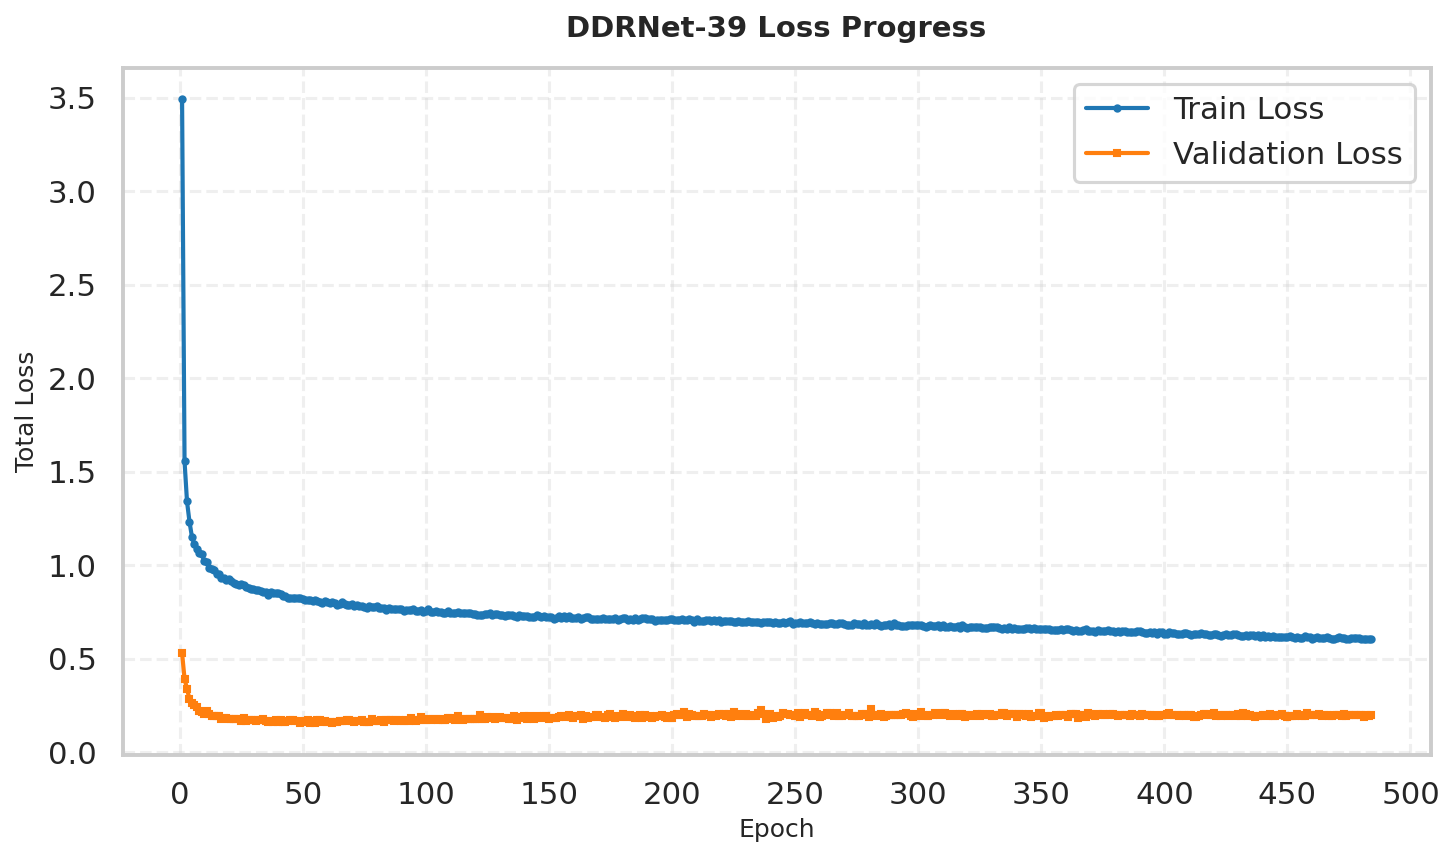

[✓] Saved: loss_comparison_DDRNet39.png


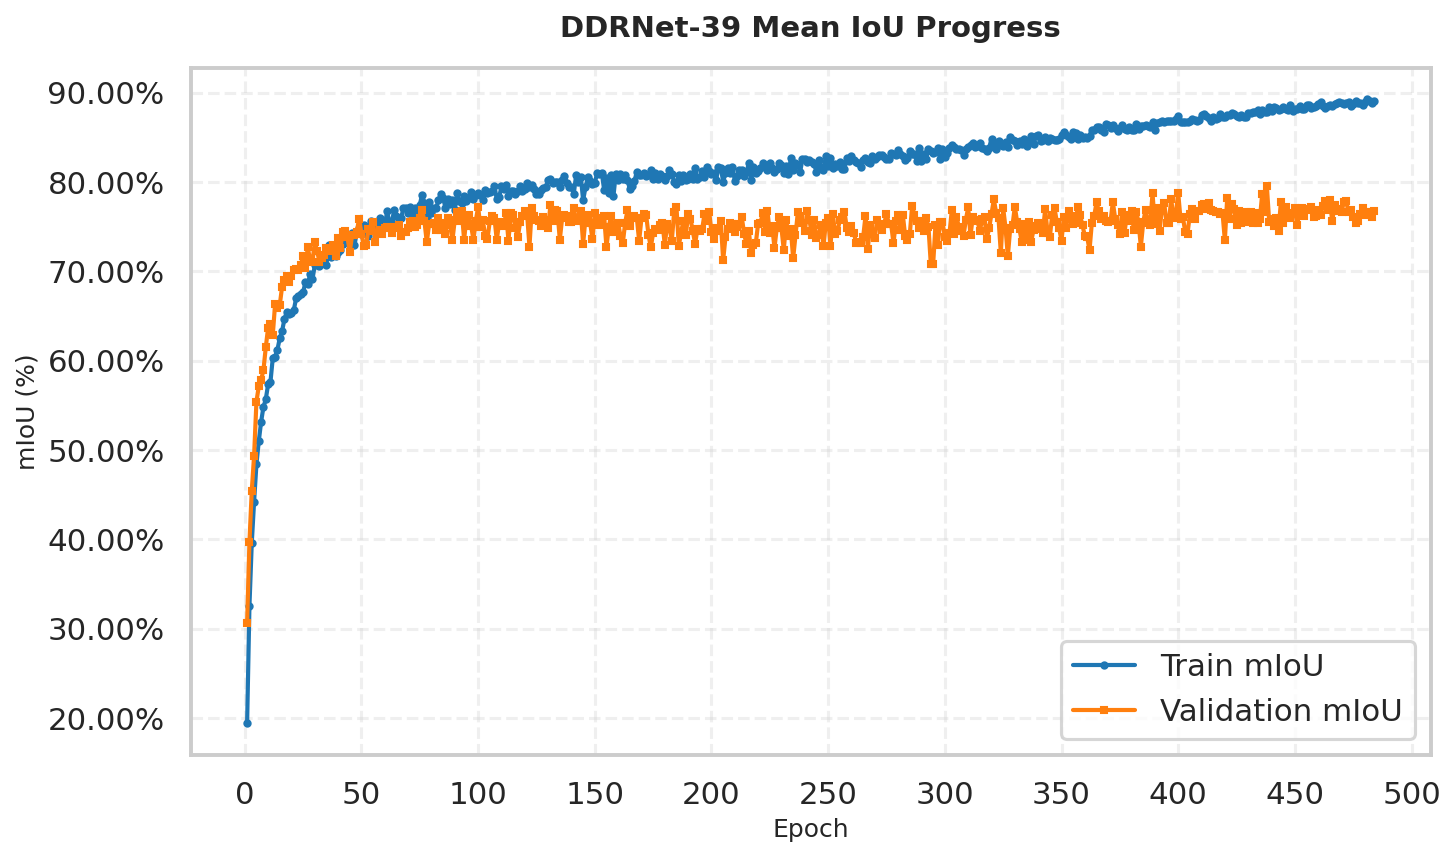

[✓] Saved: miou_progress_DDRNet39.png


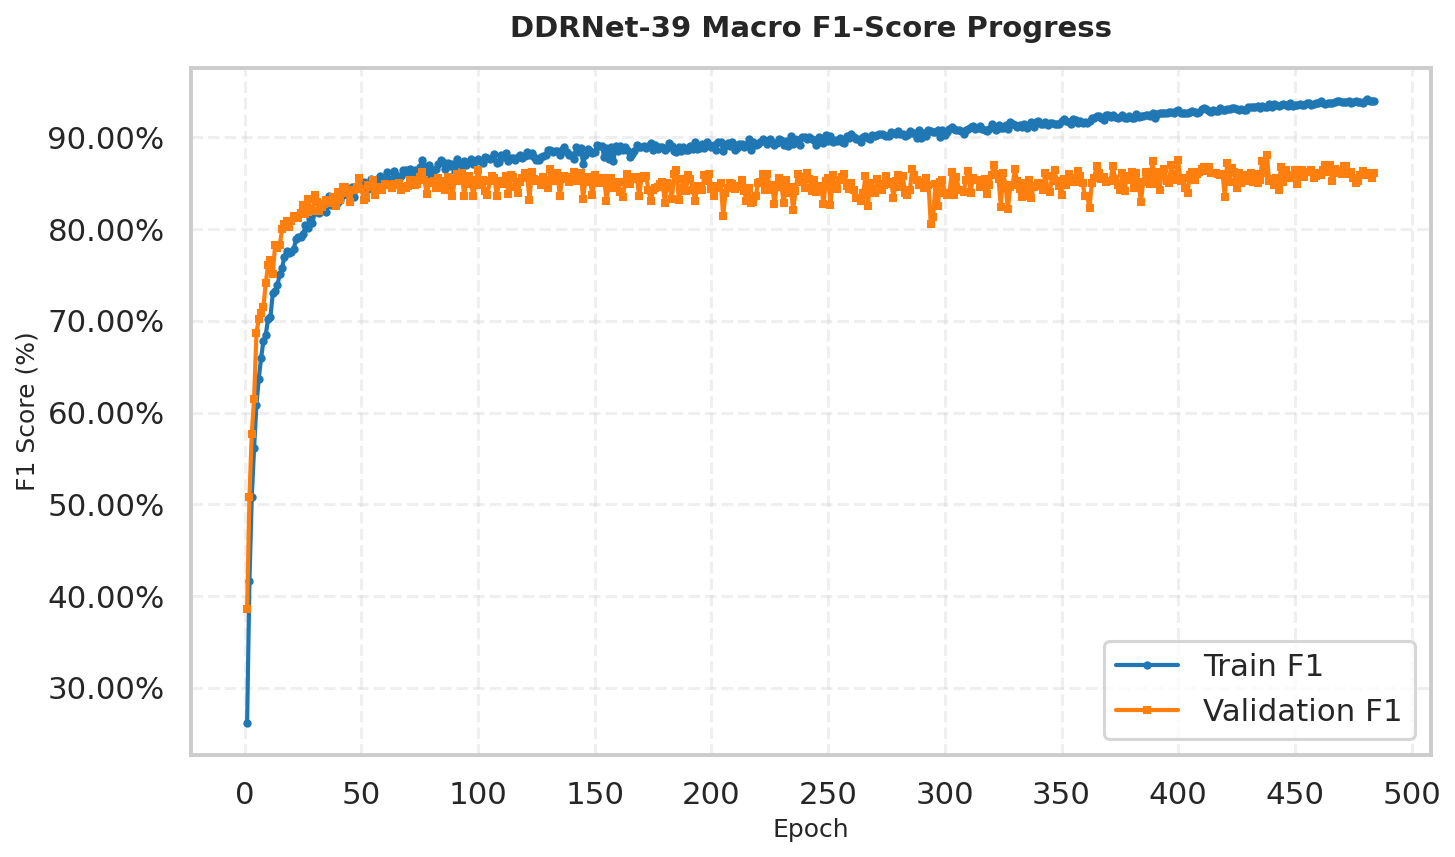

[✓] Saved: f1_progress_DDRNet39.png


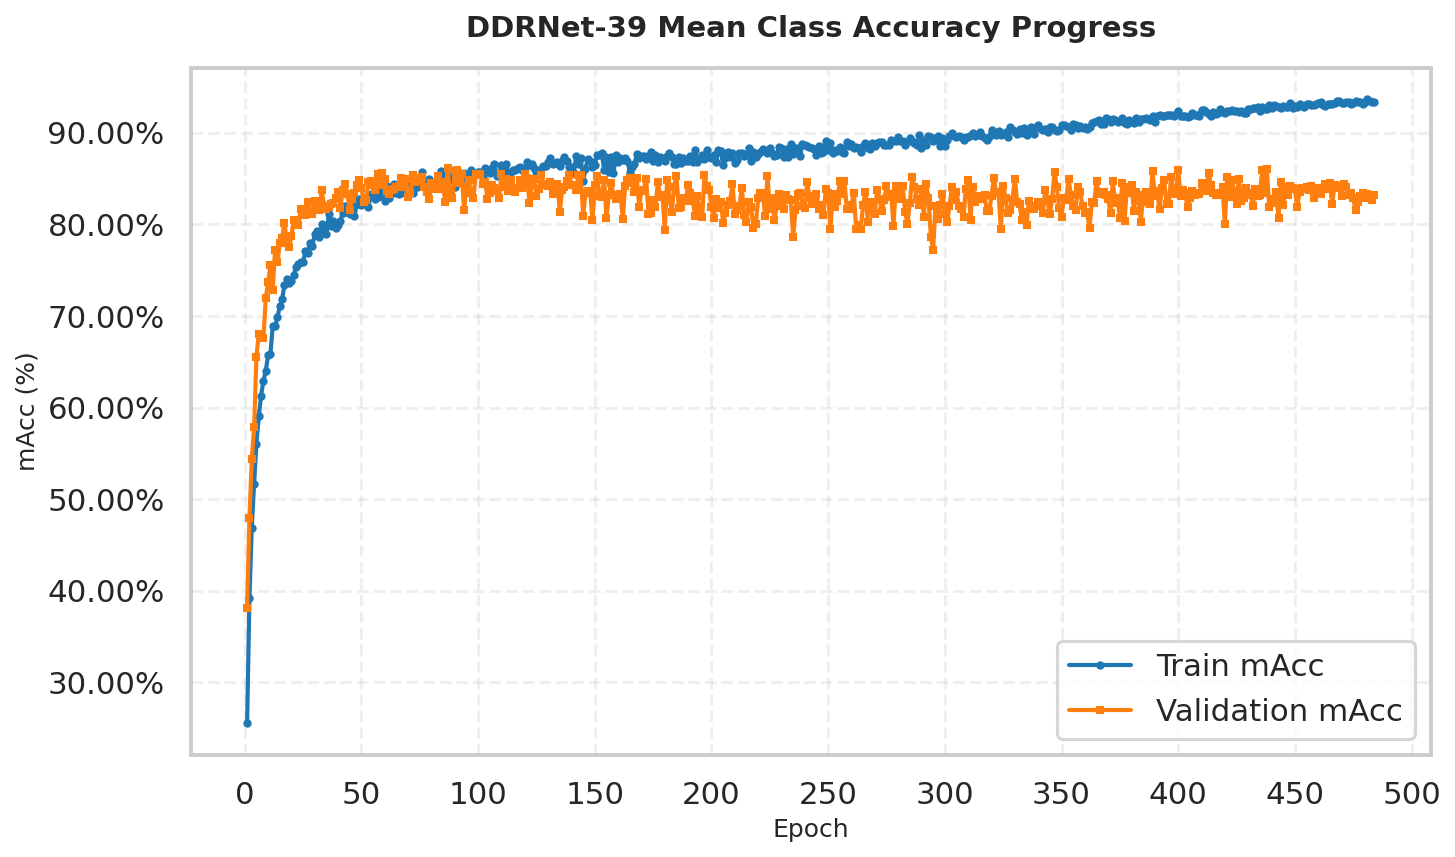

[✓] Saved: macc_progress_DDRNet39.png


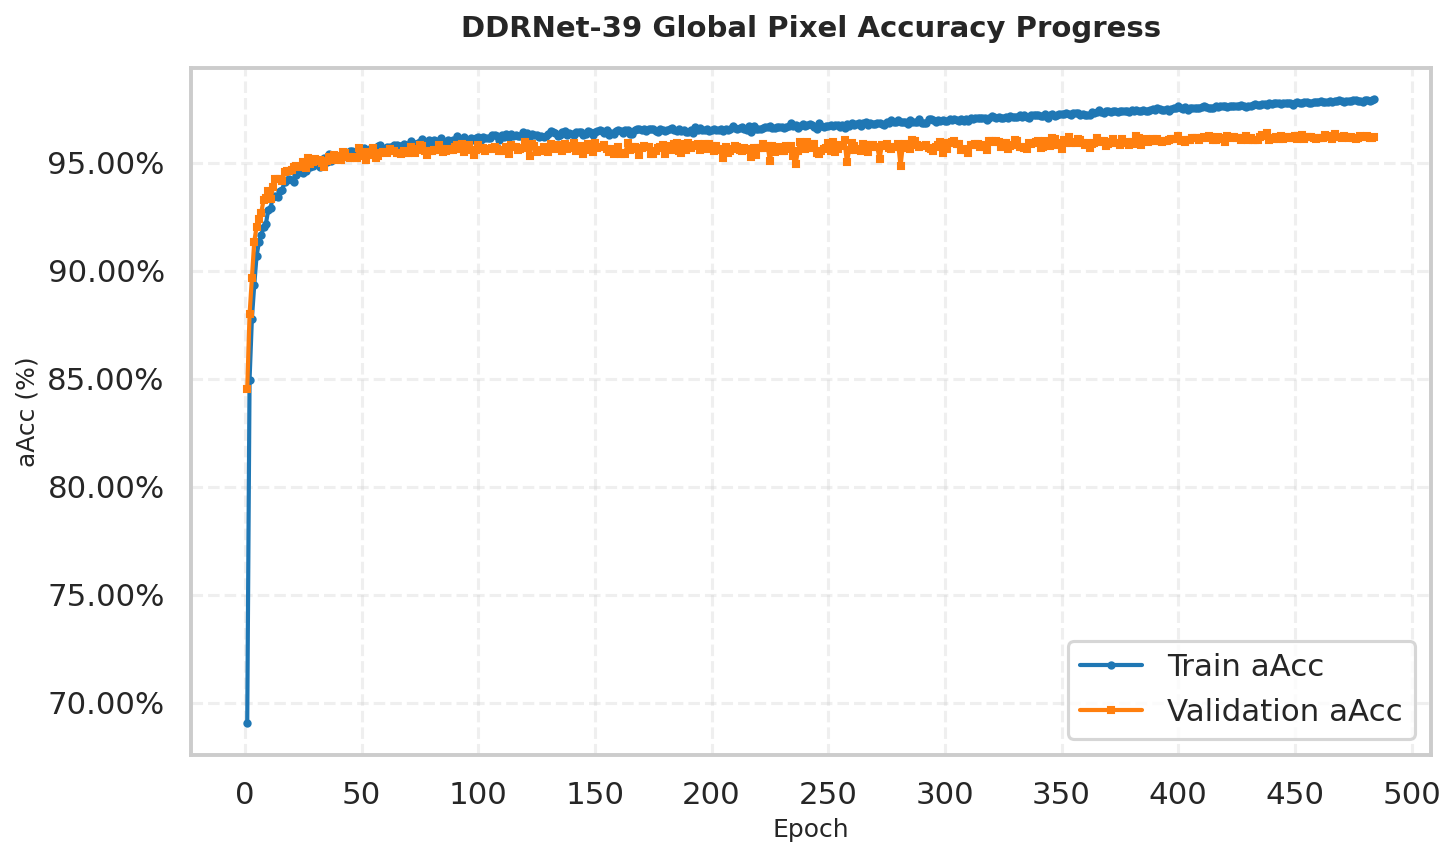

[✓] Saved: aacc_progress_DDRNet39.png


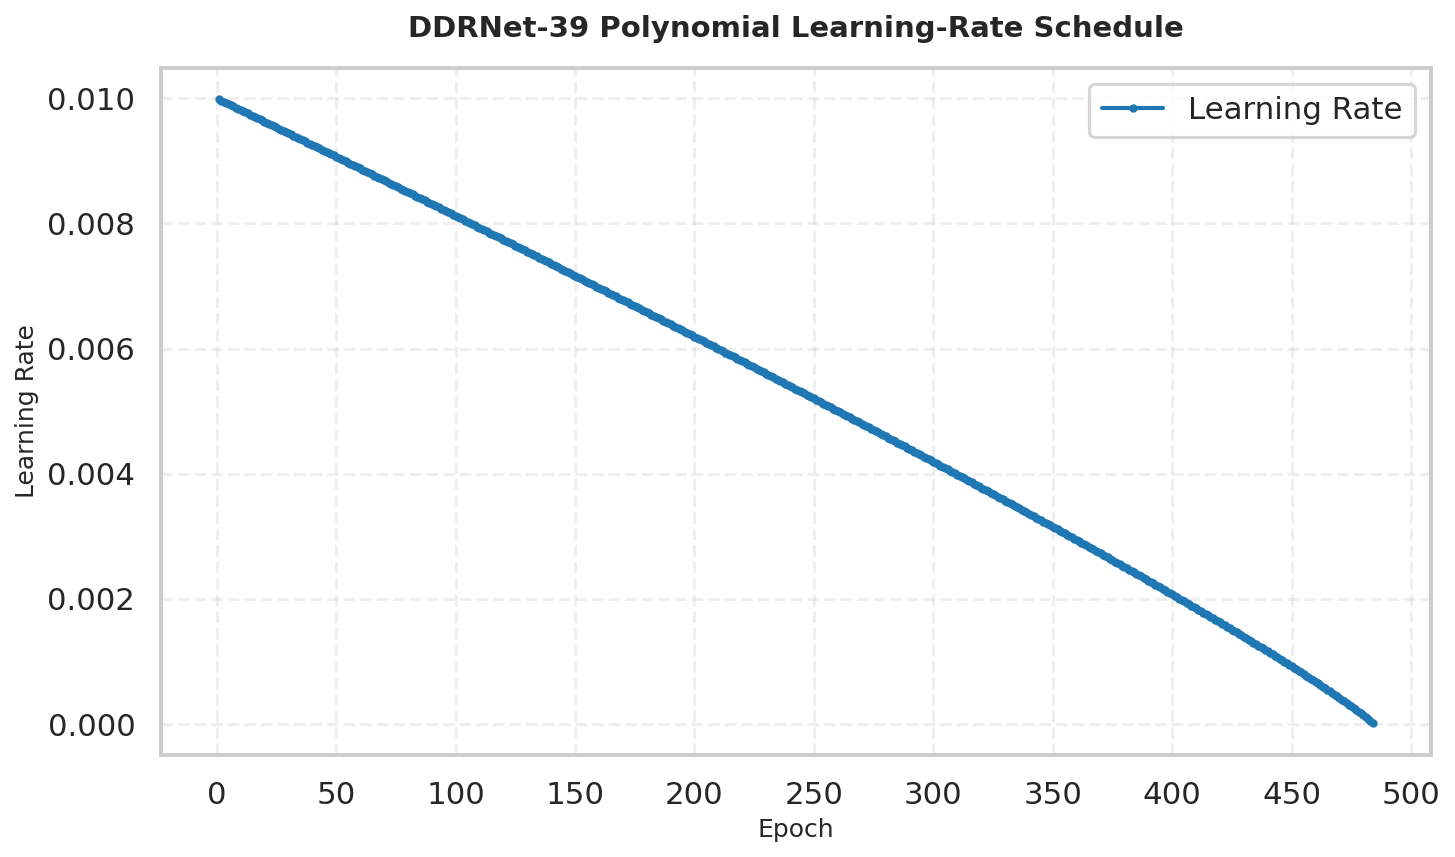

[✓] Saved: learning_rate_progress_DDRNet39.png


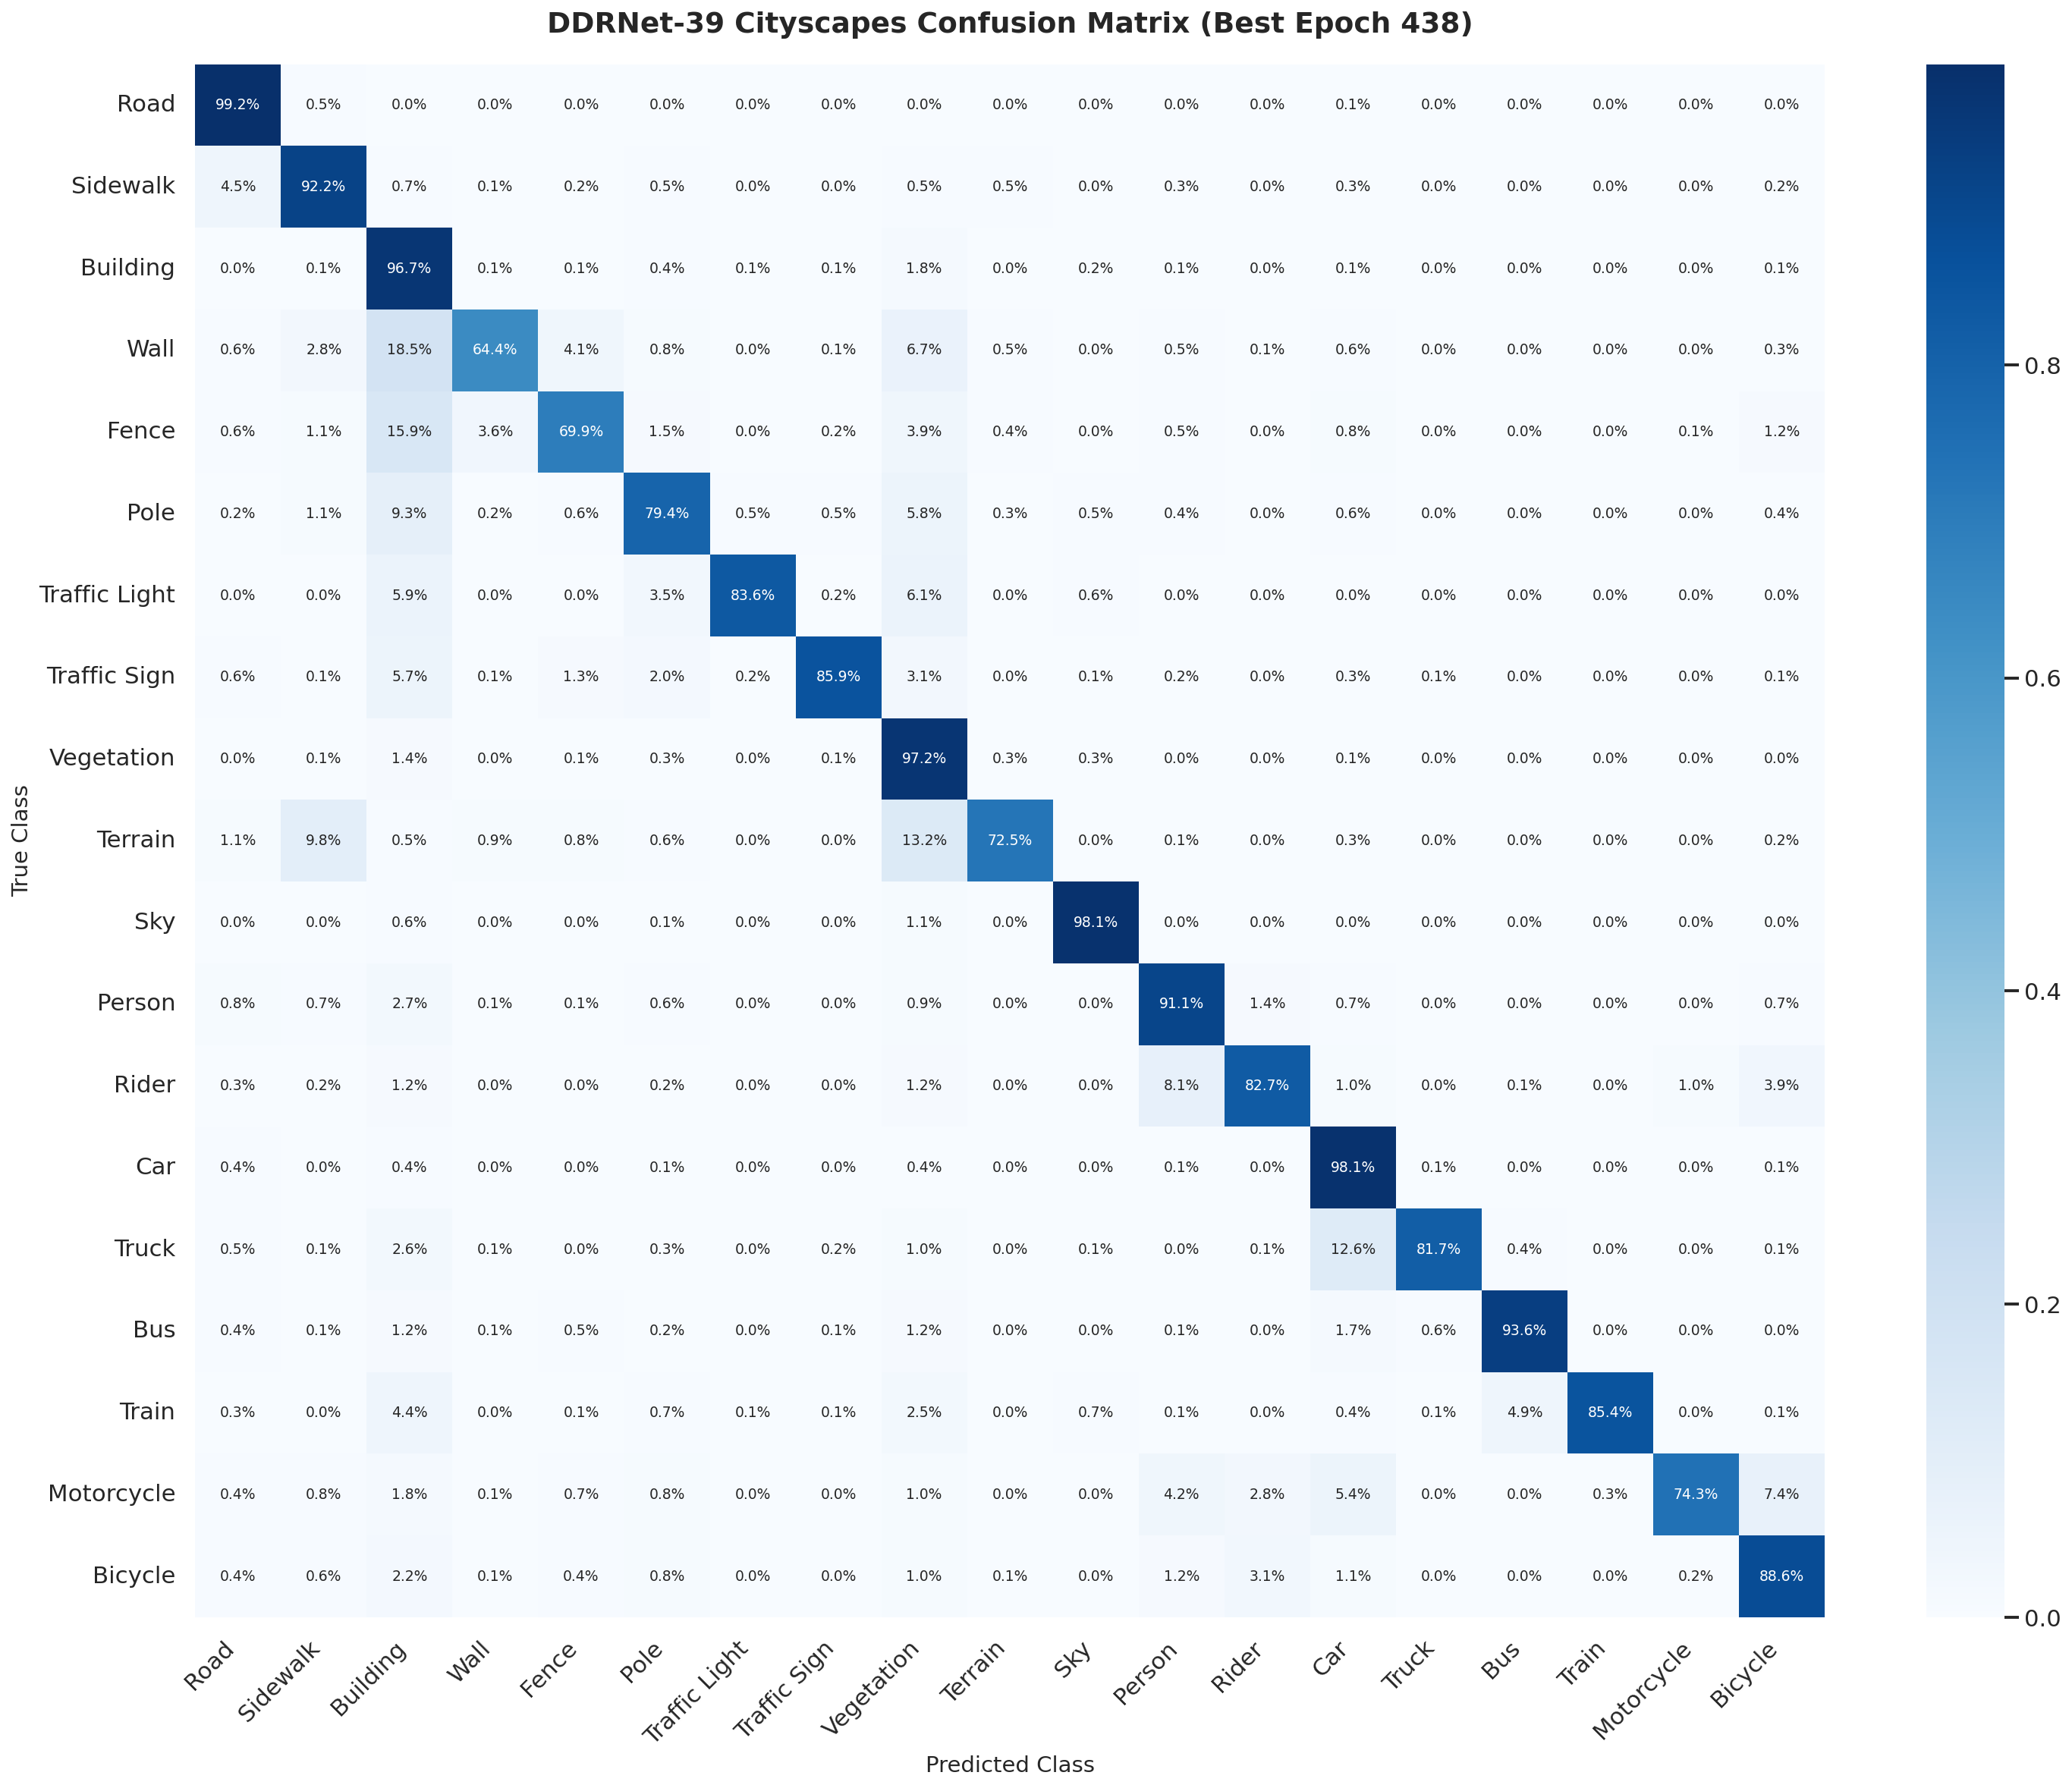

[✓] Saved: confusion_matrix_percentages_DDRNet39.png

NORMALIZED CONFUSION MATRIX (%)


,Road,Sidewalk,Building,Wall,Fence,Pole,Traffic Light,Traffic Sign,Vegetation,Terrain,Sky,Person,Rider,Car,Truck,Bus,Train,Motorcycle,Bicycle
Road,99.21,0.50,0.01,0.00,0.01,0.01,0.00,0.00,0.02,0.04,0.00,0.03,0.00,0.13,0.00,0.01,0.00,0.00,0.01
Sidewalk,4.53,92.16,0.73,0.13,0.16,0.49,0.00,0.01,0.49,0.46,0.00,0.25,0.02,0.31,0.01,0.01,0.00,0.02,0.21
Building,0.02,0.10,96.75,0.07,0.09,0.45,0.05,0.09,1.84,0.00,0.22,0.14,0.02,0.08,0.01,0.01,0.01,0.00,0.07
Wall,0.60,2.84,18.50,64.38,4.12,0.83,0.00,0.06,6.66,0.52,0.01,0.47,0.08,0.60,0.01,0.00,0.00,0.04,0.26
Fence,0.55,1.15,15.86,3.64,69.94,1.52,0.01,0.21,3.94,0.45,0.02,0.50,0.04,0.79,0.02,0.00,0.03,0.14,1.19
Pole,0.22,1.14,9.26,0.22,0.64,79.44,0.49,0.46,5.75,0.29,0.53,0.42,0.04,0.64,0.00,0.05,0.02,0.05,0.36
Traffic Light,0.00,0.00,5.91,0.00,0.00,3.45,83.63,0.20,6.12,0.00,0.57,0.02,0.02,0.02,0.00,0.01,0.04,0.00,0.00
Traffic Sign,0.64,0.10,5.71,0.10,1.29,2.04,0.15,85.88,3.09,0.01,0.10,0.19,0.04,0.34,0.13,0.04,0.01,0.01,0.11
Vegetation,0.03,0.09,1.39,0.03,0.08,0.35,0.04,0.05,97.23,0.27,0.26,0.05,0.01,0.07,0.00,0.01,0.00,0.00,0.03
Terrain,1.13,9.79,0.48,0.89,0.82,0.55,0.00,0.01,13.22,72.49,0.00,0.07,0.03,0.32,0.00,0.01,0.01,0.00,0.18



-----------------------------------------------------------------------------------------------
Architecture : DDRNet-39
Backbone     : Deep Dual-Resolution Network
Context      : Deep Aggregation Pyramid Pooling Module (DAPPM)
Fusion       : Multiple Bilateral Feature Fusions
Loss         : OHEM Main Loss + 0.4 × Auxiliary Cross-Entropy
Training Parameters  : 32,660,838 (32.66 M)
Auxiliary Parameters : 300,563 (0.30 M)
Inference Parameters : 32,360,275 (32.36 M)
-----------------------------------------------------------------------------------------------

FINAL RESULTS — DDRNet-39 / CITYSCAPES
Best Validation mIoU (Macro) : 79.53% (Epoch 438)
Best Validation mAcc         : 86.04%
Best Validation aAcc         : 96.38%
Best Validation Macro F1     : 88.05%
Best Validation Precision    : 90.52%
Best Validation Recall       : 86.04%
Total Training Time          : 1 day, 12:18:04

-----------------------------------------------------------------------------------------------
CLASS NAME 

In [10]:
# ============================================================
# STEP 6: DDRNet-39 FINAL RESULTS EXPORT, PLOTS,
#         BEST-CHECKPOINT CONFUSION MATRIX,
#         CLASS-WISE METRICS, AND FINAL SUMMARY
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# Cityscapes
#
# Important:
#   - Best checkpoint is reloaded from disk
#   - Best confusion matrix is reconstructed using the SAME
#     single-scale validation protocol used for checkpoint selection
#   - All tables are displayed in Jupyter
#   - All plots are displayed in Jupyter AND saved to disk
#   - No ONNX export
# ============================================================


# ============================================================
# SAFETY CHECKS
# ============================================================

required_globals = [
    "history",
    "model",
    "CLASS_NAMES",
    "CLASSES",
    "best_record",
    "DEVICE",
    "FINAL_SAVE_DIR",
    "val_loader",
    "IGNORE_INDEX",
    "ALIGN_CORNERS",
    "USE_AMP",
    "single_scale_inference",
    "fast_confusion_matrix",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise NameError(
        "Required variables/functions are missing. "
        f"Please run Steps 1-5 first.\nMissing: {missing_globals}"
    )


FINAL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"[*] Final export directory validated:\n"
    f"    {FINAL_SAVE_DIR.resolve()}\n"
)


# ============================================================
# BEST CHECKPOINT IDENTIFICATION
# ============================================================

best_ckpt_path = Path(
    best_record["best_path"]
)

if not best_ckpt_path.exists():
    raise FileNotFoundError(
        "DDRNet-39 best checkpoint was not found.\n"
        f"Expected:\n{best_ckpt_path}"
    )


best_epoch = best_record.get(
    "epoch",
    best_record.get(
        "best_epoch",
        -1
    )
)

best_miou_record = float(
    best_record.get(
        "best_miou",
        -1.0
    )
)


print(
    "--- Best DDRNet-39 Checkpoint ---"
)

print(
    f"[*] Best checkpoint : {best_ckpt_path}"
)

print(
    f"[*] Best epoch      : {best_epoch}"
)

print(
    f"[*] Stored mIoU     : {best_miou_record:.2f}%"
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

print(
    "\n[*] Loading best DDRNet-39 checkpoint "
    "for final metric reconstruction..."
)

best_checkpoint = torch.load(
    best_ckpt_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "[✓] Best DDRNet-39 checkpoint loaded successfully."
)


# ============================================================
# RECONSTRUCT BEST CONFUSION MATRIX
# ============================================================
#
# This is intentionally reconstructed from the best checkpoint
# rather than using val_conf_matrix left in RAM.
#
# Reason:
# val_conf_matrix in RAM normally belongs to the LAST epoch,
# which may not be the BEST epoch.
#
# We use the SAME:
#
#     native-resolution
#     single-scale
#     no-flip
#
# inference protocol used for best-checkpoint selection.
# ============================================================

print(
    "\n[*] Reconstructing best validation confusion matrix..."
)

BEST_CONF_MATRIX = np.zeros(
    (
        CLASSES,
        CLASSES
    ),
    dtype=np.int64
)

reconstruction_pbar = tqdm(
    val_loader,
    total=len(val_loader),
    desc="Best Model Validation Reconstruction",
    leave=True
)


with torch.inference_mode():

    for images, masks in reconstruction_pbar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        semantic_logits = single_scale_inference(
            model,
            images
        )

        predictions = torch.argmax(
            semantic_logits,
            dim=1
        )

        preds_np = (
            predictions
            .cpu()
            .numpy()
            .astype(
                np.int64,
                copy=False
            )
        )

        targets_np = (
            masks
            .cpu()
            .numpy()
            .astype(
                np.int64,
                copy=False
            )
        )

        valid = (
            targets_np
            != IGNORE_INDEX
        )

        if valid.any():

            BEST_CONF_MATRIX += fast_confusion_matrix(
                targets_np[valid],
                preds_np[valid],
                CLASSES
            )


print(
    "[✓] Best-model confusion matrix reconstruction complete."
)


# ============================================================
# FINAL METRICS FROM BEST CONFUSION MATRIX
# ============================================================

BEST_METRICS = compute_metrics(
    BEST_CONF_MATRIX
)

reconstructed_best_miou = (
    BEST_METRICS[
        "mIoU_Macro"
    ]
    * 100.0
)

reconstructed_best_macc = (
    BEST_METRICS[
        "Recall_Macro"
    ]
    * 100.0
)

reconstructed_best_aacc = (
    BEST_METRICS[
        "Global_Accuracy"
    ]
    * 100.0
)

reconstructed_best_f1 = (
    BEST_METRICS[
        "F1_Macro"
    ]
    * 100.0
)

reconstructed_best_precision = (
    BEST_METRICS[
        "Precision_Macro"
    ]
    * 100.0
)


print(
    "\n--- Best Checkpoint Metric Verification ---"
)

print(
    f"Stored Best mIoU        : "
    f"{best_miou_record:.4f}%"
)

print(
    f"Reconstructed Best mIoU : "
    f"{reconstructed_best_miou:.4f}%"
)

print(
    f"Absolute Difference     : "
    f"{abs(best_miou_record - reconstructed_best_miou):.6f} "
    f"percentage points"
)


# ============================================================
# BUILD COMPLETE EPOCH-WISE DATAFRAME
# ============================================================

num_epochs = len(
    history.get(
        "epoch",
        []
    )
)

if num_epochs == 0:
    raise RuntimeError(
        "Training history is empty."
    )


def get_hist_col(
    key,
    fallback_key=None
):
    """
    Safely reconstruct one history column while ensuring
    all columns have exactly num_epochs entries.
    """

    column = history.get(
        key,
        []
    )

    if len(column) == num_epochs:
        return column

    if fallback_key is not None:

        fallback = history.get(
            fallback_key,
            []
        )

        if len(fallback) == num_epochs:
            return fallback

    if len(column) > num_epochs:

        return column[
            :num_epochs
        ]

    if len(column) > 0:

        return (
            list(column)
            + [np.nan]
            * (
                num_epochs
                - len(column)
            )
        )

    return (
        [np.nan]
        * num_epochs
    )


epoch_metrics_df = pd.DataFrame(
    {
        "Epoch":
            get_hist_col(
                "epoch"
            ),

        "Train_Total_Loss":
            get_hist_col(
                "train_total_loss"
            ),

        "Train_Main_Loss":
            get_hist_col(
                "train_main_loss"
            ),

        "Train_Aux_Loss":
            get_hist_col(
                "train_aux_loss"
            ),

        "Validation_Loss":
            get_hist_col(
                "val_total_loss"
            ),

        "Train_mIoU":
            get_hist_col(
                "train_miou"
            ),

        "Validation_mIoU":
            get_hist_col(
                "val_miou"
            ),

        "Train_mAcc":
            get_hist_col(
                "train_macc"
            ),

        "Validation_mAcc":
            get_hist_col(
                "val_macc"
            ),

        "Train_aAcc":
            get_hist_col(
                "train_aacc"
            ),

        "Validation_aAcc":
            get_hist_col(
                "val_aacc"
            ),

        "Train_Precision_Macro":
            get_hist_col(
                "train_Precision_Macro"
            ),

        "Validation_Precision_Macro":
            get_hist_col(
                "val_Precision_Macro"
            ),

        "Train_Recall_Macro":
            get_hist_col(
                "train_Recall_Macro"
            ),

        "Validation_Recall_Macro":
            get_hist_col(
                "val_Recall_Macro"
            ),

        "Train_F1_Macro":
            get_hist_col(
                "train_F1_Macro"
            ),

        "Validation_F1_Macro":
            get_hist_col(
                "val_F1_Macro"
            ),

        "Train_Precision_Micro":
            get_hist_col(
                "train_Precision_Micro"
            ),

        "Validation_Precision_Micro":
            get_hist_col(
                "val_Precision_Micro"
            ),

        "Train_Recall_Micro":
            get_hist_col(
                "train_Recall_Micro"
            ),

        "Validation_Recall_Micro":
            get_hist_col(
                "val_Recall_Micro"
            ),

        "Train_F1_Micro":
            get_hist_col(
                "train_F1_Micro"
            ),

        "Validation_F1_Micro":
            get_hist_col(
                "val_F1_Micro"
            ),

        "Learning_Rate":
            get_hist_col(
                "learning_rate"
            ),

        "Epoch_Time_sec":
            get_hist_col(
                "epoch_time_sec"
            ),

        "Cumulative_Training_Time":
            get_hist_col(
                "total_training_time_str"
            ),
    }
)


# ============================================================
# TOTAL TRAINING TIME
# ============================================================

if (
    "cumulative_training_time_sec"
    in globals()
):

    total_training_time_sec = float(
        cumulative_training_time_sec
    )

else:

    total_training_time_sec = float(
        np.nansum(
            epoch_metrics_df[
                "Epoch_Time_sec"
            ].values
        )
    )


total_time_str = str(
    datetime.timedelta(
        seconds=int(
            total_training_time_sec
        )
    )
)


# ============================================================
# CLASS-WISE METRICS
# ============================================================

tp = np.diag(
    BEST_CONF_MATRIX
).astype(
    np.float64
)

fp = (
    BEST_CONF_MATRIX.sum(
        axis=0
    )
    - tp
)

fn = (
    BEST_CONF_MATRIX.sum(
        axis=1
    )
    - tp
)


iou_denominator = (
    tp
    + fp
    + fn
)

precision_denominator = (
    tp
    + fp
)

recall_denominator = (
    tp
    + fn
)


iou_per_class = np.divide(
    tp,
    iou_denominator,
    out=np.zeros_like(
        tp,
        dtype=np.float64
    ),
    where=(
        iou_denominator
        > 0
    )
)


precision_per_class = np.divide(
    tp,
    precision_denominator,
    out=np.zeros_like(
        tp,
        dtype=np.float64
    ),
    where=(
        precision_denominator
        > 0
    )
)


recall_per_class = np.divide(
    tp,
    recall_denominator,
    out=np.zeros_like(
        tp,
        dtype=np.float64
    ),
    where=(
        recall_denominator
        > 0
    )
)


f1_denominator = (
    precision_per_class
    + recall_per_class
)


f1_per_class = np.divide(
    2.0
    * precision_per_class
    * recall_per_class,
    f1_denominator,
    out=np.zeros_like(
        tp,
        dtype=np.float64
    ),
    where=(
        f1_denominator
        > 0
    )
)


class_wise_df = pd.DataFrame(
    {
        "Class Name":
            CLASS_NAMES,

        "IoU (%)":
            iou_per_class
            * 100.0,

        "F1-Score (%)":
            f1_per_class
            * 100.0,

        "Precision (%)":
            precision_per_class
            * 100.0,

        "Recall / Class Accuracy (%)":
            recall_per_class
            * 100.0,
    }
)


# ============================================================
# RAW + NORMALIZED CONFUSION MATRIX DATAFRAMES
# ============================================================

confusion_matrix_counts_df = pd.DataFrame(
    BEST_CONF_MATRIX,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


row_sums = BEST_CONF_MATRIX.sum(
    axis=1,
    keepdims=True
)


confusion_matrix_percent = np.divide(
    BEST_CONF_MATRIX.astype(
        np.float64
    ),
    row_sums,
    out=np.zeros_like(
        BEST_CONF_MATRIX,
        dtype=np.float64
    ),
    where=(
        row_sums
        != 0
    )
) * 100.0


confusion_matrix_percent_df = pd.DataFrame(
    confusion_matrix_percent,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


# ============================================================
# FINAL GLOBAL RESULTS
# ============================================================

final_global_results_df = pd.DataFrame(
    [
        {
            "Metric":
                "Best Validation mIoU (Macro)",

            "Value":
                f"{reconstructed_best_miou:.2f}%"
        },

        {
            "Metric":
                "Best Validation Mean Class Accuracy (mAcc)",

            "Value":
                f"{reconstructed_best_macc:.2f}%"
        },

        {
            "Metric":
                "Best Validation Global Pixel Accuracy (aAcc)",

            "Value":
                f"{reconstructed_best_aacc:.2f}%"
        },

        {
            "Metric":
                "Best Validation F1 Score (Macro)",

            "Value":
                f"{reconstructed_best_f1:.2f}%"
        },

        {
            "Metric":
                "Best Validation Precision (Macro)",

            "Value":
                f"{reconstructed_best_precision:.2f}%"
        },

        {
            "Metric":
                "Best Validation Recall (Macro)",

            "Value":
                f"{reconstructed_best_macc:.2f}%"
        },

        {
            "Metric":
                "Best Epoch",

            "Value":
                str(
                    best_epoch
                )
        },

        {
            "Metric":
                "Total Training Time",

            "Value":
                total_time_str
        },
    ]
)


# ============================================================
# SAVE CSV FILES
# ============================================================

epoch_csv_path = (
    FINAL_SAVE_DIR
    / "epoch_metrics_DDRNet39.csv"
)

class_csv_path = (
    FINAL_SAVE_DIR
    / "classwise_metrics_DDRNet39.csv"
)

final_csv_path = (
    FINAL_SAVE_DIR
    / "finalresults_DDRNet39.csv"
)

cm_counts_csv_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_counts_DDRNet39.csv"
)

cm_percent_csv_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_percent_DDRNet39.csv"
)


epoch_metrics_df.to_csv(
    epoch_csv_path,
    index=False
)

class_wise_df.to_csv(
    class_csv_path,
    index=False
)

final_global_results_df.to_csv(
    final_csv_path,
    index=False
)

confusion_matrix_counts_df.to_csv(
    cm_counts_csv_path
)

confusion_matrix_percent_df.to_csv(
    cm_percent_csv_path
)


# ============================================================
# SAVE COMPLETE EXCEL REPORT
# ============================================================

excel_path = (
    FINAL_SAVE_DIR
    / "Training_Metrics_Report_DDRNet39.xlsx"
)


with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    epoch_metrics_df.to_excel(
        writer,
        sheet_name="Epoch_Metrics",
        index=False
    )

    final_global_results_df.to_excel(
        writer,
        sheet_name="Final_Results",
        index=False
    )

    class_wise_df.to_excel(
        writer,
        sheet_name="Class_Wise_Results",
        index=False
    )

    confusion_matrix_counts_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix_Counts"
    )

    confusion_matrix_percent_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix_Percent"
    )


print(
    "\n[✓] CSV and Excel reports saved successfully."
)


# ============================================================
# DISPLAY TABLES IN JUPYTER
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "FINAL DDRNet-39 GLOBAL RESULTS"
)

print(
    "=" * 80
)

display(
    final_global_results_df
)


print(
    "\n"
    + "=" * 80
)

print(
    "DDRNet-39 CLASS-WISE CITYSCAPES RESULTS"
)

print(
    "=" * 80
)

display(
    class_wise_df.style.format(
        {
            "IoU (%)":
                "{:.2f}",

            "F1-Score (%)":
                "{:.2f}",

            "Precision (%)":
                "{:.2f}",

            "Recall / Class Accuracy (%)":
                "{:.2f}",
        }
    )
)


print(
    "\n"
    + "=" * 80
)

print(
    "FINAL EPOCH-WISE TRAINING HISTORY"
)

print(
    "=" * 80
)

display(
    epoch_metrics_df
)


# ============================================================
# PLOT HELPER
# ============================================================
#
# Every generated plot is:
#
#   1. Saved at 600 DPI
#   2. Displayed directly in Jupyter
#
# ============================================================

def save_separate_plot(
    filename,
    title,
    ylabel,
    train_data,
    val_data=None,
    label1="Train",
    label2="Validation",
    is_percentage=False,
):

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    epochs_range = (
        epoch_metrics_df[
            "Epoch"
        ]
        .to_numpy(
            dtype=float
        )
    )

    train_clean = np.asarray(
        train_data,
        dtype=np.float64
    )

    if not np.isnan(
        train_clean
    ).all():

        ax.plot(
            epochs_range,
            train_clean,
            label=label1,
            linewidth=2,
            marker="o",
            markersize=3
        )


    if val_data is not None:

        val_clean = np.asarray(
            val_data,
            dtype=np.float64
        )

        if not np.isnan(
            val_clean
        ).all():

            ax.plot(
                epochs_range,
                val_clean,
                label=label2,
                linewidth=2,
                marker="s",
                markersize=3
            )


    if is_percentage:

        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(
                decimals=2
            )
        )


    # Avoid >90 unreadable x-axis labels over 484 epochs.
    ax.xaxis.set_major_locator(
        mtick.MaxNLocator(
            integer=True,
            nbins=12
        )
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Epoch",
        fontsize=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12
    )

    ax.legend()

    ax.grid(
        True,
        alpha=0.3,
        linestyle="--"
    )

    fig.tight_layout()


    output_path = (
        FINAL_SAVE_DIR
        / f"{filename}.png"
    )


    fig.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # Show plot inside Jupyter notebook.
    # --------------------------------------------------------

    plt.show()

    plt.close(
        fig
    )


    print(
        f"[✓] Saved: {output_path.name}"
    )


# ============================================================
# EXTRACT PLOT DATA
# ============================================================

train_total_loss = (
    epoch_metrics_df[
        "Train_Total_Loss"
    ].tolist()
)

val_total_loss = (
    epoch_metrics_df[
        "Validation_Loss"
    ].tolist()
)

train_miou = (
    epoch_metrics_df[
        "Train_mIoU"
    ].tolist()
)

val_miou = (
    epoch_metrics_df[
        "Validation_mIoU"
    ].tolist()
)

train_f1 = (
    epoch_metrics_df[
        "Train_F1_Macro"
    ].tolist()
)

val_f1 = (
    epoch_metrics_df[
        "Validation_F1_Macro"
    ].tolist()
)

train_macc = (
    epoch_metrics_df[
        "Train_mAcc"
    ].tolist()
)

val_macc = (
    epoch_metrics_df[
        "Validation_mAcc"
    ].tolist()
)

train_aacc = (
    epoch_metrics_df[
        "Train_aAcc"
    ].tolist()
)

val_aacc = (
    epoch_metrics_df[
        "Validation_aAcc"
    ].tolist()
)

learning_rate = (
    epoch_metrics_df[
        "Learning_Rate"
    ].tolist()
)


# ============================================================
# 1. LOSS PLOT
# ============================================================

save_separate_plot(
    filename="loss_comparison_DDRNet39",
    title="DDRNet-39 Loss Progress",
    ylabel="Total Loss",
    train_data=train_total_loss,
    val_data=val_total_loss,
    label1="Train Loss",
    label2="Validation Loss"
)


# ============================================================
# 2. mIoU PLOT
# ============================================================

save_separate_plot(
    filename="miou_progress_DDRNet39",
    title="DDRNet-39 Mean IoU Progress",
    ylabel="mIoU (%)",
    train_data=train_miou,
    val_data=val_miou,
    label1="Train mIoU",
    label2="Validation mIoU",
    is_percentage=True
)


# ============================================================
# 3. MACRO F1 PLOT
# ============================================================

save_separate_plot(
    filename="f1_progress_DDRNet39",
    title="DDRNet-39 Macro F1-Score Progress",
    ylabel="F1 Score (%)",
    train_data=train_f1,
    val_data=val_f1,
    label1="Train F1",
    label2="Validation F1",
    is_percentage=True
)


# ============================================================
# 4. mAcc PLOT
# ============================================================

save_separate_plot(
    filename="macc_progress_DDRNet39",
    title="DDRNet-39 Mean Class Accuracy Progress",
    ylabel="mAcc (%)",
    train_data=train_macc,
    val_data=val_macc,
    label1="Train mAcc",
    label2="Validation mAcc",
    is_percentage=True
)


# ============================================================
# 5. GLOBAL PIXEL ACCURACY PLOT
# ============================================================

save_separate_plot(
    filename="aacc_progress_DDRNet39",
    title="DDRNet-39 Global Pixel Accuracy Progress",
    ylabel="aAcc (%)",
    train_data=train_aacc,
    val_data=val_aacc,
    label1="Train aAcc",
    label2="Validation aAcc",
    is_percentage=True
)


# ============================================================
# 6. LEARNING-RATE PLOT
# ============================================================

save_separate_plot(
    filename="learning_rate_progress_DDRNet39",
    title="DDRNet-39 Polynomial Learning-Rate Schedule",
    ylabel="Learning Rate",
    train_data=learning_rate,
    label1="Learning Rate"
)


# ============================================================
# CONFUSION MATRIX — PERCENTAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(20, 16)
)


sns.heatmap(
    confusion_matrix_percent / 100.0,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={
        "size": 9
    },
    ax=ax
)


ax.set_title(
    (
        "DDRNet-39 Cityscapes Confusion Matrix "
        f"(Best Epoch {best_epoch})"
    ),
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_ylabel(
    "True Class",
    fontsize=14
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=14
)

ax.tick_params(
    axis="x",
    rotation=45
)

for tick_label in ax.get_xticklabels():
    tick_label.set_horizontalalignment(
        "right"
    )


fig.tight_layout()


confusion_matrix_plot_path = (
    FINAL_SAVE_DIR
    / "confusion_matrix_percentages_DDRNet39.png"
)


fig.savefig(
    confusion_matrix_plot_path,
    dpi=600,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# Visible directly in Jupyter
# ------------------------------------------------------------

plt.show()

plt.close(
    fig
)


print(
    f"[✓] Saved: "
    f"{confusion_matrix_plot_path.name}"
)


# ============================================================
# DISPLAY NORMALIZED CONFUSION MATRIX AS TABLE
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "NORMALIZED CONFUSION MATRIX (%)"
)

print(
    "=" * 80
)


display(
    confusion_matrix_percent_df.style.format(
        "{:.2f}"
    )
)


# ============================================================
# MODEL PARAMETER SUMMARY
# ============================================================

training_total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)


trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


if hasattr(
    model,
    "seghead_extra"
):

    auxiliary_params = sum(
        parameter.numel()
        for parameter
        in model.seghead_extra.parameters()
    )

else:

    auxiliary_params = 0


inference_params = (
    training_total_params
    - auxiliary_params
)


# ============================================================
# FINAL TEXT SUMMARY — VISIBLE IN JUPYTER
# ============================================================

print(
    "\n"
    + "-" * 95
)

print(
    "Architecture : DDRNet-39"
)

print(
    "Backbone     : Deep Dual-Resolution Network"
)

print(
    "Context      : Deep Aggregation Pyramid Pooling Module (DAPPM)"
)

print(
    "Fusion       : Multiple Bilateral Feature Fusions"
)

print(
    "Loss         : OHEM Main Loss + 0.4 × Auxiliary Cross-Entropy"
)

print(
    f"Training Parameters  : "
    f"{training_total_params:,} "
    f"({training_total_params / 1e6:.2f} M)"
)

print(
    f"Auxiliary Parameters : "
    f"{auxiliary_params:,} "
    f"({auxiliary_params / 1e6:.2f} M)"
)

print(
    f"Inference Parameters : "
    f"{inference_params:,} "
    f"({inference_params / 1e6:.2f} M)"
)

print(
    "-" * 95
)


print(
    "\n"
    + "=" * 95
)

print(
    "FINAL RESULTS — DDRNet-39 / CITYSCAPES"
)

print(
    "=" * 95
)

print(
    f"Best Validation mIoU (Macro) : "
    f"{reconstructed_best_miou:.2f}% "
    f"(Epoch {best_epoch})"
)

print(
    f"Best Validation mAcc         : "
    f"{reconstructed_best_macc:.2f}%"
)

print(
    f"Best Validation aAcc         : "
    f"{reconstructed_best_aacc:.2f}%"
)

print(
    f"Best Validation Macro F1     : "
    f"{reconstructed_best_f1:.2f}%"
)

print(
    f"Best Validation Precision    : "
    f"{reconstructed_best_precision:.2f}%"
)

print(
    f"Best Validation Recall       : "
    f"{reconstructed_best_macc:.2f}%"
)

print(
    f"Total Training Time          : "
    f"{total_time_str}"
)

print(
    "=" * 95
)


# ============================================================
# CLASS-WISE TEXT SUMMARY
# ============================================================

print(
    "\n"
    + "-" * 95
)

print(
    f"{'CLASS NAME':<18} | "
    f"{'IoU (%)':>10} | "
    f"{'F1 (%)':>10} | "
    f"{'Precision (%)':>14} | "
    f"{'Recall (%)':>12}"
)

print(
    "-" * 95
)


for _, row in class_wise_df.iterrows():

    print(
        f"{row['Class Name']:<18} | "
        f"{row['IoU (%)']:>10.2f} | "
        f"{row['F1-Score (%)']:>10.2f} | "
        f"{row['Precision (%)']:>14.2f} | "
        f"{row['Recall / Class Accuracy (%)']:>12.2f}"
    )


print(
    "-" * 95
)


# ============================================================
# OUTPUT FILE SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 95
)

print(
    "EXPORTED DDRNet-39 ARTIFACTS"
)

print(
    "=" * 95
)


exported_files = [
    epoch_csv_path,
    class_csv_path,
    final_csv_path,
    cm_counts_csv_path,
    cm_percent_csv_path,
    excel_path,

    FINAL_SAVE_DIR
    / "loss_comparison_DDRNet39.png",

    FINAL_SAVE_DIR
    / "miou_progress_DDRNet39.png",

    FINAL_SAVE_DIR
    / "f1_progress_DDRNet39.png",

    FINAL_SAVE_DIR
    / "macc_progress_DDRNet39.png",

    FINAL_SAVE_DIR
    / "aacc_progress_DDRNet39.png",

    FINAL_SAVE_DIR
    / "learning_rate_progress_DDRNet39.png",

    confusion_matrix_plot_path,
]


for path in exported_files:

    print(
        f"[✓] {path.name}"
    )


print(
    "\nSUCCESS: All DDRNet-39 tables, metrics, "
    "plots and confusion matrices were both "
    "displayed in Jupyter and exported to:"
)

print(
    FINAL_SAVE_DIR.resolve()
)


DDRNet-39 STEP 7 — PLOTTING SUMMARY
[*] Recorded epochs        : 484
[*] First recorded epoch   : 1
[*] Final recorded epoch   : 484
[*] Best validation mIoU   : 79.53%
[*] Best epoch             : 438

[✓] DDRNet-39 combined metrics graph saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/presentation_combined_metrics_DDRNet39.png


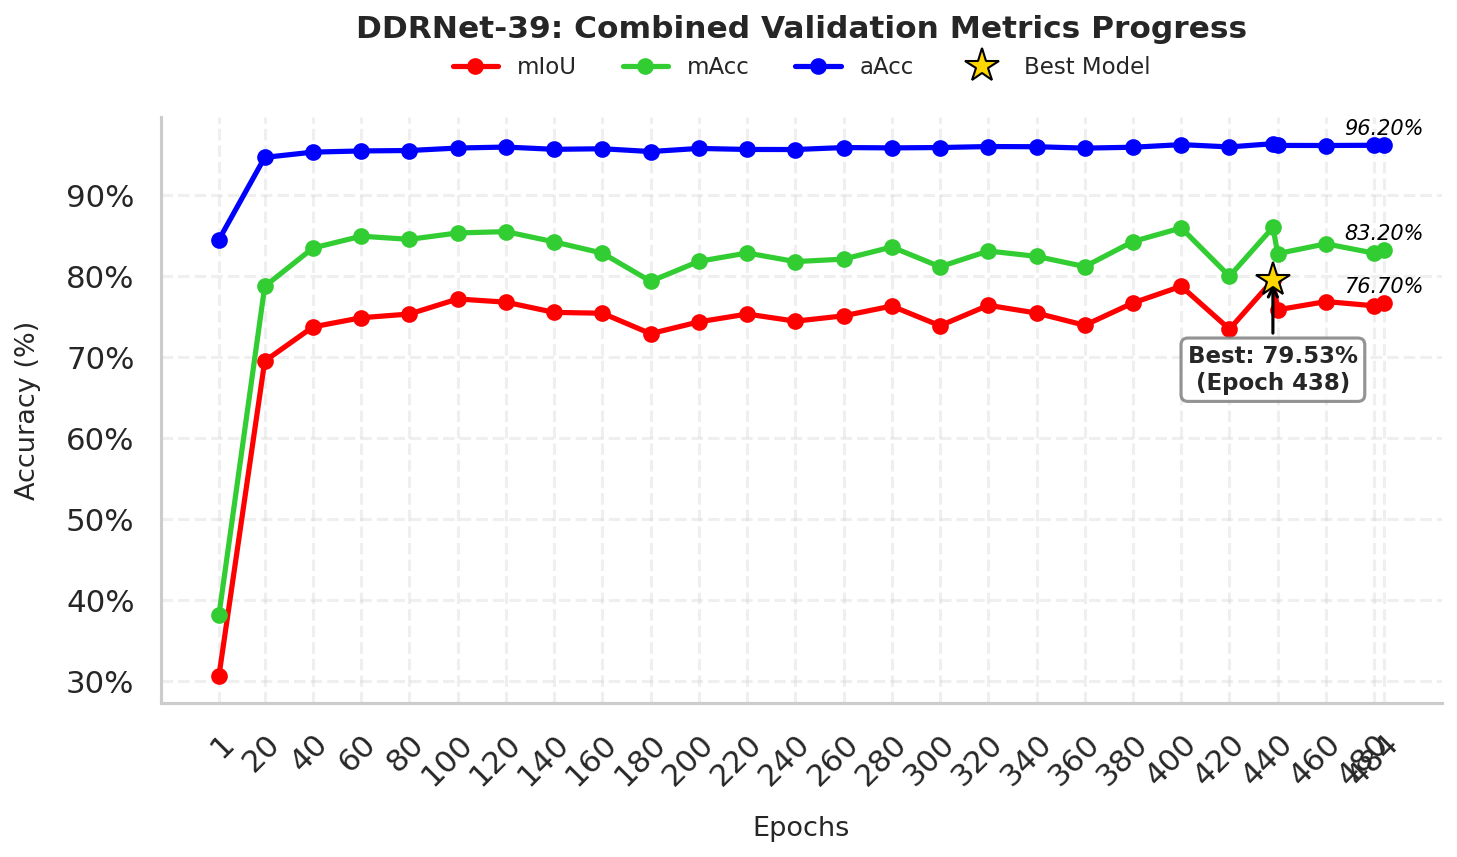


[✓] DDRNet-39 filtered PolyLR graph saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/Results_Export_DDRNet_cityscapes/presentation_learning_rate_schedule_DDRNet39.png


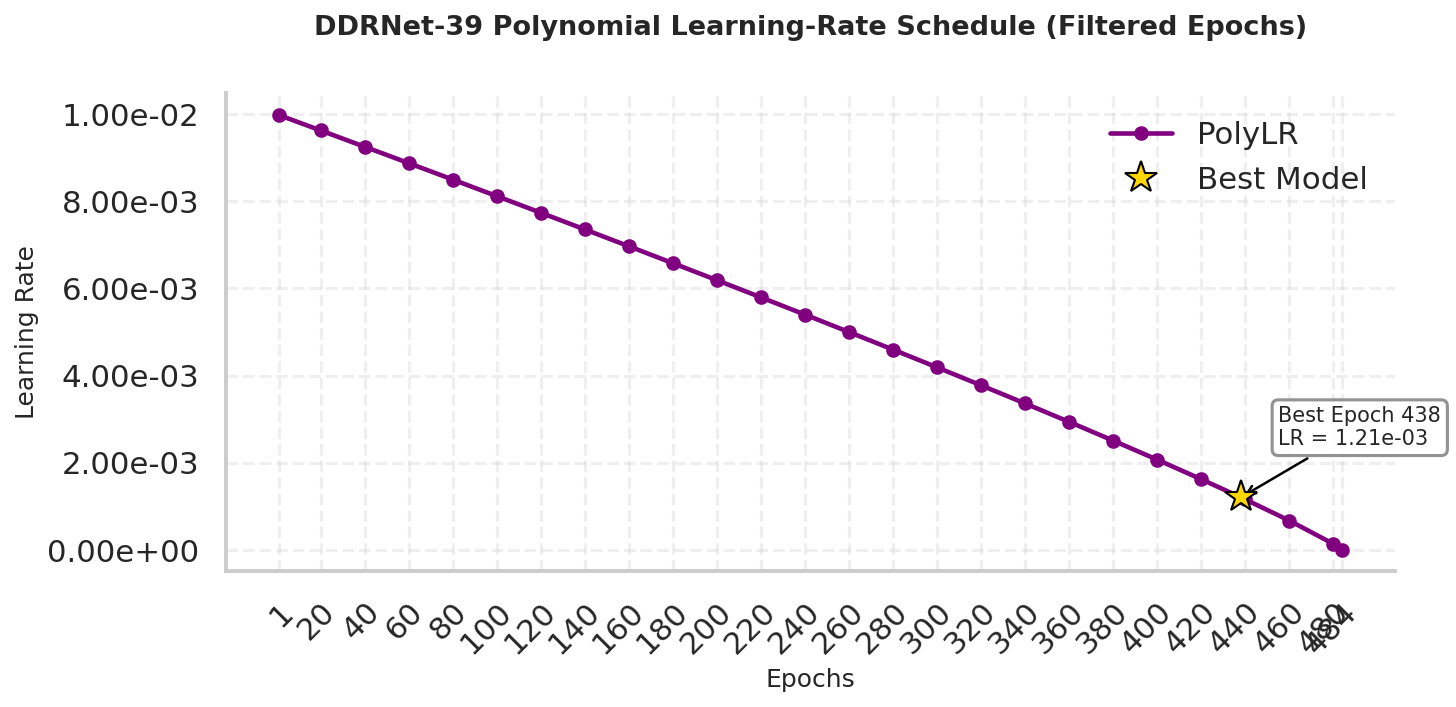


STEP 7 COMPLETE — DDRNet-39
Best Validation mIoU : 79.53%
Best Epoch           : 438
Final Validation mIoU: 76.70%
Final Validation mAcc: 83.20%
Final Validation aAcc: 96.20%
Epoch Sampling Step  : 20
Displayed Data Points: 27

Generated figures:
1. presentation_combined_metrics_DDRNet39.png
2. presentation_learning_rate_schedule_DDRNet39.png

All Step 7 figures were displayed inside Jupyter and saved at 600 DPI.


In [11]:
# ============================================================
# STEP 7: DDRNet-39 FILTERED COMBINED METRICS PLOT
#         AND POLYNOMIAL LEARNING-RATE PLOT
#
# Target Architecture:
# DDRNet-39
#
# Target Dataset:
# Cityscapes
#
# Purpose:
#   - Publication-ready combined metrics plot
#   - Clean filtered epoch axis
#   - Highlight best validation mIoU
#   - Filtered PolyLR visualization
#   - Display all figures directly in Jupyter
#   - Save all figures at 600 DPI
# ============================================================


# ============================================================
# 0. SAFETY CHECKS
# ============================================================

required_history_keys = [
    "epoch",
    "val_miou",
    "val_macc",
    "val_aacc",
    "learning_rate",
]

missing_history_keys = [
    key
    for key in required_history_keys
    if key not in history
    or len(history[key]) == 0
]

if missing_history_keys:
    raise ValueError(
        "Required DDRNet-39 history entries are missing or empty: "
        f"{missing_history_keys}"
    )


if not FINAL_SAVE_DIR.exists():
    raise FileNotFoundError(
        "FINAL_SAVE_DIR does not exist. "
        "Run the previous setup/export steps first."
    )


history_length = len(
    history["epoch"]
)


for key in required_history_keys:

    if len(history[key]) != history_length:

        raise ValueError(
            f"History length mismatch for '{key}'. "
            f"Expected {history_length}, "
            f"found {len(history[key])}."
        )


# ============================================================
# 1. BEST DDRNet-39 VALIDATION mIoU
# ============================================================

epoch_values = np.asarray(
    history["epoch"],
    dtype=int
)

val_miou_values = np.asarray(
    history["val_miou"],
    dtype=np.float64
)


if np.isnan(
    val_miou_values
).all():

    raise ValueError(
        "All validation mIoU values are NaN."
    )


best_miou_idx = int(
    np.nanargmax(
        val_miou_values
    )
)

best_miou_pct = float(
    val_miou_values[
        best_miou_idx
    ]
)

best_epoch = int(
    epoch_values[
        best_miou_idx
    ]
)


print(
    "\n"
    + "=" * 76
)

print(
    "DDRNet-39 STEP 7 — PLOTTING SUMMARY"
)

print(
    "=" * 76
)

print(
    f"[*] Recorded epochs        : "
    f"{history_length}"
)

print(
    f"[*] First recorded epoch   : "
    f"{epoch_values[0]}"
)

print(
    f"[*] Final recorded epoch   : "
    f"{epoch_values[-1]}"
)

print(
    f"[*] Best validation mIoU   : "
    f"{best_miou_pct:.2f}%"
)

print(
    f"[*] Best epoch             : "
    f"{best_epoch}"
)

print(
    "=" * 76
)


# ============================================================
# 2. FILTERED EPOCH SELECTION
# ============================================================
#
# For long training runs such as DDRNet-39's 484 epochs:
#
#     display every 20 epochs
#
# For shorter runs:
#
#     display every 10 epochs
#
# Always include:
#
#     first epoch
#     final epoch
#     best epoch
# ============================================================

first_epoch = int(
    epoch_values[0]
)

final_epoch = int(
    epoch_values[-1]
)


sampling_step = (
    20
    if history_length > 150
    else 10
)


tick_epochs = [
    int(epoch)
    for epoch in epoch_values
    if (
        epoch == first_epoch
        or epoch % sampling_step == 0
    )
]


if final_epoch not in tick_epochs:

    tick_epochs.append(
        final_epoch
    )


tick_epochs = sorted(
    set(
        tick_epochs
    )
)


# ------------------------------------------------------------
# Plotting epochs include the best epoch even if it does not
# fall exactly on the regular sampling interval.
# ------------------------------------------------------------

plot_epochs = tick_epochs.copy()


if best_epoch not in plot_epochs:

    plot_epochs.append(
        best_epoch
    )


plot_epochs = sorted(
    set(
        plot_epochs
    )
)


# ============================================================
# 3. ROBUST EPOCH -> HISTORY INDEX MAPPING
# ============================================================
#
# Do NOT assume index = epoch - 1.
#
# This keeps Step 7 correct even when training was resumed
# from a checkpoint and the history was reconstructed.
# ============================================================

epoch_to_index = {
    int(epoch): index
    for index, epoch
    in enumerate(
        epoch_values
    )
}


plot_indices = [
    epoch_to_index[epoch]
    for epoch in plot_epochs
]


# ============================================================
# 4. EXTRACT FILTERED METRICS
# ============================================================

miou_scores = [
    history["val_miou"][index]
    for index in plot_indices
]


macc_scores = [
    history["val_macc"][index]
    for index in plot_indices
]


aacc_scores = [
    history["val_aacc"][index]
    for index in plot_indices
]


# ============================================================
# 5. COMBINED DDRNet-39 METRICS PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ------------------------------------------------------------
# mIoU
# ------------------------------------------------------------

ax.plot(
    plot_epochs,
    miou_scores,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="mIoU",
    color="red"
)


# ------------------------------------------------------------
# mAcc
# ------------------------------------------------------------

ax.plot(
    plot_epochs,
    macc_scores,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="mAcc",
    color="limegreen"
)


# ------------------------------------------------------------
# aAcc
# ------------------------------------------------------------

ax.plot(
    plot_epochs,
    aacc_scores,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="aAcc",
    color="blue"
)


# ============================================================
# BEST mIoU MARKER
# ============================================================

ax.plot(
    best_epoch,
    best_miou_pct,
    marker="*",
    markersize=17,
    markerfacecolor="gold",
    markeredgecolor="black",
    linestyle="None",
    label="Best Model",
    zorder=6
)


# ============================================================
# BEST mIoU ANNOTATION
# ============================================================

annotation_y_offset = 8.0


ax.annotate(
    (
        f"Best: {best_miou_pct:.2f}%\n"
        f"(Epoch {best_epoch})"
    ),

    xy=(
        best_epoch,
        best_miou_pct
    ),

    xytext=(
        best_epoch,
        best_miou_pct
        - annotation_y_offset
    ),

    ha="center",

    va="top",

    fontsize=11,

    fontweight="bold",

    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="gray",
        alpha=0.85
    ),

    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1.5,
        connectionstyle="arc3"
    )
)


# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    "Epochs",
    fontsize=13,
    labelpad=12
)


ax.set_ylabel(
    "Accuracy (%)",
    fontsize=13,
    labelpad=12
)


ax.set_title(
    "DDRNet-39: Combined Validation Metrics Progress",
    fontsize=15,
    fontweight="bold",
    pad=38
)


# ------------------------------------------------------------
# Clean filtered x-axis
# ------------------------------------------------------------

ax.set_xticks(
    tick_epochs
)


ax.set_xticklabels(
    [
        str(epoch)
        for epoch in tick_epochs
    ]
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)


# ------------------------------------------------------------
# Percentage formatting
# ------------------------------------------------------------

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        decimals=0
    )
)


# ============================================================
# FINAL-EPOCH VALUE LABELS
# ============================================================

final_plot_epoch = plot_epochs[-1]

final_plot_index = plot_indices[-1]


final_miou = float(
    history["val_miou"][
        final_plot_index
    ]
)

final_macc = float(
    history["val_macc"][
        final_plot_index
    ]
)

final_aacc = float(
    history["val_aacc"][
        final_plot_index
    ]
)


value_offset = 0.8


ax.text(
    final_plot_epoch,
    final_miou + value_offset,
    f"{final_miou:.2f}%",
    ha="center",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
    color="black"
)


ax.text(
    final_plot_epoch,
    final_macc + value_offset,
    f"{final_macc:.2f}%",
    ha="center",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
    color="black"
)


ax.text(
    final_plot_epoch,
    final_aacc + value_offset,
    f"{final_aacc:.2f}%",
    ha="center",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
    color="black"
)


# ============================================================
# LEGEND
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.14
    ),
    ncol=4,
    frameon=False,
    fontsize=11
)


# ============================================================
# PRESENTATION CLEANUP
# ============================================================

ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.spines[
    "bottom"
].set_linewidth(
    1.5
)


ax.spines[
    "left"
].set_linewidth(
    1.5
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)


fig.tight_layout()


# ============================================================
# SAVE COMBINED METRICS FIGURE
# ============================================================

combined_graph_path = (
    FINAL_SAVE_DIR
    / "presentation_combined_metrics_DDRNet39.png"
)


fig.savefig(
    combined_graph_path,
    dpi=600,
    bbox_inches="tight"
)


print(
    "\n[✓] DDRNet-39 combined metrics graph saved:"
)

print(
    f"    {combined_graph_path}"
)


# ------------------------------------------------------------
# DISPLAY DIRECTLY INSIDE JUPYTER
# ------------------------------------------------------------

plt.show()


plt.close(
    fig
)


# ============================================================
# 6. FILTERED POLYNOMIAL LEARNING-RATE PLOT
# ============================================================

learning_rate_values = np.asarray(
    history["learning_rate"],
    dtype=np.float64
)


if not np.isnan(
    learning_rate_values
).all():

    lr_points = [
        history[
            "learning_rate"
        ][index]
        for index in plot_indices
    ]


    best_lr = float(
        history[
            "learning_rate"
        ][best_miou_idx]
    )


    fig, ax = plt.subplots(
        figsize=(10, 5)
    )


    # --------------------------------------------------------
    # Filtered PolyLR curve
    # --------------------------------------------------------

    ax.plot(
        plot_epochs,
        lr_points,
        marker="o",
        linewidth=2.2,
        markersize=6,
        color="purple",
        label="PolyLR"
    )


    # --------------------------------------------------------
    # LR corresponding to best validation model
    # --------------------------------------------------------

    ax.plot(
        best_epoch,
        best_lr,
        marker="*",
        markersize=16,
        markerfacecolor="gold",
        markeredgecolor="black",
        linestyle="None",
        label="Best Model",
        zorder=6
    )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlabel(
        "Epochs",
        fontsize=12
    )


    ax.set_ylabel(
        "Learning Rate",
        fontsize=12
    )


    ax.set_title(
        (
            "DDRNet-39 Polynomial Learning-Rate Schedule "
            "(Filtered Epochs)"
        ),
        fontsize=13,
        fontweight="bold",
        pad=28
    )


    ax.set_xticks(
        tick_epochs
    )


    ax.set_xticklabels(
        [
            str(epoch)
            for epoch in tick_epochs
        ]
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )


    # --------------------------------------------------------
    # Scientific LR notation
    # --------------------------------------------------------

    ax.yaxis.set_major_formatter(
        mtick.FormatStrFormatter(
            "%.2e"
        )
    )


    # ========================================================
    # BEST MODEL LR ANNOTATION
    # ========================================================

    ax.annotate(
        (
            f"Best Epoch {best_epoch}\n"
            f"LR = {best_lr:.2e}"
        ),

        xy=(
            best_epoch,
            best_lr
        ),

        xytext=(
            18,
            25
        ),

        textcoords="offset points",

        fontsize=10,

        ha="left",

        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="gray",
            alpha=0.85
        ),

        arrowprops=dict(
            arrowstyle="->",
            lw=1.2,
            color="black"
        )
    )


    # ========================================================
    # STYLE
    # ========================================================

    ax.legend(
        loc="upper right",
        frameon=False
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    ax.grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    fig.tight_layout()


    # ========================================================
    # SAVE LEARNING RATE PLOT
    # ========================================================

    lr_filtered_path = (
        FINAL_SAVE_DIR
        / "presentation_learning_rate_schedule_DDRNet39.png"
    )


    fig.savefig(
        lr_filtered_path,
        dpi=600,
        bbox_inches="tight"
    )


    print(
        "\n[✓] DDRNet-39 filtered PolyLR graph saved:"
    )

    print(
        f"    {lr_filtered_path}"
    )


    # --------------------------------------------------------
    # DISPLAY DIRECTLY INSIDE JUPYTER
    # --------------------------------------------------------

    plt.show()


    plt.close(
        fig
    )


else:

    print(
        "\n[!] Learning-rate history contains no valid values."
        "\n[!] Filtered LR plot skipped."
    )


# ============================================================
# 7. FINAL VISIBLE SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 76
)

print(
    "STEP 7 COMPLETE — DDRNet-39"
)

print(
    "=" * 76
)

print(
    f"Best Validation mIoU : "
    f"{best_miou_pct:.2f}%"
)

print(
    f"Best Epoch           : "
    f"{best_epoch}"
)

print(
    f"Final Validation mIoU: "
    f"{final_miou:.2f}%"
)

print(
    f"Final Validation mAcc: "
    f"{final_macc:.2f}%"
)

print(
    f"Final Validation aAcc: "
    f"{final_aacc:.2f}%"
)

print(
    f"Epoch Sampling Step  : "
    f"{sampling_step}"
)

print(
    f"Displayed Data Points: "
    f"{len(plot_epochs)}"
)

print(
    "\nGenerated figures:"
)

print(
    f"1. {combined_graph_path.name}"
)

if not np.isnan(
    learning_rate_values
).all():

    print(
        f"2. {lr_filtered_path.name}"
    )

print(
    "\nAll Step 7 figures were displayed "
    "inside Jupyter and saved at 600 DPI."
)

print(
    "=" * 76
)